Librerías importadas

Conexión a la base de datos

Carga de datos

In [4]:
import sqlite3
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import skew, kurtosis
from scipy.stats import entropy
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
from factor_analyzer import FactorAnalyzer

# Conexión a la base SQLite
db_path = "../data/project_db.sqlite"
conn = sqlite3.connect(db_path)

# Cargar todas las tablas
df = pd.read_sql("SELECT * FROM mortalidad_materna_2002_2022", conn)
censo = pd.read_sql("SELECT * FROM senso_inegi_2020", conn)

# Cerrar conexión
conn.close()

**Análisis Exploratorio de Datos (EDA)**

**Variables numéricas (estadística descriptiva extendida)**

In [5]:
# Lista de variables numéricas a analizar
num_vars = [
    "EDAD",
    "ANIO_NACIMIENTO", "ANIO_DEFUNCION", "ANIO_REGISTRO",
    "EDAD_QUINQUENAL"
]

# Crear copia y convertir 0 -> NaN (según acuerdo)
df_num = df[num_vars].copy().replace(0, np.nan)

# Configuración visual (opcional)
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", 50)

# 1) Conteo y faltantes
counts = pd.DataFrame({
    "valores_validos": df_num.count(),
    "valores_nulos": df_num.isna().sum(),
    "pct_nulos": (df_num.isna().mean() * 100).round(2)
})

print("=== Conteo y faltantes ===")
display(counts)

# 2) Estadísticos básicos (media, mediana, moda, std, p25, p75, min, max)
def mode_s(series):
    m = series.mode(dropna=True)
    return m.iloc[0] if not m.empty else np.nan

basic_stats = pd.DataFrame({
    "media": df_num.mean(),
    "mediana": df_num.median(),
    "moda": df_num.apply(mode_s),
    "std": df_num.std(),
    "min": df_num.min(),
    "p25": df_num.quantile(0.25),
    "p50": df_num.quantile(0.50),
    "p75": df_num.quantile(0.75),
    "max": df_num.max()
}).round(2)

print("\n=== Estadísticos básicos ===")
display(basic_stats)

# 3) Medidas de forma y dispersión relativa (skewness, kurtosis, coeficiente de variación)
shape_cv = pd.DataFrame({
    "asimetria_skew": df_num.apply(lambda s: skew(s.dropna()) if s.dropna().shape[0] > 2 else np.nan),
    "curtosis": df_num.apply(lambda s: kurtosis(s.dropna()) if s.dropna().shape[0] > 2 else np.nan),
    "coef_var_%": ((df_num.std() / df_num.mean()) * 100).round(2)
})

print("\n=== Asimetría, Curtosis y Coeficiente de Variación (%) ===")
display(shape_cv)

# 4) Percentiles extendidos (5, 10, 90, 95)
percentiles = df_num.quantile([0.05,0.1,0.25,0.5,0.75,0.9,0.95]).T
percentiles.columns = ["p05","p10","p25","p50","p75","p90","p95"]
print("\n=== Percentiles seleccionados ===")
display(percentiles.round(2))

# 5) Correlaciones (Pearson) entre numéricas (ignorando NaNs)
corr_matrix = df_num.corr(method="pearson")
print("\n=== Matriz de correlación (Pearson) ===")
display(corr_matrix.round(3))

# 6) Lista de observaciones extremas por variable (top outliers por Z-score opcional)
zscores = df_num.apply(lambda col: (col - col.mean()) / col.std())
outlier_counts = (zscores.abs() > 3).sum()
print("\n=== Conteo de valores con |Z|>3 (posibles outliers) ===")
display(outlier_counts)

=== Conteo y faltantes ===


,valores_validos,valores_nulos,pct_nulos
EDAD,23252,26,0.11
ANIO_NACIMIENTO,23200,78,0.34
ANIO_DEFUNCION,23277,1,0.00
ANIO_REGISTRO,23278,0,0.00
EDAD_QUINQUENAL,23278,0,0.00



=== Estadísticos básicos ===


,media,mediana,moda,std,min,p25,p50,p75,max
EDAD,28.62,28.00,29.00,7.51,11.00,23.00,28.00,34.00,86.00
ANIO_NACIMIENTO,"1,982.43","1,983.00","1,983.00",9.78,"1,903.00","1,976.00","1,983.00","1,989.00","2,009.00"
ANIO_DEFUNCION,"2,011.23","2,011.00","2,003.00",6.77,"1,914.00","2,006.00","2,011.00","2,017.00","2,022.00"
ANIO_REGISTRO,"2,011.40","2,011.00","2,003.00",6.16,"2,002.00","2,006.00","2,011.00","2,017.00","2,022.00"
EDAD_QUINQUENAL,4.33,4.00,4.00,1.52,1.00,3.00,4.00,5.00,11.00



=== Asimetría, Curtosis y Coeficiente de Variación (%) ===


...

,p05,p10,p25,p50,p75,p90,p95
EDAD,17.00,19.00,23.00,28.00,34.00,38.00,41.00
ANIO_NACIMIENTO,"1,967.00","1,970.00","1,976.00","1,983.00","1,989.00","1,995.00","1,998.00"
ANIO_DEFUNCION,"2,002.00","2,003.00","2,006.00","2,011.00","2,017.00","2,020.00","2,021.00"
ANIO_REGISTRO,"2,002.00","2,003.00","2,006.00","2,011.00","2,017.00","2,020.00","2,021.00"
EDAD_QUINQUENAL,2.00,2.00,3.00,4.00,5.00,6.00,7.00



=== Matriz de correlación (Pearson) ===


,EDAD,ANIO_NACIMIENTO,ANIO_DEFUNCION,ANIO_REGISTRO,EDAD_QUINQUENAL
EDAD,1.00,-0.75,0.03,0.03,0.98
ANIO_NACIMIENTO,-0.75,1.00,0.64,0.59,-0.73
ANIO_DEFUNCION,0.03,0.64,1.00,0.92,0.01
ANIO_REGISTRO,0.03,0.59,0.92,1.00,0.03
EDAD_QUINQUENAL,0.98,-0.73,0.01,0.03,1.00



=== Conteo de valores con |Z|>3 (posibles outliers) ===


EDAD               39
ANIO_NACIMIENTO    84
ANIO_DEFUNCION     83
ANIO_REGISTRO       0
EDAD_QUINQUENAL    85
dtype: int64

**Variables categóricas (frecuencias, cardinalidad, entropía y tablas de contingencia)**

=== Cardinalidad y faltantes ===


,cardinalidad,valores_nulos,pct_nulos
LOCALIDAD_RESIDENCIAD,6695,0,0.00
LOCALIDAD_OCURRENCIAD,2844,0,0.00
MUNICIPIO_RESIDENCIAD,2089,0,0.00
MUNICIPIO_REGISTROD,1860,0,0.00
MUNICIPIO_OCURRENCIAD,1747,0,0.00
CAUSA_CIE_4D,281,0,0.00
ENTIDAD_RESIDENCIAD,36,0,0.00
ENTIDAD_OCURRENCIAD,33,0,0.00
ENTIDAD_REGISTROD,32,0,0.00
OCUPACION_HABITUALD,32,0,0.00



=== Top categorías por variable (top 10) ===

-- MES_NACIMIENTOD


,Frecuencia absoluta,Frecuencia relativa (%)
MES_NACIMIENTOD,,
NO ESPECIFICADO,5599,24.05
ENERO,1956,8.40
MARZO,1743,7.49
FEBRERO,1686,7.24
MAYO,1607,6.90
ABRIL,1587,6.82
JUNIO,1534,6.59
JULIO,1482,6.37
AGOSTO,1452,6.24



-- ESTADO_CONYUGALD


...

,Frecuencia absoluta,Frecuencia relativa (%)
RAZON_MORTALIDAD_MATERNAD,,
MUERTES MATERNAS PARA LA RAZÓN DE MORTALIDAD MATERNA,20902,89.79
MUERTES MATERNAS EXCLUIDAS PARA LA RAZÓN DE MORTALIDAD MATERNA,2376,10.21



-- EDAD_QUINQUENALD


,Frecuencia absoluta,Frecuencia relativa (%)
EDAD_QUINQUENALD,,
25 a 29 años,5046,21.68
30 a 34 años,4963,21.32
20 a 24 años,4794,20.59
35 a 39 años,3884,16.69
15 a 19 años,2756,11.84
40 a 44 años,1421,6.10
45 a 49 años,206,0.88
10 a 14 años,119,0.51
50 a 54 años,31,0.13



=== Gráficos de frecuencia absoluta por variable ===


C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freqs.values, y=freqs.index, palette="viridis")


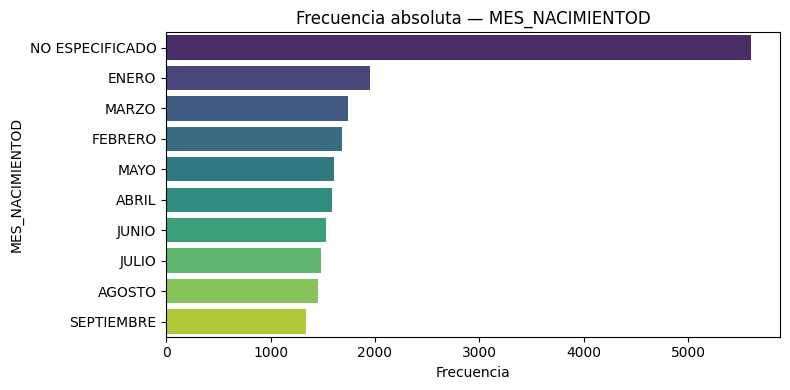

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freqs.values, y=freqs.index, palette="viridis")


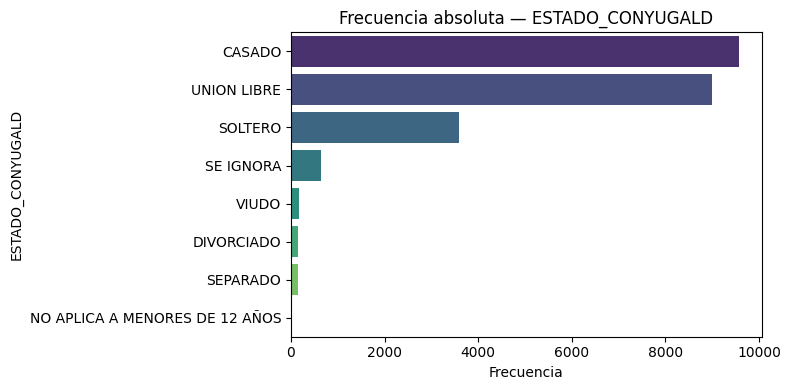

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freqs.values, y=freqs.index, palette="viridis")


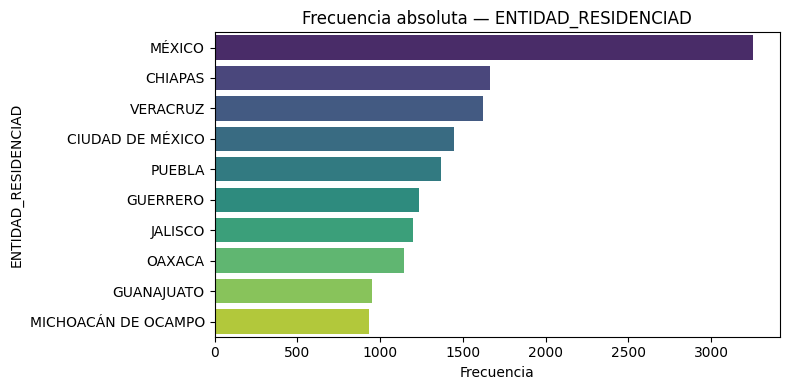

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freqs.values, y=freqs.index, palette="viridis")


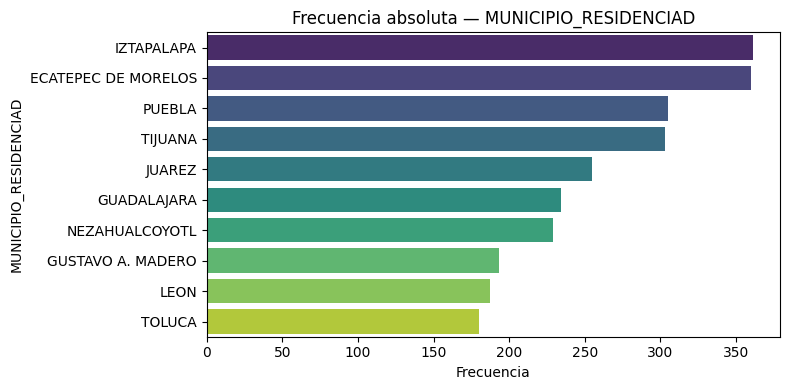

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freqs.values, y=freqs.index, palette="viridis")


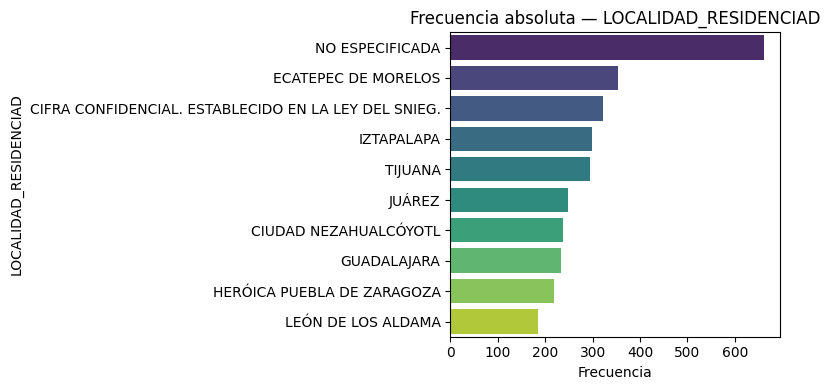

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freqs.values, y=freqs.index, palette="viridis")


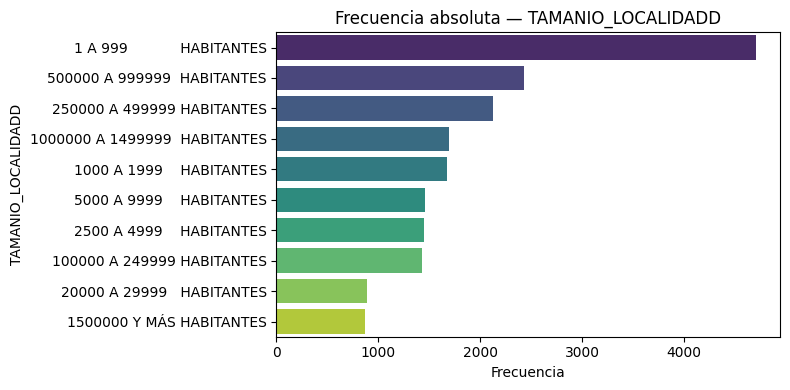

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freqs.values, y=freqs.index, palette="viridis")


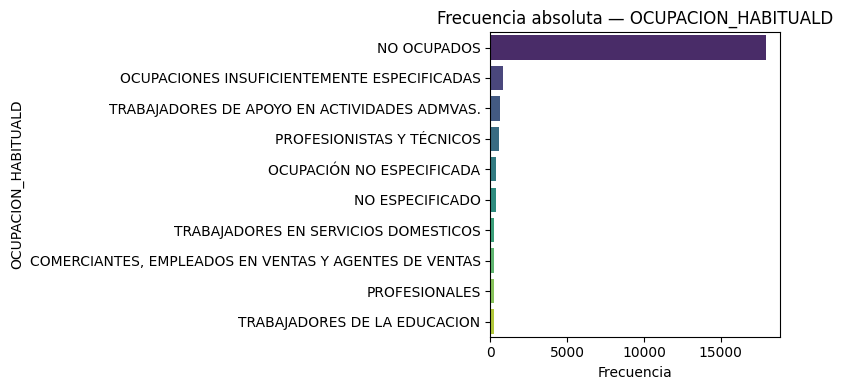

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freqs.values, y=freqs.index, palette="viridis")


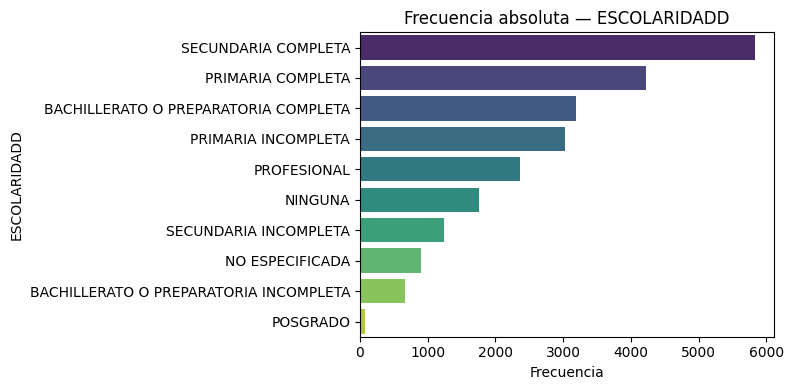

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freqs.values, y=freqs.index, palette="viridis")


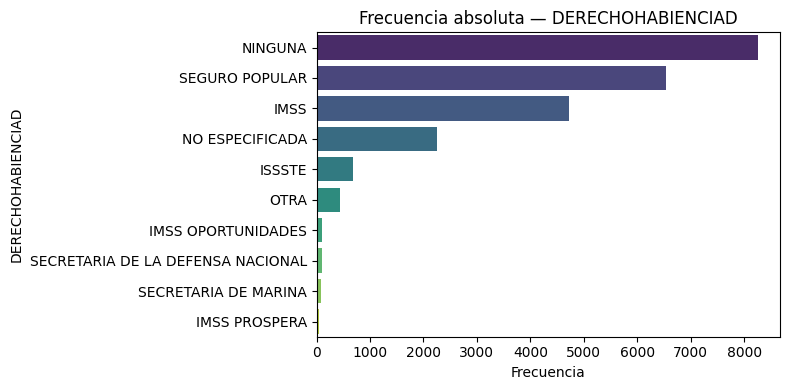

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freqs.values, y=freqs.index, palette="viridis")


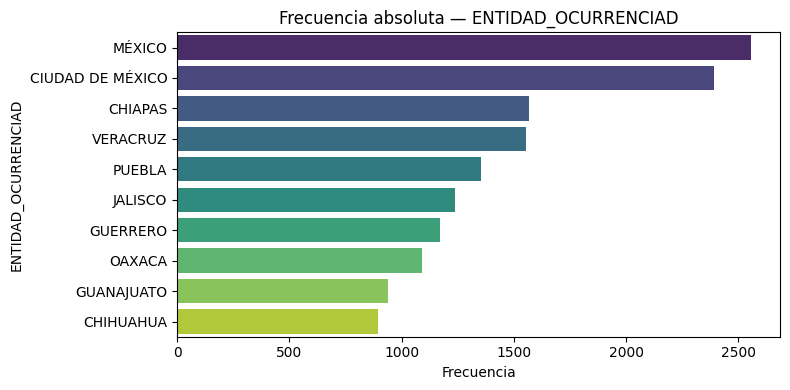

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freqs.values, y=freqs.index, palette="viridis")


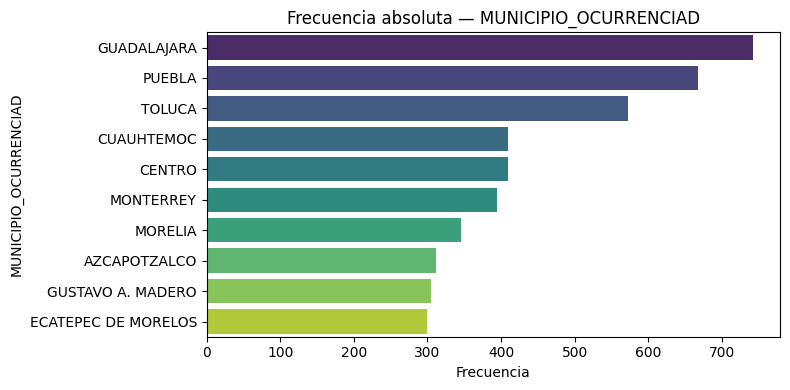

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freqs.values, y=freqs.index, palette="viridis")


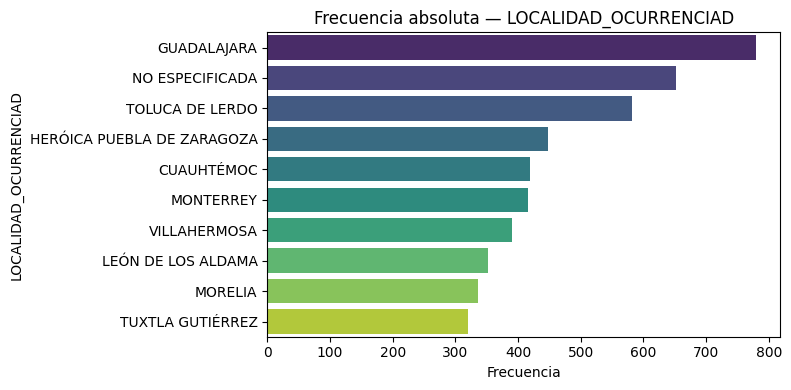

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freqs.values, y=freqs.index, palette="viridis")


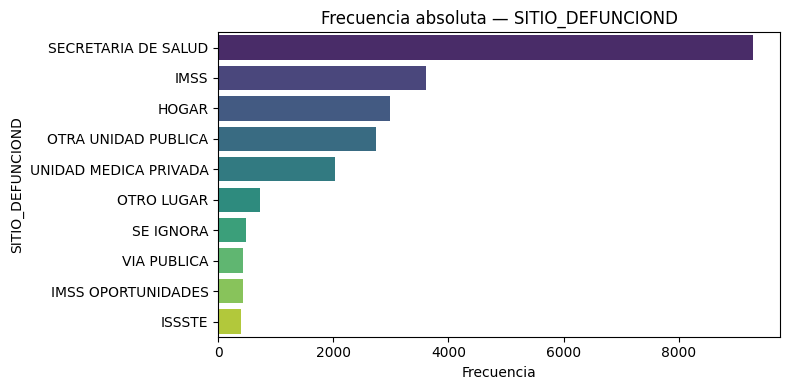

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freqs.values, y=freqs.index, palette="viridis")


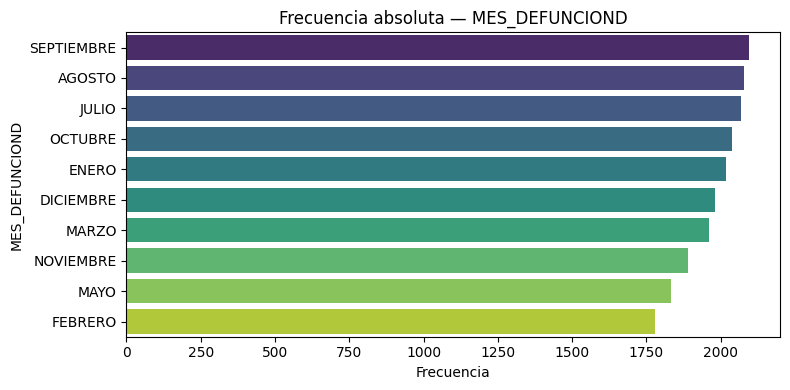

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freqs.values, y=freqs.index, palette="viridis")


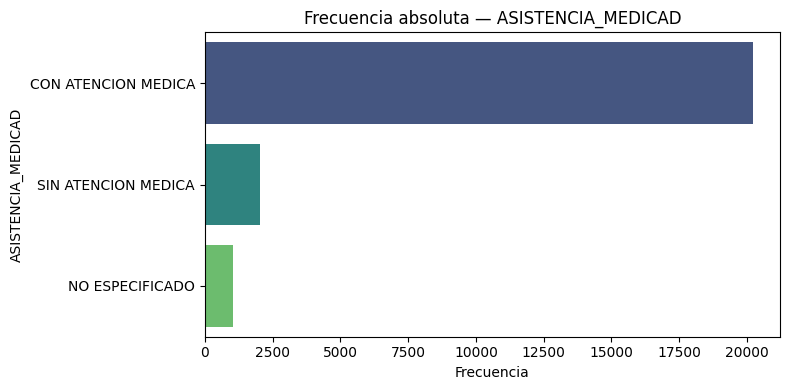

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freqs.values, y=freqs.index, palette="viridis")
C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:40: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


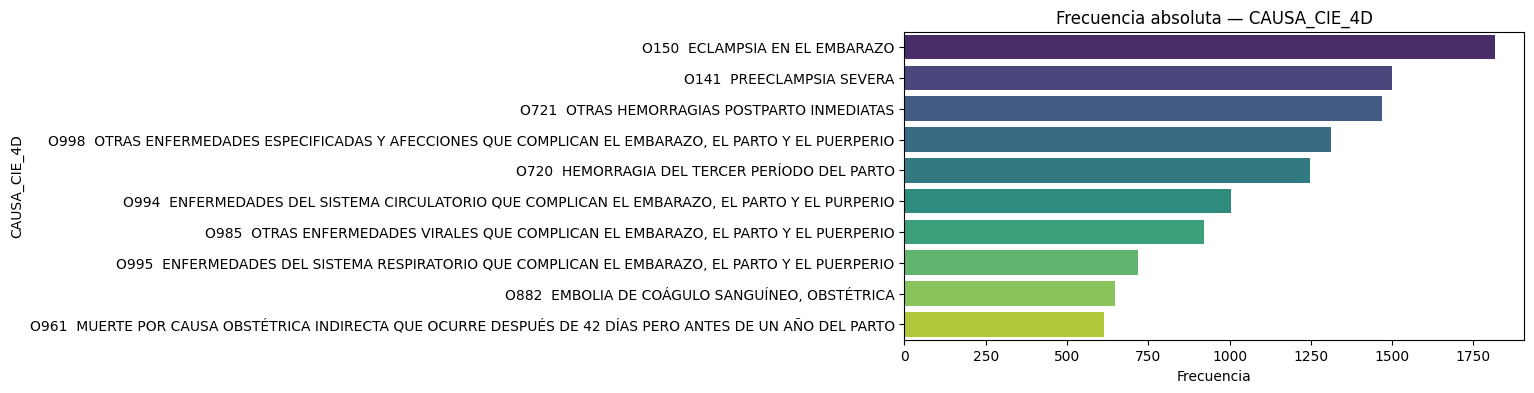

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freqs.values, y=freqs.index, palette="viridis")


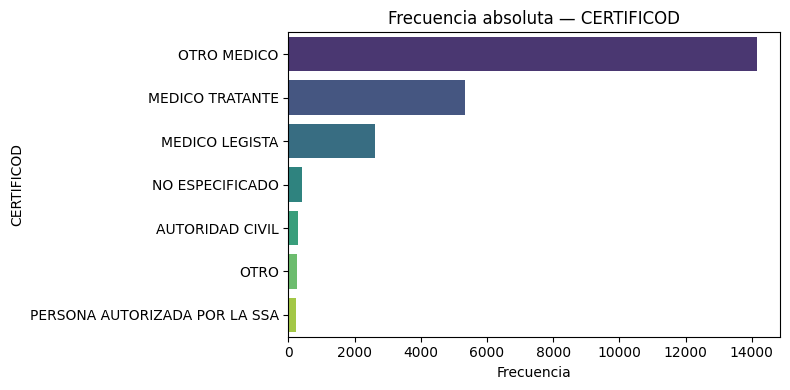

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freqs.values, y=freqs.index, palette="viridis")


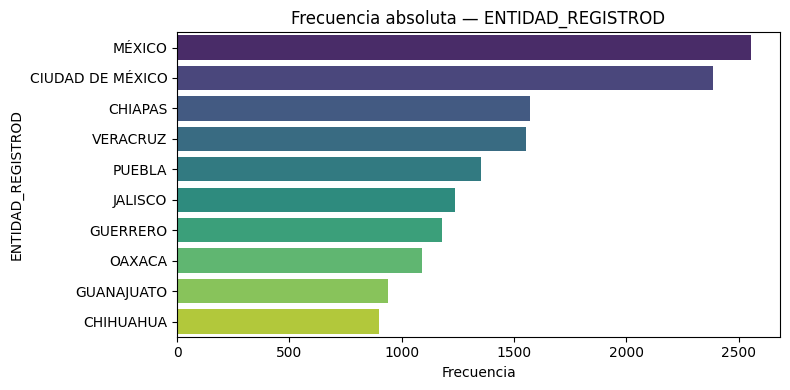

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freqs.values, y=freqs.index, palette="viridis")


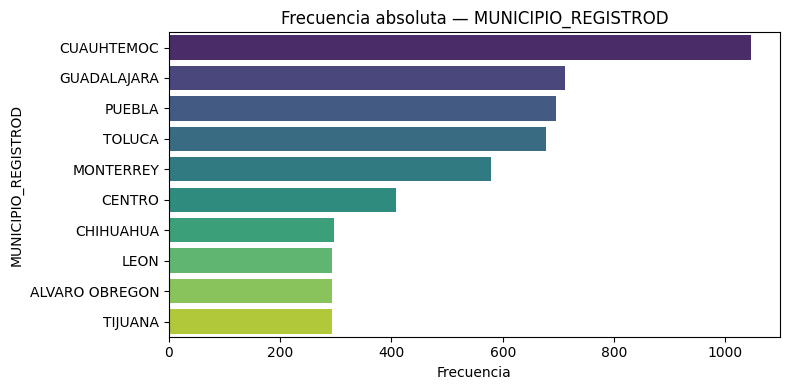

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freqs.values, y=freqs.index, palette="viridis")


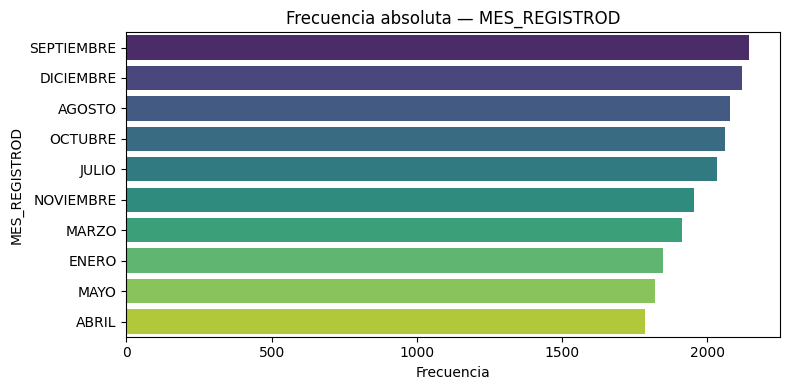

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freqs.values, y=freqs.index, palette="viridis")


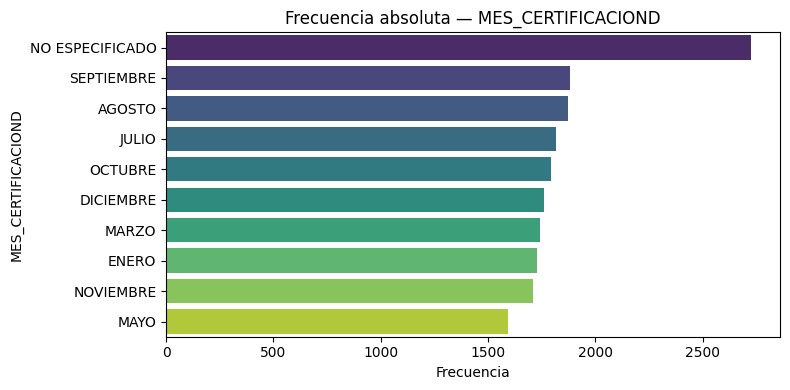

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freqs.values, y=freqs.index, palette="viridis")


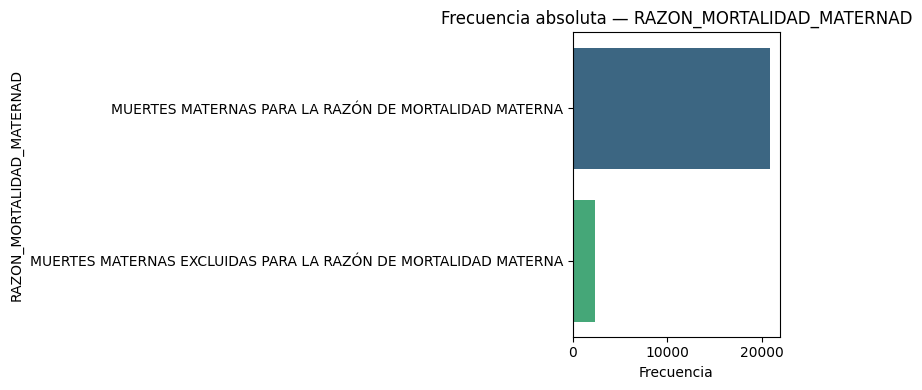

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freqs.values, y=freqs.index, palette="viridis")


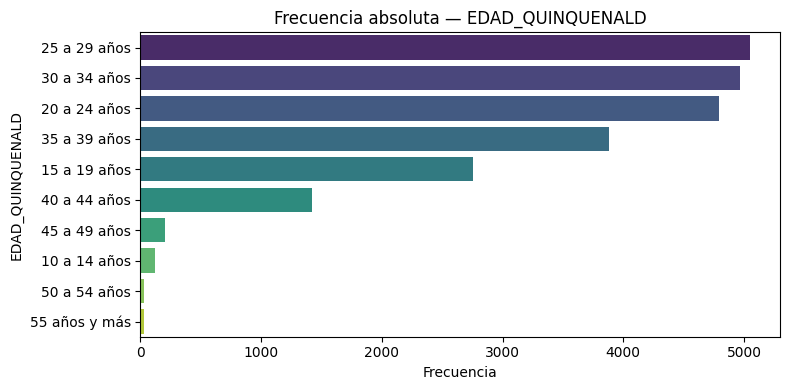


=== Gráficos de frecuencia relativa (%) por variable ===


C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rel_freqs.values, y=rel_freqs.index, palette="crest")


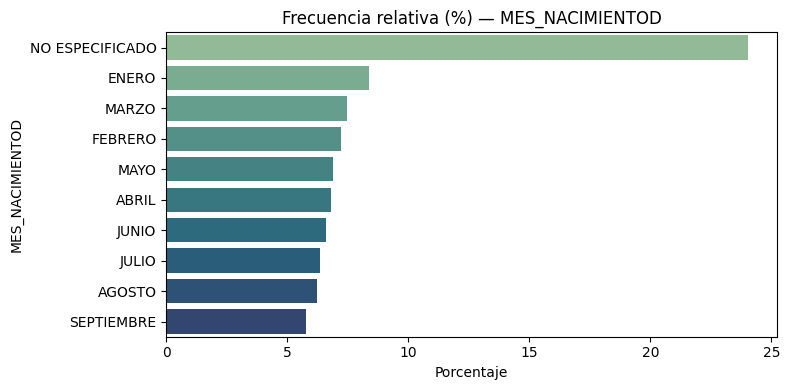

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rel_freqs.values, y=rel_freqs.index, palette="crest")


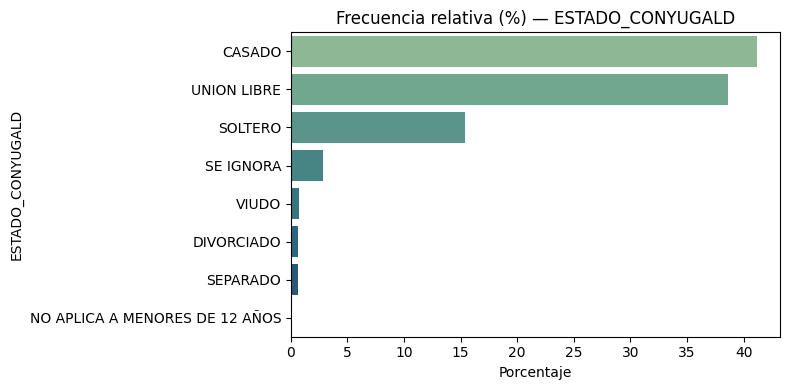

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rel_freqs.values, y=rel_freqs.index, palette="crest")


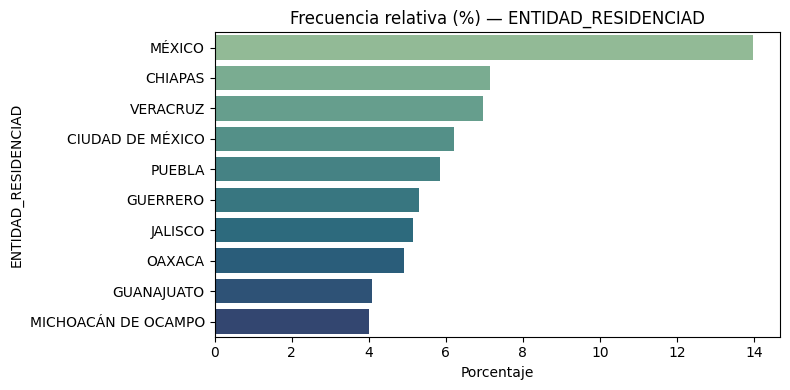

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rel_freqs.values, y=rel_freqs.index, palette="crest")


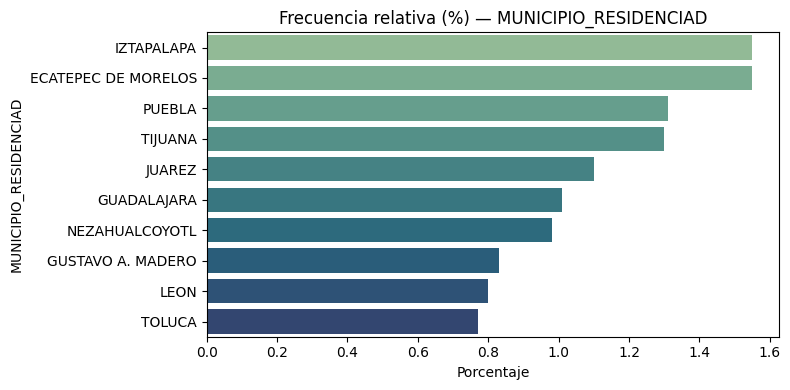

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rel_freqs.values, y=rel_freqs.index, palette="crest")


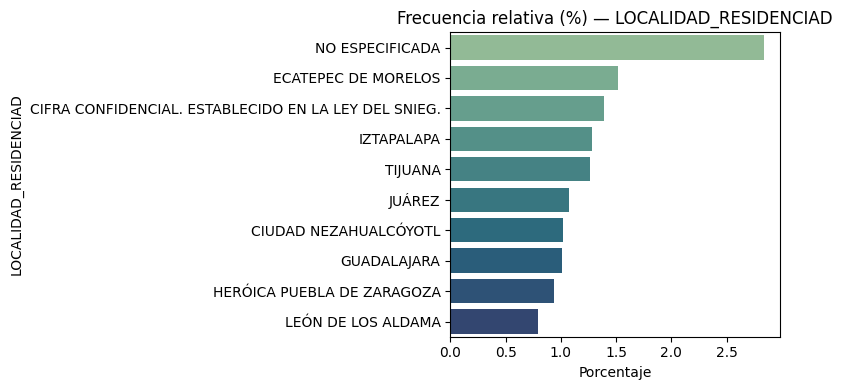

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rel_freqs.values, y=rel_freqs.index, palette="crest")


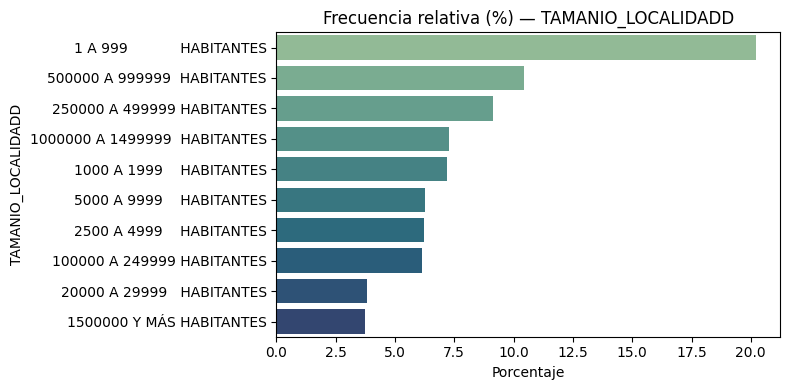

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rel_freqs.values, y=rel_freqs.index, palette="crest")


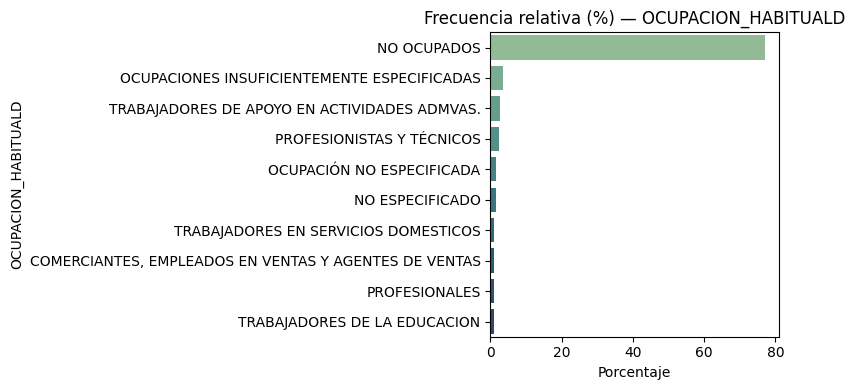

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rel_freqs.values, y=rel_freqs.index, palette="crest")


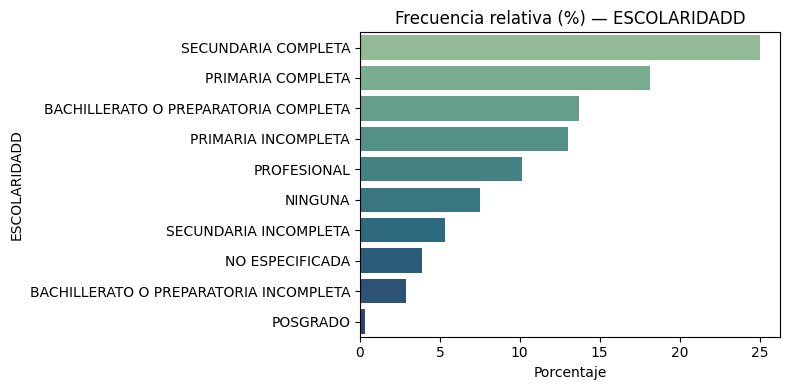

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rel_freqs.values, y=rel_freqs.index, palette="crest")


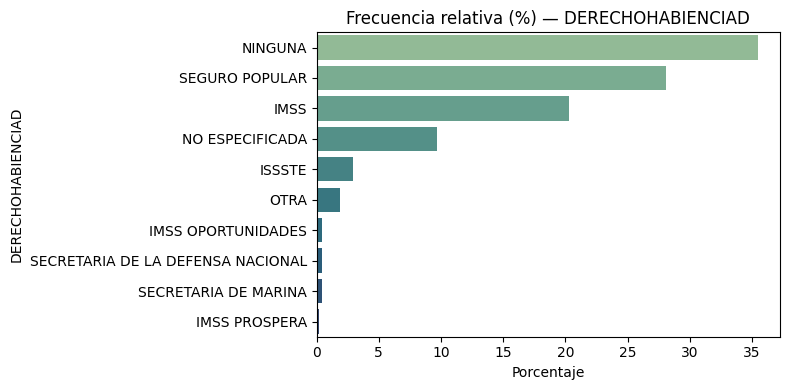

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rel_freqs.values, y=rel_freqs.index, palette="crest")


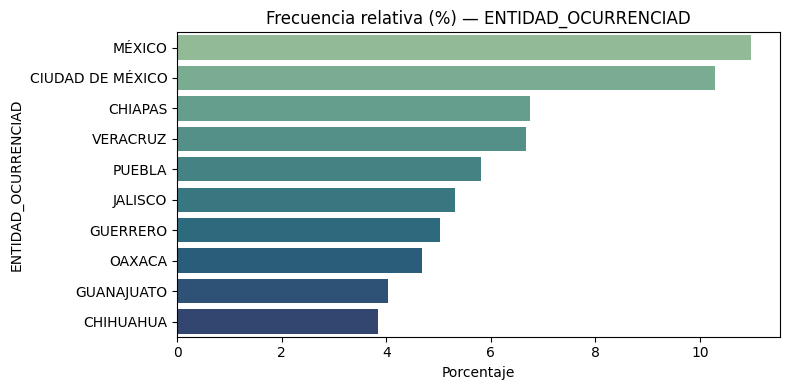

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rel_freqs.values, y=rel_freqs.index, palette="crest")


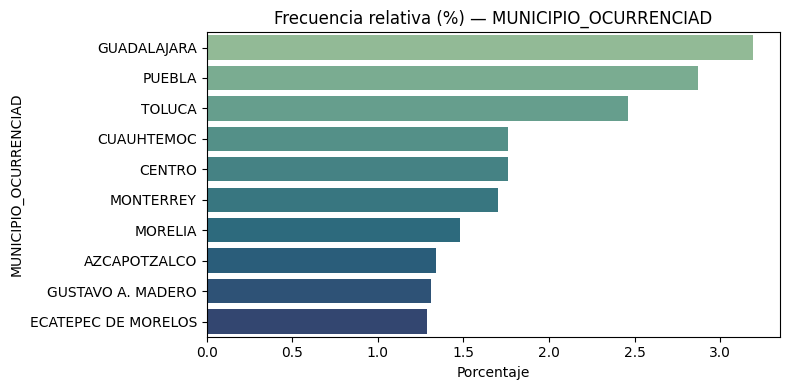

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rel_freqs.values, y=rel_freqs.index, palette="crest")


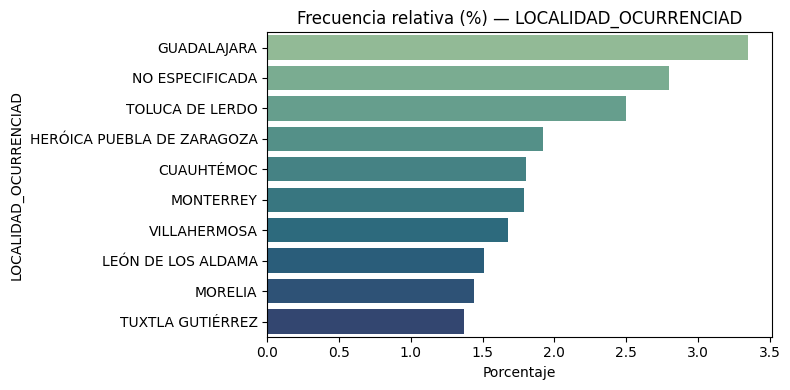

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rel_freqs.values, y=rel_freqs.index, palette="crest")


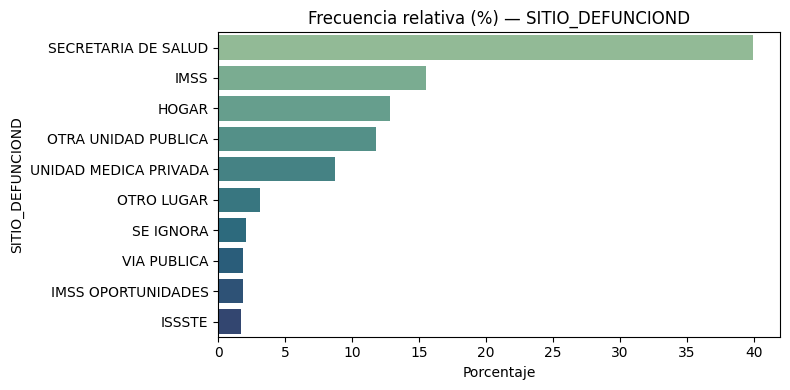

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rel_freqs.values, y=rel_freqs.index, palette="crest")


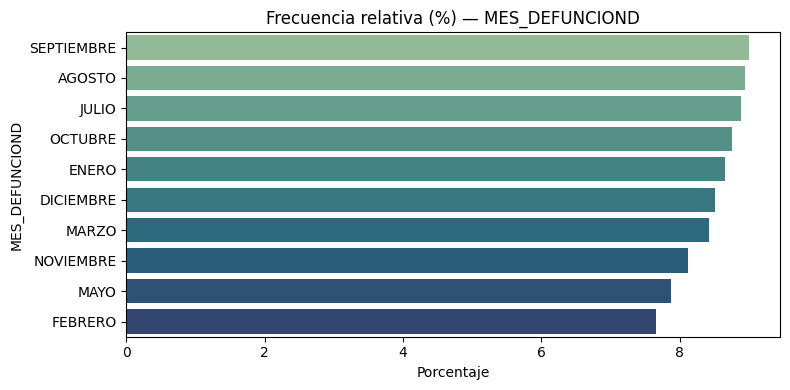

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rel_freqs.values, y=rel_freqs.index, palette="crest")


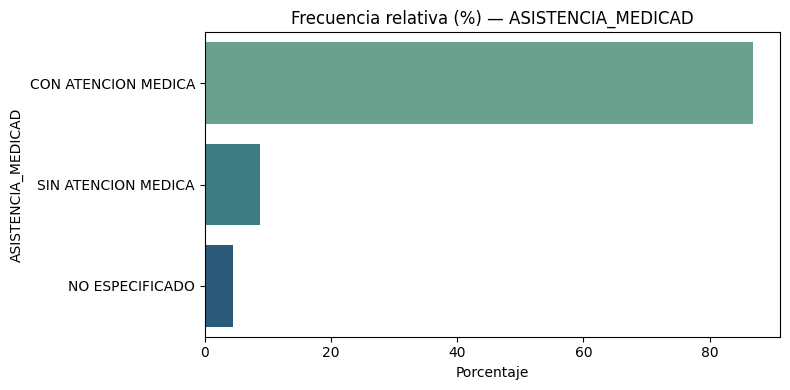

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rel_freqs.values, y=rel_freqs.index, palette="crest")
C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:52: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


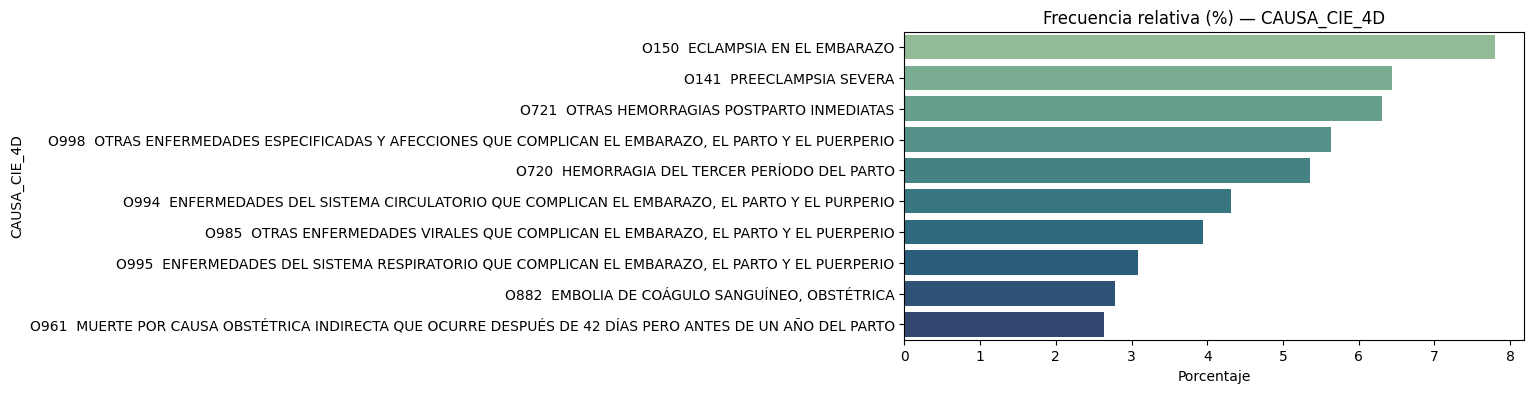

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rel_freqs.values, y=rel_freqs.index, palette="crest")


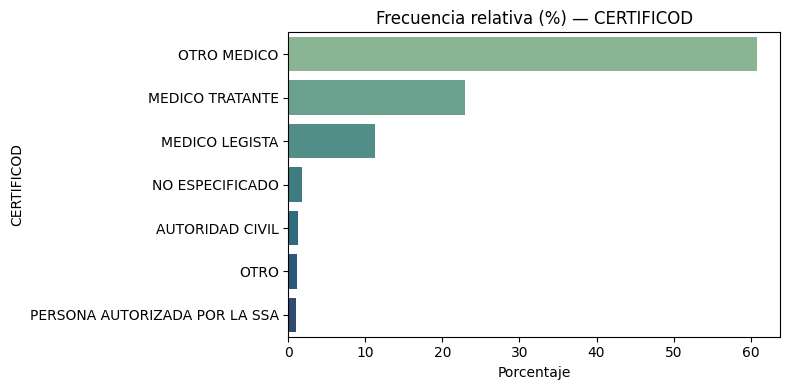

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rel_freqs.values, y=rel_freqs.index, palette="crest")


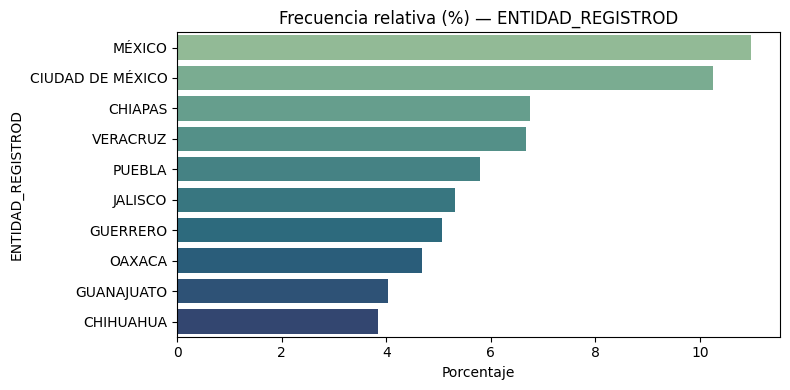

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rel_freqs.values, y=rel_freqs.index, palette="crest")


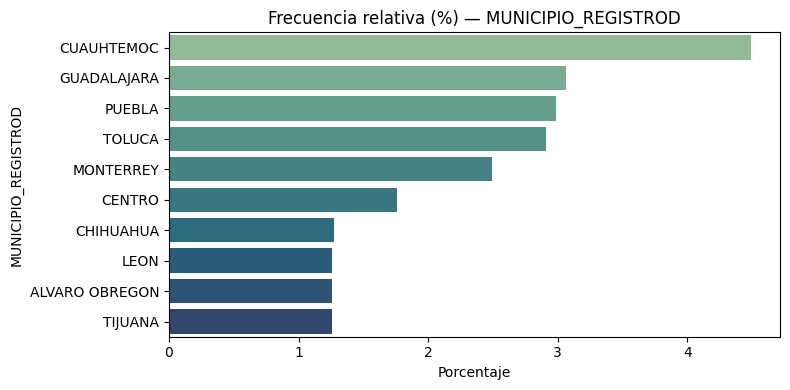

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rel_freqs.values, y=rel_freqs.index, palette="crest")


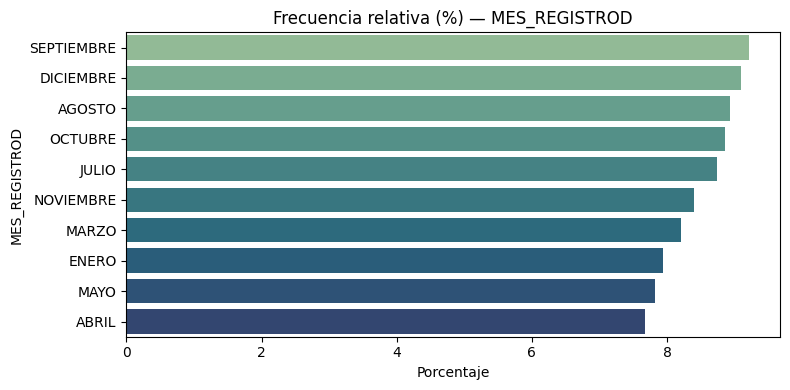

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rel_freqs.values, y=rel_freqs.index, palette="crest")


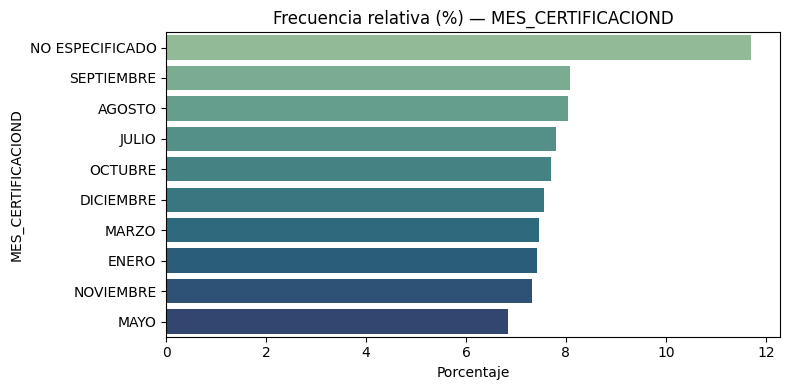

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rel_freqs.values, y=rel_freqs.index, palette="crest")


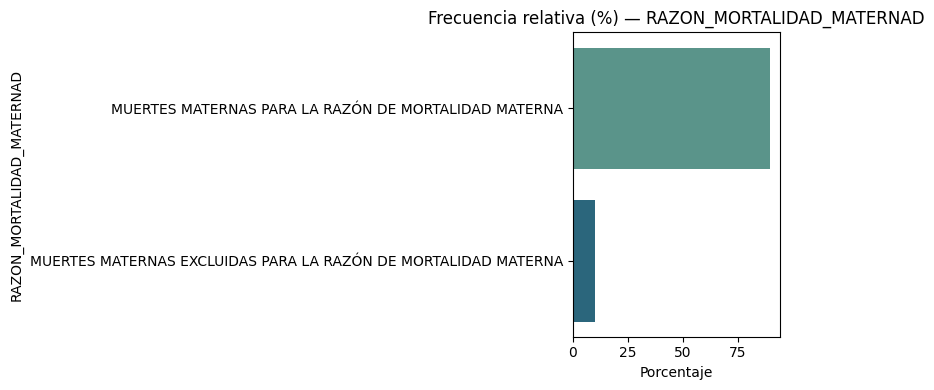

C:\Users\dayri\AppData\Local\Temp\ipykernel_14520\385067149.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rel_freqs.values, y=rel_freqs.index, palette="crest")


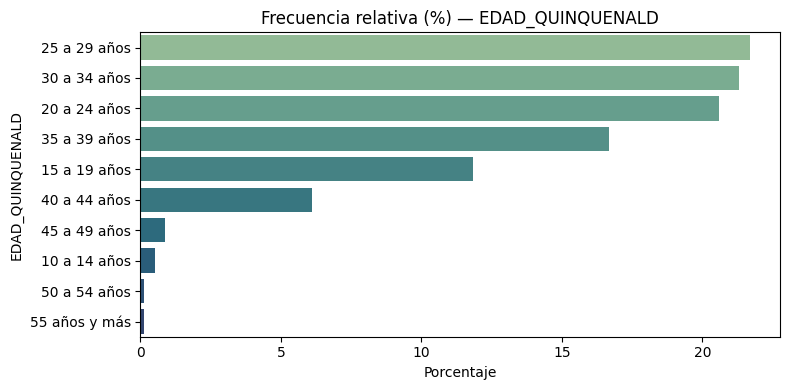


=== Entropía de Shannon (bits) ===


LOCALIDAD_RESIDENCIAD       10.66
MUNICIPIO_RESIDENCIAD        9.62
MUNICIPIO_REGISTROD          8.47
LOCALIDAD_OCURRENCIAD        8.42
MUNICIPIO_OCURRENCIAD        8.40
CAUSA_CIE_4D                 5.84
ENTIDAD_OCURRENCIAD          4.56
ENTIDAD_REGISTROD            4.56
ENTIDAD_RESIDENCIAD          4.56
TAMANIO_LOCALIDADD           3.82
MES_CERTIFICACIOND           3.68
MES_DEFUNCIOND               3.58
MES_REGISTROD                3.58
MES_NACIMIENTOD              3.50
ESCOLARIDADD                 2.93
SITIO_DEFUNCIOND             2.64
EDAD_QUINQUENALD             2.60
DERECHOHABIENCIAD            2.23
ESTADO_CONYUGALD             1.76
OCUPACION_HABITUALD          1.74
CERTIFICOD                   1.59
ASISTENCIA_MEDICAD           0.68
RAZON_MORTALIDAD_MATERNAD    0.48
dtype: float64


=== Tablas de contingencia seleccionadas ===

-- Contingencia ESCOLARIDADD x ASISTENCIA_MEDICAD (porcentaje por fila)


ASISTENCIA_MEDICAD,CON ATENCION MEDICA,NO ESPECIFICADO,SIN ATENCION MEDICA
ESCOLARIDADD,,,
BACHILLERATO O PREPARATORIA COMPLETA,93.38,2.85,3.76
BACHILLERATO O PREPARATORIA INCOMPLETA,92.03,4.81,3.16
NINGUNA,68.72,6.05,25.23
NO ESPECIFICADA,67.18,23.90,8.92
POSGRADO,91.14,2.53,6.33
PREESCOLAR,70.00,0.00,30.00
PRIMARIA COMPLETA,85.66,3.74,10.59
PRIMARIA INCOMPLETA,82.18,3.47,14.35
PROFESIONAL,93.53,3.51,2.96



-- Contingencia ESTADO_CONYUGALD x ASISTENCIA_MEDICAD (porcentaje por fila)


...

ENTIDAD_OCURRENCIAD,AGUASCALIENTES,BAJA CALIFORNIA,BAJA CALIFORNIA SUR,CAMPECHE,CHIAPAS,CHIHUAHUA,CIUDAD DE MÉXICO,COAHUILA,COLIMA,DURANGO,ESTADOS UNIDOS DE NORTEAMÉRICA,GUANAJUATO,GUERRERO,HIDALGO,JALISCO,MICHOACÁN,MORELOS,MÉXICO,NAYARIT,NUEVO LEÓN,OAXACA,PUEBLA,QUERÉTARO,QUINTANA ROO,SAN LUIS POTOSÍ,SINALOA,SONORA,TABASCO,TAMAULIPAS,TLAXCALA,VERACRUZ,YUCATÁN,ZACATECAS
SITIO_DEFUNCIOND,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
HOGAR,0.91,0.91,0.23,0.27,12.58,4.83,3.42,1.04,0.13,0.94,0.00,2.95,10.67,1.98,2.95,3.72,1.07,11.78,1.64,1.41,9.63,6.85,1.38,1.07,2.15,1.07,0.97,1.95,0.94,0.77,7.72,1.01,1.04
IMSS,1.50,4.32,0.80,0.47,2.60,4.43,13.49,4.87,0.36,1.08,0.00,4.13,1.14,1.00,9.17,2.52,0.83,8.64,0.78,7.26,1.97,3.74,1.99,1.36,1.86,3.16,3.88,0.86,3.35,0.64,4.90,2.13,0.80
IMSS OPORTUNIDADES,0.46,1.15,0.00,0.23,20.18,7.34,1.38,2.75,0.00,2.06,0.00,0.69,0.46,4.36,2.29,3.44,0.00,3.21,0.46,1.38,17.20,7.57,0.69,0.69,3.90,0.92,0.69,1.15,2.06,0.23,9.40,1.83,1.83
ISSSTE,1.75,2.01,1.00,0.50,3.26,2.76,29.07,0.50,0.00,3.51,0.00,2.26,5.76,2.76,3.01,4.26,1.50,5.01,2.51,1.25,5.76,3.51,1.75,0.25,1.50,3.51,1.25,1.50,2.01,0.50,4.01,0.50,1.25
OTRA UNIDAD PUBLICA,0.58,1.90,0.58,0.73,3.46,4.48,15.63,2.55,0.29,0.87,0.07,3.02,4.63,1.49,8.71,1.79,1.38,12.61,0.47,6.78,2.66,5.10,1.09,0.58,2.00,1.68,1.75,1.90,2.48,0.87,4.96,1.79,1.09
OTRO LUGAR,0.56,1.81,0.14,1.25,8.47,6.53,4.44,1.11,0.00,2.36,0.14,1.81,10.00,1.67,5.14,3.89,0.83,10.69,2.92,1.81,7.08,5.42,0.69,1.11,3.61,1.39,1.39,1.39,1.94,0.42,7.36,0.83,1.81
PEMEX,0.00,0.00,0.00,0.00,0.00,3.33,30.00,3.33,0.00,0.00,0.00,3.33,0.00,0.00,0.00,3.33,0.00,0.00,0.00,0.00,6.67,3.33,0.00,0.00,0.00,0.00,0.00,10.00,13.33,0.00,23.33,0.00,0.00
SE IGNORA,0.21,1.03,0.00,1.03,14.99,7.80,0.82,1.85,0.00,5.95,0.00,2.05,5.95,4.72,2.67,3.70,1.23,4.72,2.67,1.44,6.16,8.83,0.41,2.67,1.44,2.05,0.21,2.67,1.64,0.00,8.62,0.62,1.85
SECRETARIA DE LA DEFENSA NACIONAL,0.00,1.39,0.00,0.00,6.94,1.39,68.06,1.39,0.00,0.00,0.00,2.78,2.78,0.00,0.00,0.00,1.39,2.78,0.00,0.00,0.00,1.39,0.00,0.00,0.00,1.39,0.00,2.78,2.78,0.00,1.39,1.39,0.00



=== Variables categóricas de baja cardinalidad (<=10) ===


['ESTADO_CONYUGALD',
 'ASISTENCIA_MEDICAD',
 'CERTIFICOD',
 'RAZON_MORTALIDAD_MATERNAD']


-- Matriz de co-ocurrencia (conteo) entre variables de baja cardinalidad


,ESTADO_CONYUGALD,ASISTENCIA_MEDICAD,CERTIFICOD,RAZON_MORTALIDAD_MATERNAD
ESTADO_CONYUGALD,"23,278.00","23,278.00","23,278.00","23,278.00"
ASISTENCIA_MEDICAD,"23,278.00","23,278.00","23,278.00","23,278.00"
CERTIFICOD,"23,278.00","23,278.00","23,278.00","23,278.00"
RAZON_MORTALIDAD_MATERNAD,"23,278.00","23,278.00","23,278.00","23,278.00"


In [6]:
# Seleccionar variables categóricas que terminan en 'D', excluyendo algunas específicas
categorical_vars = [col for col in df.columns if col.endswith("D") and col not in ["EDAD", "TAMANIO_LOCALIDAD", "ESCOLARIDAD"]]

# Opciones de muestra
TOP_N = 10   # número de categorías a mostrar por variable

pd.set_option("display.max_colwidth", 120)

# 1) Cardinalidad y faltantes
cardinality = pd.DataFrame({
    "cardinalidad": {v: df[v].nunique(dropna=False) for v in categorical_vars},
    "valores_nulos": {v: df[v].isna().sum() for v in categorical_vars},
    "pct_nulos": {v: (df[v].isna().mean()*100).round(2) for v in categorical_vars}
})
print("=== Cardinalidad y faltantes ===")
display(cardinality.sort_values("cardinalidad", ascending=False))

# 2) Función frecuencia + top N 
def freq_table(series, top_n=TOP_N):
    freqs = series.value_counts(dropna=False)
    rel = (series.value_counts(normalize=True, dropna=False) * 100).round(2)
    table = pd.DataFrame({"Frecuencia absoluta": freqs, "Frecuencia relativa (%)": rel})
    return table.head(top_n)

print("\n=== Top categorías por variable (top {}) ===".format(TOP_N))
for var in categorical_vars:
    print("\n--", var)
    display(freq_table(df[var], top_n=TOP_N))

# Graficar frecuencias absolutas para cada variable categórica
print("\n=== Gráficos de frecuencia absoluta por variable ===")
for var in categorical_vars:
    freqs = df[var].value_counts(dropna=False).head(TOP_N)
    
    plt.figure(figsize=(8, 4))
    sns.barplot(x=freqs.values, y=freqs.index, palette="viridis")
    plt.title(f"Frecuencia absoluta — {var}")
    plt.xlabel("Frecuencia")
    plt.ylabel(var)
    plt.tight_layout()
    plt.show()
    
print("\n=== Gráficos de frecuencia relativa (%) por variable ===")
for var in categorical_vars:
    rel_freqs = (df[var].value_counts(normalize=True, dropna=False).head(TOP_N) * 100).round(2)
    
    plt.figure(figsize=(8, 4))
    sns.barplot(x=rel_freqs.values, y=rel_freqs.index, palette="crest")
    plt.title(f"Frecuencia relativa (%) — {var}")
    plt.xlabel("Porcentaje")
    plt.ylabel(var)
    plt.tight_layout()
    plt.show()

# 3) Entropía de Shannon por variable (medida de heterogeneidad)
def shannon_entropy(series):
    freqs = series.value_counts(normalize=True, dropna=False)
    return entropy(freqs, base=2)  # bits

entropies = pd.Series({v: shannon_entropy(df[v]) for v in categorical_vars}).sort_values(ascending=False)
print("\n=== Entropía de Shannon (bits) ===")
display(entropies)

# 4) Tablas de contingencia útiles (predefinidas)
print("\n=== Tablas de contingencia seleccionadas ===")
pairs = [
    ("ESCOLARIDADD", "ASISTENCIA_MEDICAD"),
    ("ESTADO_CONYUGALD", "ASISTENCIA_MEDICAD"),
    ("SITIO_DEFUNCIOND", "ENTIDAD_OCURRENCIAD")
]

for a,b in pairs:
    if a in df.columns and b in df.columns:
        print(f"\n-- Contingencia {a} x {b} (porcentaje por fila)")
        ct = pd.crosstab(df[a], df[b], normalize="index") * 100
        display(ct.round(2).head(10))  # mostrar filas top 10 para evitar saturar la celda
    else:
        print(f"\n-- Variables {a} o {b} no encontradas en el dataframe.")

# 5) Matriz de co-ocurrencia simple entre variables categóricas (solo para variables de baja cardinalidad)
low_card_vars = [v for v,c in cardinality["cardinalidad"].items() if c <= 10]
print("\n=== Variables categóricas de baja cardinalidad (<=10) ===")
display(low_card_vars)

if len(low_card_vars) >= 2:
    print("\n-- Matriz de co-ocurrencia (conteo) entre variables de baja cardinalidad")
    cooc = pd.DataFrame(index=low_card_vars, columns=low_card_vars, dtype=int)
    for v1 in low_card_vars:
        for v2 in low_card_vars:
            cooc.loc[v1, v2] = pd.crosstab(df[v1], df[v2]).values.sum()  # suma de la tabla
    display(cooc)
else:
    print("No hay suficientes variables de baja cardinalidad para la matriz de co-ocurrencia.")

**Visualizaciones para variables numéricas**

Este script genera: histogramas, boxplots (por variable), un pairwise scatter para pares seleccionados, y series temporales agregadas por año / mes. Ignora valores 0 ya convertidos a NaN.

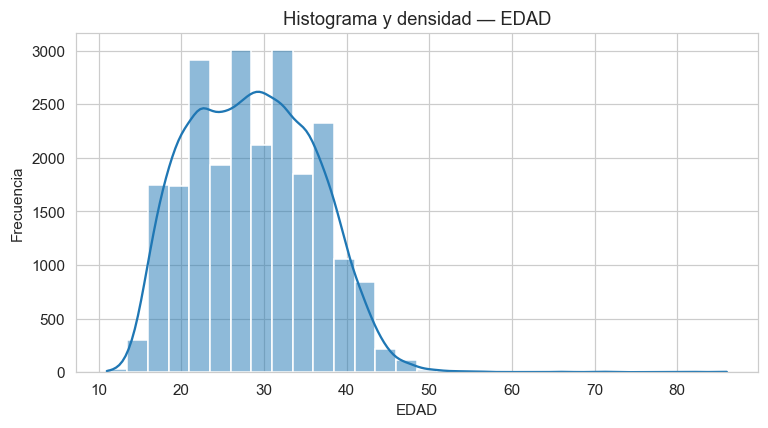

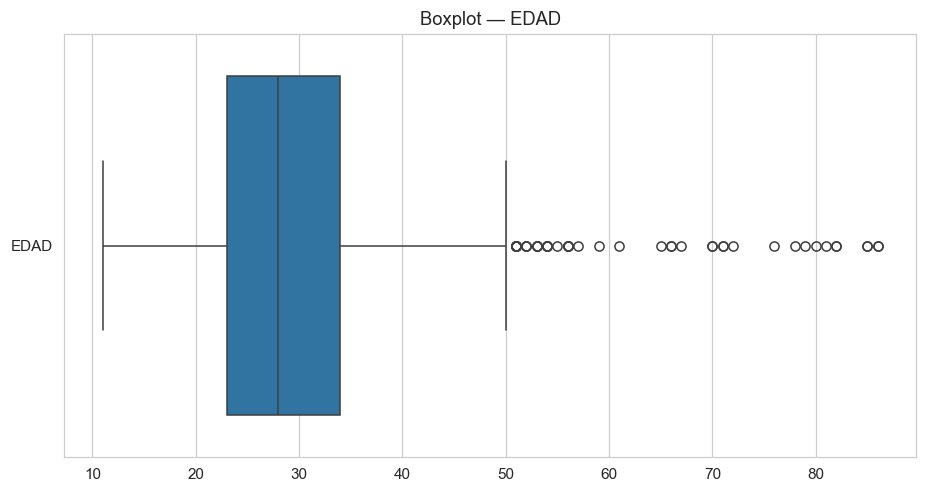

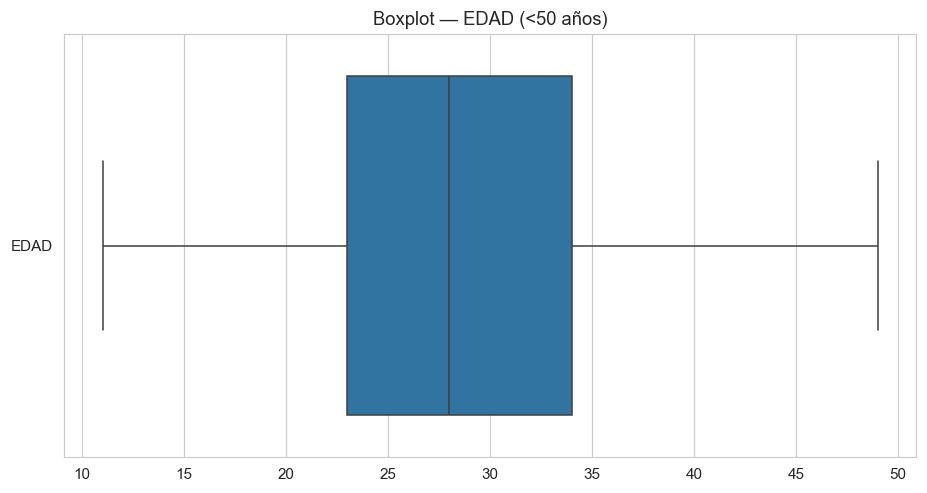

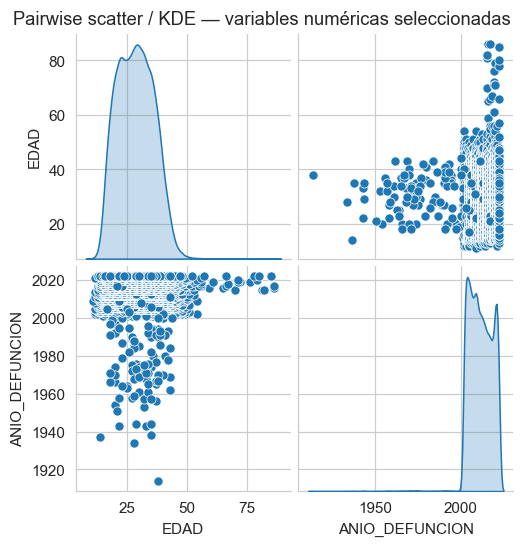

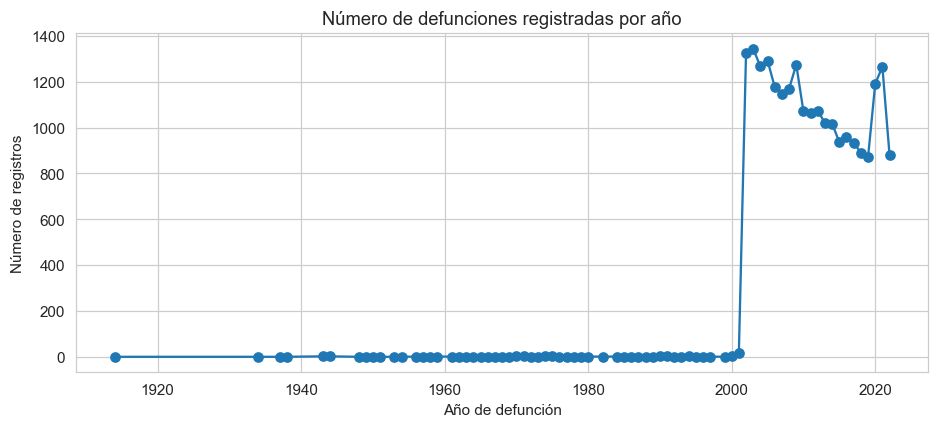

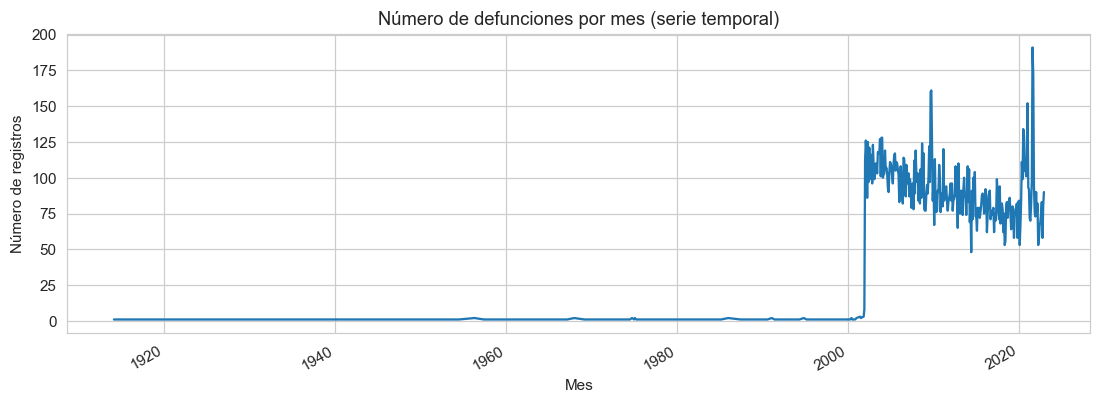

Observaciones con |Z|>3 en EDAD: 39


4       54.00
177     54.00
10199   54.00
13178   53.00
15527   81.00
15703   70.00
15951   82.00
16099   70.00
16131   82.00
16205   53.00
Name: EDAD, dtype: float64

In [7]:
# Script: Visualizaciones - Variables numéricas
# Configuración gráfica
%matplotlib inline
plt.rcParams['figure.dpi'] = 110
sns.set_style("whitegrid")

# Lista de variables numéricas (ajusta según lo que quieras visualizar)
num_vars = [
    "EDAD",
    "ANIO_NACIMIENTO", "ANIO_DEFUNCION", "ANIO_REGISTRO",
    "EDAD_QUINQUENAL"
]
# Asegurar que 0 ya fue reemplazado por NaN antes
df_num = df[num_vars].replace(0, np.nan).copy()

# ---- 1) Histogramas y densidad ----
for col in ["EDAD"]:
    plt.figure(figsize=(8,4))
    sns.histplot(df_num[col].dropna(), kde=True, bins=30)
    plt.title(f"Histograma y densidad — {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

# ---- 2) Boxplots (detección outliers) ----
plt.figure(figsize=(10,5))
sns.boxplot(data=df_num[["EDAD"]], orient="h")
plt.title("Boxplot — EDAD")
plt.show()

# ---- 2.1) Boxplots (detección outliers) eliminando edad para mayores de 50 años ----
df_menores_50 = df_num[df_num["EDAD"] < 50]
# Graficar boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_menores_50[["EDAD"]], orient="h")
plt.title("Boxplot — EDAD (<50 años)")
plt.show()


# ---- 3) Pairwise scatter (pares relevantes) ----
# Selecciona variables numéricas con sentido bivariado
pair_vars = ["EDAD", "ANIO_DEFUNCION"]
sns.pairplot(df[pair_vars].replace(0, np.nan).dropna(), diag_kind="kde", height=2.4)
plt.suptitle("Pairwise scatter / KDE — variables numéricas seleccionadas", y=1.02)
plt.show()

# ---- 4) Series temporales: conteo de defunciones por año y por mes-año ----
# Conteo anual de registros (ANIO_DEFUNCION)
df_time = df.copy()
df_time["ANIO_DEFUNCION"] = df_time["ANIO_DEFUNCION"].replace(0, np.nan)
annual_counts = df_time.groupby("ANIO_DEFUNCION").size().sort_index()

plt.figure(figsize=(10,4))
annual_counts.plot(marker="o")
plt.title("Número de defunciones registradas por año")
plt.xlabel("Año de defunción")
plt.ylabel("Número de registros")
plt.grid(True)
plt.show()

# Serie mensual
# Crear columna 'YYYY-MM' usando ANIO_DEFUNCION y MES_DEFUNCION
df_time["MES_DEFUNCION"] = df_time["MES_DEFUNCION"].replace(0, np.nan)
mask = df_time["ANIO_DEFUNCION"].notna() & df_time["MES_DEFUNCION"].notna()
df_time = df_time.loc[mask].copy()
df_time["YM"] = pd.to_datetime(df_time["ANIO_DEFUNCION"].astype(int).astype(str) + "-" + df_time["MES_DEFUNCION"].astype(int).astype(str) + "-01")
monthly = df_time.groupby("YM").size().sort_index()

plt.figure(figsize=(12,4))
monthly.plot()
plt.title("Número de defunciones por mes (serie temporal)")
plt.xlabel("Mes")
plt.ylabel("Número de registros")
plt.show()

# ---- 5) Outliers por Z-score (visual list) ----
from scipy import stats
z = df_num["EDAD"].dropna()
z_scores = (z - z.mean())/z.std()
outliers = z[z_scores.abs() > 3]
print(f"Observaciones con |Z|>3 en EDAD: {len(outliers)}")
display(outliers.head(10))


**Visualizaciones para variables categóricas**

Genera: barras (top k categorías), barras apiladas para comparar dos variables, heatmap a partir de tablas de contingencia, y (opcional) mapa por entidad si cuentas con un shapefile o geojson de entidades.

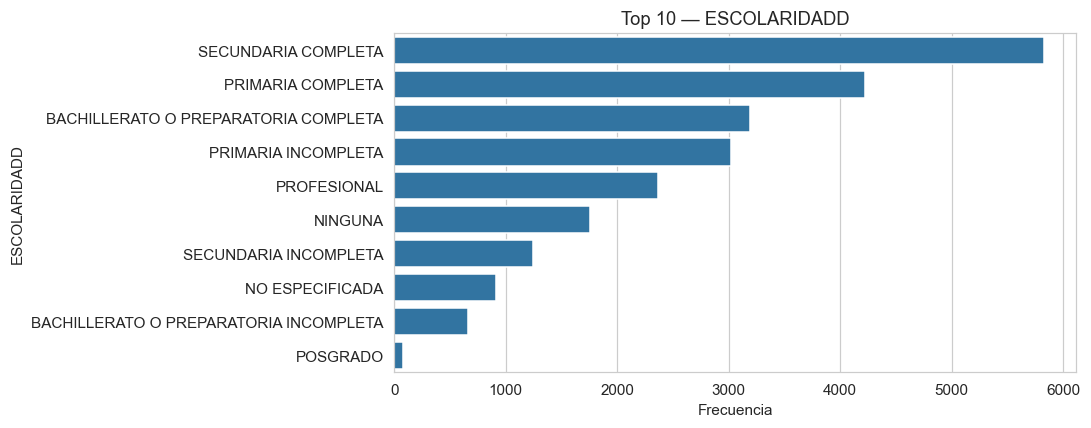

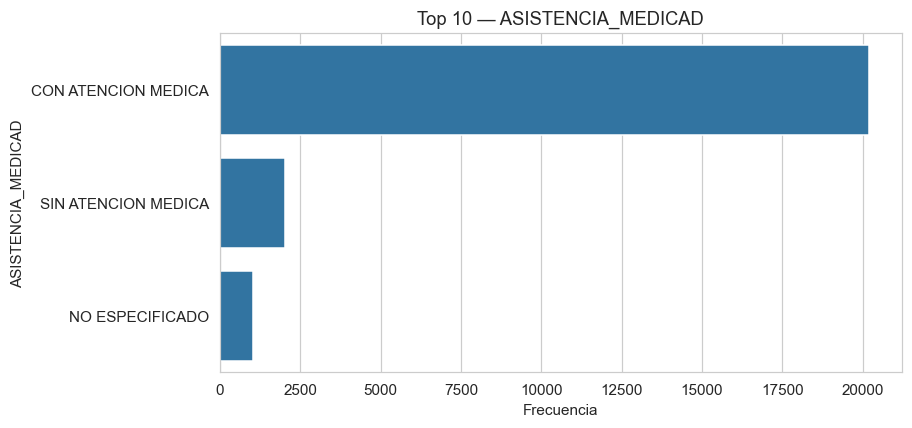

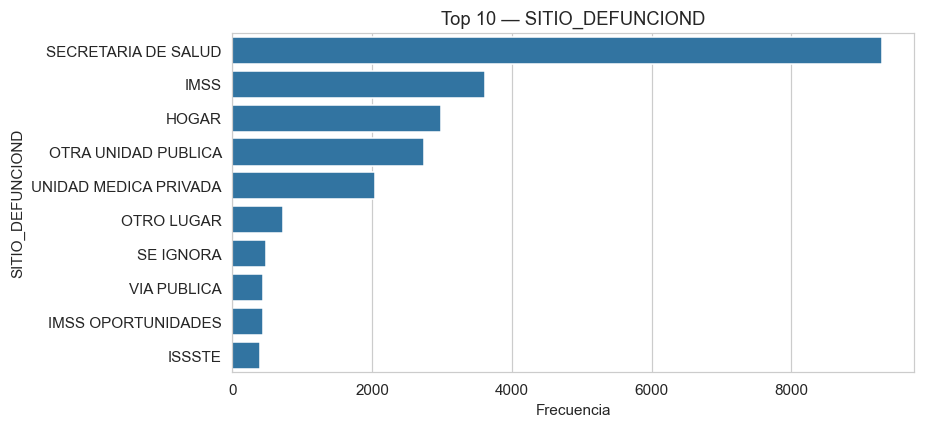

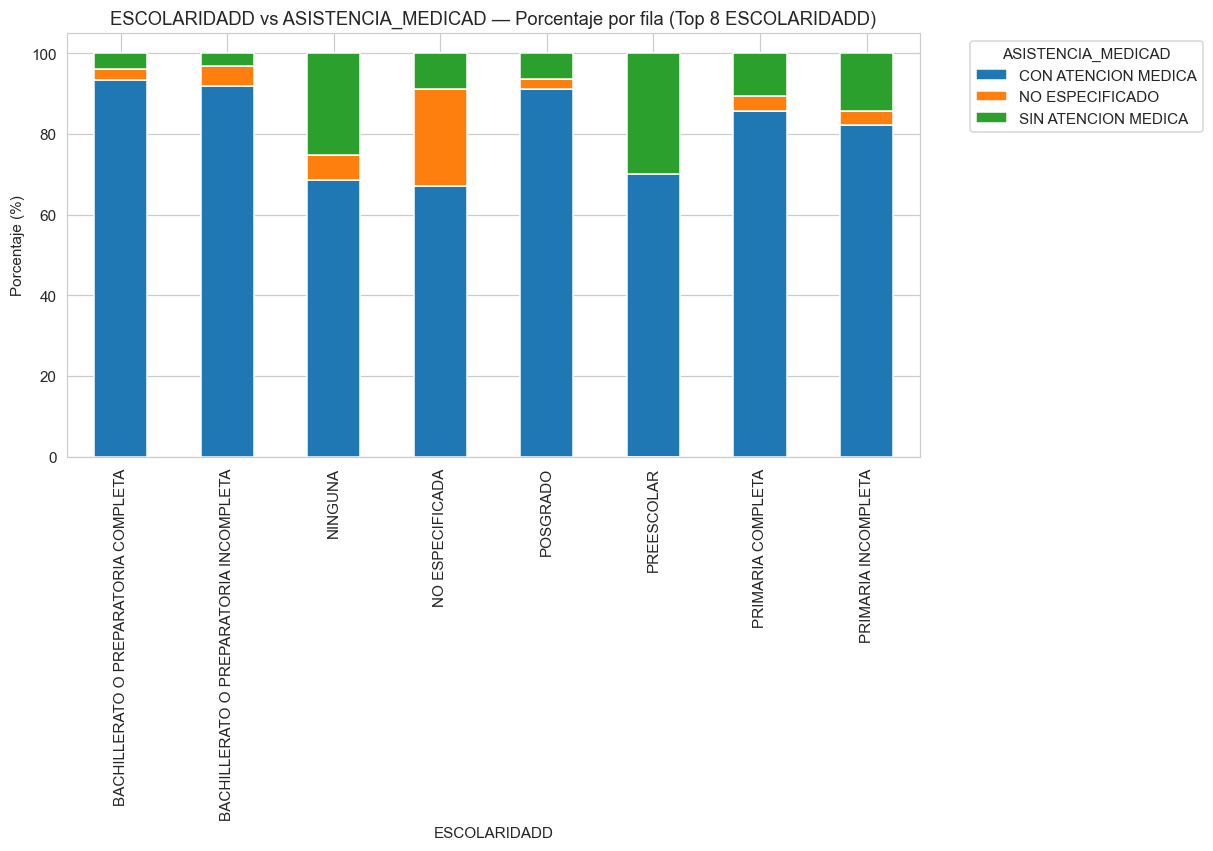

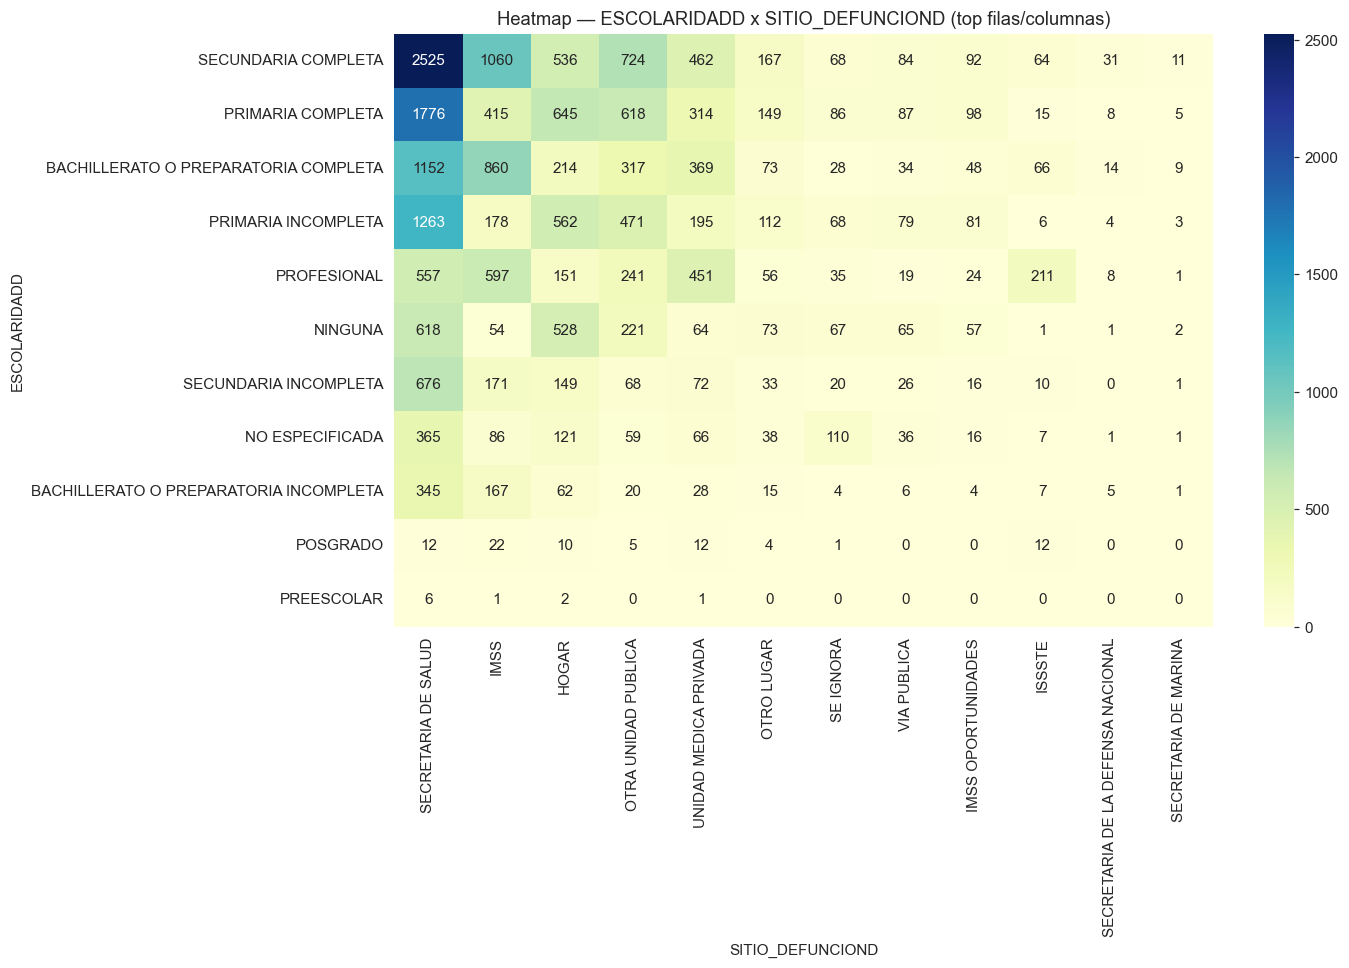

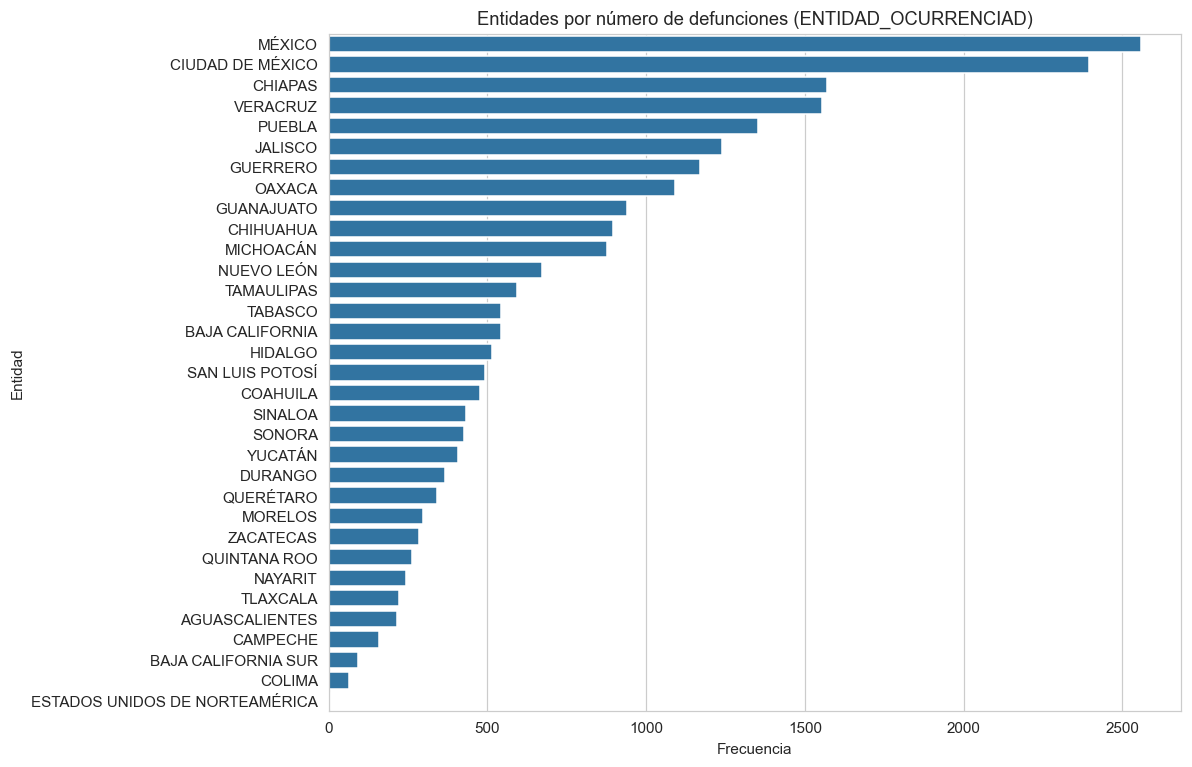

In [8]:
# Visualizaciones - Variables categóricas
%matplotlib inline
plt.rcParams['figure.dpi'] = 110
sns.set_style("whitegrid")

# Selección de variables categóricas (terminan en 'D')
categorical_vars = [c for c in df.columns if c.endswith("D")]

# Parámetros
TOP_N = 10   # top categorías a graficar

# ---- 1) Barras para top-N de cada variable categórica ----
for var in ["ESCOLARIDADD", "ASISTENCIA_MEDICAD", "SITIO_DEFUNCIOND"]:
    if var in df.columns:
        vc = df[var].value_counts(dropna=False).head(TOP_N)
        plt.figure(figsize=(8,4))
        sns.barplot(x=vc.values, y=vc.index)
        plt.title(f"Top {TOP_N} — {var}")
        plt.xlabel("Frecuencia")
        plt.ylabel(var)
        plt.show()

# ---- 2) Barras apiladas / agrupadas para dos variables ----
# Ejemplo: ESCOLARIDADD vs ASISTENCIA_MEDICAD (mostrar proporción por fila)
a = "ESCOLARIDADD"
b = "ASISTENCIA_MEDICAD"
if a in df.columns and b in df.columns:
    ct = pd.crosstab(df[a], df[b], normalize="index") * 100
    # Mostrar top filas (para no saturar)
    ct_plot = ct.head(8)
    ct_plot.plot(kind="bar", stacked=True, figsize=(10,5))
    plt.title(f"{a} vs {b} — Porcentaje por fila (Top 8 {a})")
    plt.ylabel("Porcentaje (%)")
    plt.legend(title=b, bbox_to_anchor=(1.05,1), loc='upper left')
    plt.show()

# ---- 3) Heatmap (matriz de relación) entre dos variables categóricas ----
x = "ESCOLARIDADD"
y = "SITIO_DEFUNCIOND"
if x in df.columns and y in df.columns:
    ct2 = pd.crosstab(df[x], df[y])
    # Para visualización, tomar top N filas/columnas por frecuencia
    top_rows = ct2.sum(axis=1).sort_values(ascending=False).head(12).index
    top_cols = ct2.sum(axis=0).sort_values(ascending=False).head(12).index
    ct2_sub = ct2.loc[top_rows, top_cols]
    plt.figure(figsize=(12,7))
    sns.heatmap(ct2_sub, annot=True, fmt='d', cmap="YlGnBu")
    plt.title(f"Heatmap — {x} x {y} (top filas/columnas)")
    plt.xlabel(y)
    plt.ylabel(x)
    plt.show()

# ---- 4) Mapas por entidad (opcional) ----
# SI cuentas con shapefile/geojson de las entidades federativas, usa geopandas:
# from geopandas import read_file
# gdf = read_file("mexico_states.geojson")
# gdf = gdf[['state_code','geometry']]  # adaptar columnas
# Aggregate counts by entidad (usar columna ENTIDAD_OCURRENCIAD o ENTIDAD_RESIDENCIAD)
# ct_ent = df['ENTIDAD_OCURRENCIAD'].value_counts().rename_axis('ENTIDAD').reset_index(name='counts')
# Merge con gdf y plot: gdf_merged.plot(column='counts', cmap='OrRd', legend=True)

# Gráfica de bar chart por entidad:
ent_var = "ENTIDAD_OCURRENCIAD"
if ent_var in df.columns:
    ent_counts = df[ent_var].value_counts()
    plt.figure(figsize=(10,8))
    sns.barplot(x=ent_counts.values, y=ent_counts.index)
    plt.title("Entidades por número de defunciones (ENTIDAD_OCURRENCIAD)")
    plt.xlabel("Frecuencia")
    plt.ylabel("Entidad")
    plt.show()


**Correlaciones y asociaciones**

Variables numéricas → matriz de correlación (Pearson/Spearman).

Variables categóricas ↔ numéricas → pruebas de asociación (ANOVA simple o Kruskal-Wallis, según supuestos).

Variables categóricas ↔ categóricas → Chi-cuadrado de independencia + Cramer’s V para medir fuerza de asociación.

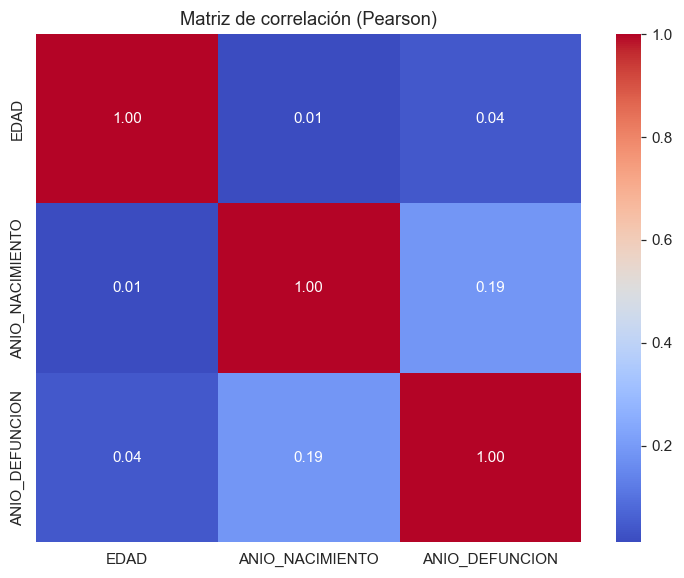

Chi² = 4366.127477756983  p-valor = 0.0
Cramer's V = 0.1350879860362921


In [9]:
# --- Correlación entre variables numéricas ---
num_vars_corr = ["EDAD", "ANIO_NACIMIENTO", "ANIO_DEFUNCION"]  
corr_matrix = df[num_vars_corr].corr(method="pearson")

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación (Pearson)")
plt.show()

# --- Asociación entre variables categóricas ---
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum()
    phi2 = chi2/n
    r,k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1),(rcorr-1)))

# Ejemplo: Escolaridad vs Sitio de defunción
contingencia = pd.crosstab(df["ESCOLARIDADD"], df["SITIO_DEFUNCIOND"])
chi2, p, dof, ex = chi2_contingency(contingencia)

print("Chi² =", chi2, " p-valor =", p)
print("Cramer's V =", cramers_v(contingencia.values))


**Reducción de dimensionalidad preliminar**

PCA (Análisis de Componentes Principales): útil para ver si unas pocas dimensiones explican gran parte de la variabilidad.

Sirve de antesala al Análisis Factorial Exploratorio (EFA), que será más profundo y lo trabajaremos en la sección siguiente.

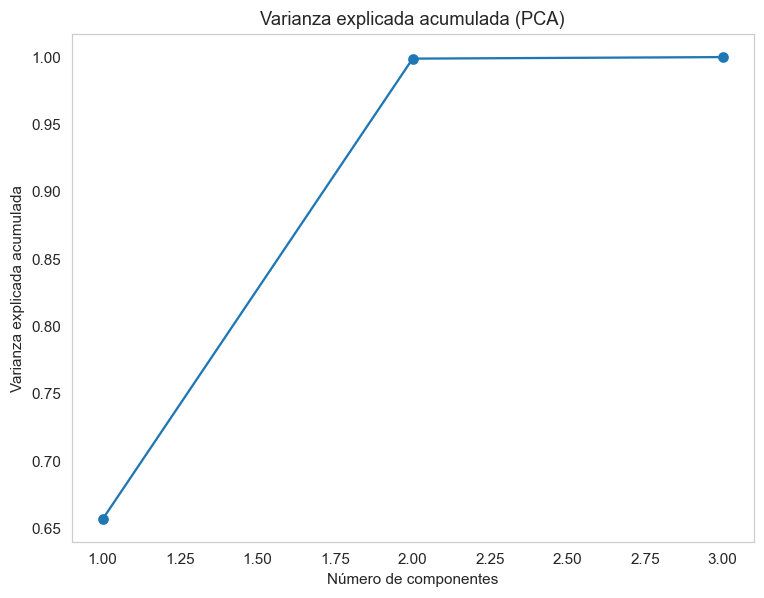

In [10]:
# Selección de variables numéricas para PCA
num_vars_pca = ["EDAD", "ANIO_NACIMIENTO", "ANIO_DEFUNCION"] 
X = df[num_vars_pca][(df[num_vars_pca] != 0).all(axis=1)]  # ignorar ceros

# Estandarizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA()
pca.fit(X_scaled)

# Varianza explicada
explained_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,6))
plt.plot(range(1, len(explained_var)+1), explained_var, marker="o")
plt.title("Varianza explicada acumulada (PCA)")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.grid()
plt.show()


**Identificación de patrones temporales y espaciales**

Tendencias en el tiempo (ya las graficamos, pero ahora podemos cuantificarlas con tasas de crecimiento o autocorrelación).

Comparación entre entidades federativas: índices normalizados para ver disparidades regionales.

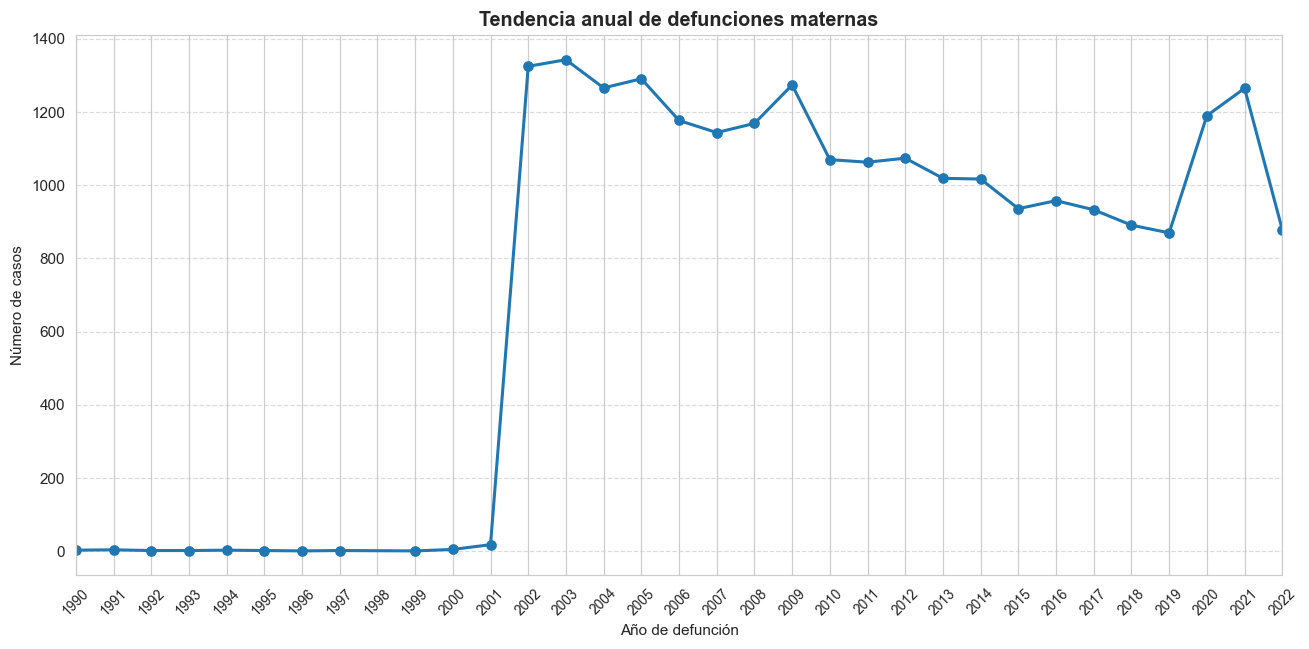

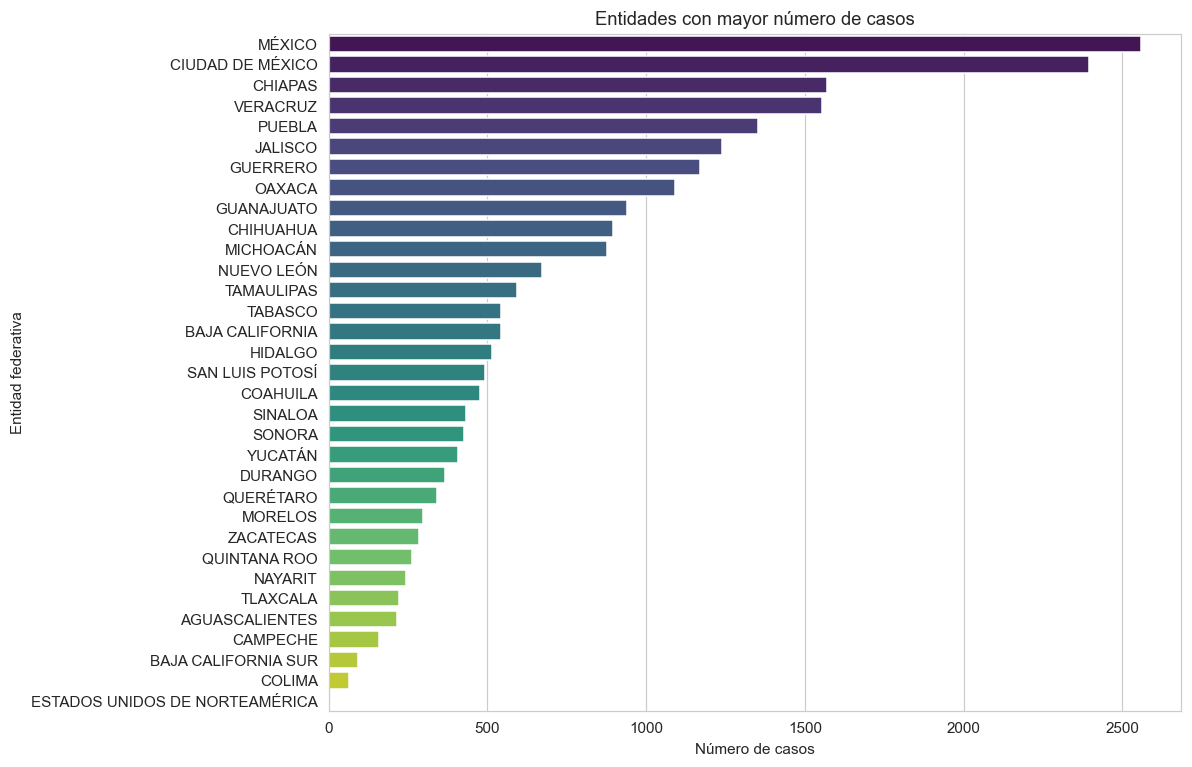

In [18]:
# --- Tendencias anuales (Corregido y Limpio para el Artículo) ---
# Filtramos los datos para ignorar los años erróneos (como el año 0 o 1900)
df_filtrado_años = df[(df["ANIO_DEFUNCION"] >= 1990) & (df["ANIO_DEFUNCION"] <= 2022)]

# Agrupamos usando únicamente los datos con años válidos
trend_year = df_filtrado_años.groupby("ANIO_DEFUNCION").size()

plt.figure(figsize=(12, 6))  # Un poco más ancho para que los años queden cómodos
plt.plot(trend_year.index, trend_year.values, marker="o", color="#1f77b4", linewidth=2)

# Forzamos el rango del eje X desde 1990 hasta 2022
plt.xlim(1990, 2022)

# Colocamos de forma exacta cada año y lo rotamos 45 grados para que no se encimen
plt.xticks(range(1990, 2023), rotation=45, fontsize=9)

plt.title("Tendencia anual de defunciones maternas", fontsize=13, fontweight='bold')
plt.xlabel("Año de defunción")
plt.ylabel("Número de casos")
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Cuadrícula sutil horizontal
plt.tight_layout()  # Evita que se corten los años al graficar
plt.show()

# --- Distribución por entidad (Tu código original sin cambios) ---
entidad_counts = df["ENTIDAD_OCURRENCIAD"].value_counts()

plt.figure(figsize=(10,8))
sns.barplot(x=entidad_counts.values, y=entidad_counts.index, hue=entidad_counts.index, palette="viridis", legend=False)
plt.title("Entidades con mayor número de casos")
plt.xlabel("Número de casos")
plt.ylabel("Entidad federativa")
plt.show()


**Pruebas estadísticas complementarias (ANOVA/Kruskal-Wallis para comparar medias entre grupos)**

ANOVA / Kruskal-Wallis → ver si la edad difiere significativamente entre grupos de estado conyugal.

Chi² → comprobar si hay relación significativa entre asistencia médica y sitio de defunción.

t-test → comparar la edad promedio entre quienes recibieron o no asistencia médica.

In [12]:
# --- ANOVA: comparación de medias de edad entre estados conyugales ---
anova_data = [group["EDAD"].values for name, group in df[df["EDAD"] > 0].groupby("ESTADO_CONYUGALD")]
anova_stat, anova_p = stats.f_oneway(*anova_data)

print("ANOVA - Edad vs Estado conyugal")
print("Estadístico F =", round(anova_stat, 3), " | p-valor =", round(anova_p, 5))

# --- Kruskal-Wallis: comparación no paramétrica ---
kw_stat, kw_p = stats.kruskal(*anova_data)
print("\nKruskal-Wallis - Edad vs Estado conyugal")
print("Estadístico H =", round(kw_stat, 3), " | p-valor =", round(kw_p, 5))


# --- Chi²: asociación entre asistencia médica y sitio de defunción ---
contingencia = pd.crosstab(df["ASISTENCIA_MEDICAD"], df["SITIO_DEFUNCIOND"])
chi2, p, dof, ex = stats.chi2_contingency(contingencia)

print("\nChi² - Asistencia médica vs Sitio de defunción")
print("Chi² =", round(chi2, 3), " | p-valor =", round(p, 5))


# --- Prueba t: diferencia de medias de edad entre dos grupos (ej. asistencia médica Sí vs No) ---
grupo_si = df[(df["ASISTENCIA_MEDICAD"] == "CON ATENCION MEDICA") & (df["EDAD"] > 0)]["EDAD"]
grupo_no = df[(df["ASISTENCIA_MEDICAD"] == "SIN ATENCION MEDICA") & (df["EDAD"] > 0)]["EDAD"]

t_stat, t_p = stats.ttest_ind(grupo_si, grupo_no, equal_var=False)

print("\nPrueba t - Edad entre defunciones con/sin asistencia médica")
print("t =", round(t_stat, 3), " | p-valor =", round(t_p, 5))


ANOVA - Edad vs Estado conyugal
Estadístico F = 248.38  | p-valor = 0.0

Kruskal-Wallis - Edad vs Estado conyugal
Estadístico H = 1657.326  | p-valor = 0.0

Chi² - Asistencia médica vs Sitio de defunción
Chi² = 7683.049  | p-valor = 0.0

Prueba t - Edad entre defunciones con/sin asistencia médica
t = -0.646  | p-valor = 0.51828


**Análisis Factorial Exploratorio (EFA)**

**Selección de variables y pruebas KMO / Bartlett**

In [13]:
# Selección de variables y pruebas de idoneidad (KMO y Bartlett)
# Variables candidatas 
vars_efa = [
    "ESCOLARIDAD",        # p.ej. 3 -> primaria incompleta
    "ASISTENCIA_MEDICA",  # índice numérico para categorías
    "DERECHOHABIENCIA",
    "SITIO_DEFUNCION",
    "TAMANIO_LOCALIDAD"
]

# Preparar dataframe: convertir 0 -> NaN y seleccionar filas completas
df_efa = df[vars_efa].replace(0, np.nan).copy()
print("Shape antes de dropear NA:", df_efa.shape)
df_efa = df_efa.dropna()
print("Shape después de dropear NA (filas completas):", df_efa.shape)

# Matriz de correlación (Pearson)
corr = df_efa.corr()
print("\nMatriz de correlación (preview):")
display(corr)

# KMO
kmo_all, kmo_model = calculate_kmo(df_efa)
print(f"\nKMO por variable (primeras 10):\n{pd.Series(kmo_all, index=df_efa.columns)}")
print(f"\nKMO global (modelo): {kmo_model:.3f}")

# Bartlett
chi_square_value, p_value = calculate_bartlett_sphericity(df_efa)
print(f"\nTest de Bartlett - chi2 = {chi_square_value:.3f}, p-value = {p_value:.5f}")

# Interpretación rápida sugerida:
# - KMO global >= 0.6: aceptable; >0.7 bueno; >0.8 muy bueno.
# - Bartlett p < 0.05 significa que la matriz de correlación no es identidad -> adecuado para EFA.


Shape antes de dropear NA: (23278, 5)
Shape después de dropear NA (filas completas): (19042, 5)

Matriz de correlación (preview):


,ESCOLARIDAD,ASISTENCIA_MEDICA,DERECHOHABIENCIA,SITIO_DEFUNCION,TAMANIO_LOCALIDAD
ESCOLARIDAD,1.00,-0.19,-0.01,-0.09,0.33
ASISTENCIA_MEDICA,-0.19,1.00,-0.05,0.40,-0.18
DERECHOHABIENCIA,-0.01,-0.05,1.00,-0.21,-0.09
SITIO_DEFUNCION,-0.09,0.40,-0.21,1.00,-0.07
TAMANIO_LOCALIDAD,0.33,-0.18,-0.09,-0.07,1.00



KMO por variable (primeras 10):
ESCOLARIDAD         0.59
ASISTENCIA_MEDICA   0.57
DERECHOHABIENCIA    0.50
SITIO_DEFUNCION     0.53
TAMANIO_LOCALIDAD   0.57
dtype: float64

KMO global (modelo): 0.554

Test de Bartlett - chi2 = 7628.309, p-value = 0.00000


**Extracción de factores: PCA (como guía exploratoria) y ML (preparación para EFA ML)** 

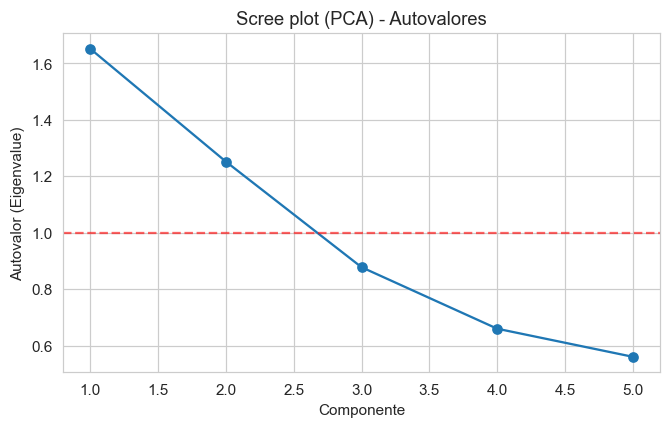

,autovalor,var_exp_ind,var_exp_acum
C1,1.65,0.33,0.33
C2,1.25,0.25,0.58
C3,0.88,0.18,0.76
C4,0.66,0.13,0.89
C5,0.56,0.11,1.00


In [14]:
# Usar df_efa resultante del Bloque 1 (filas sin NA)
X = df_efa.values.astype(float)

# Escalar
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

# PCA exploratorio
pca = PCA()
pca.fit(Xs)
eigenvalues = pca.explained_variance_

# Scree / eigenvalues PCA (mostramos primeros)
plt.figure(figsize=(7,4))
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, marker='o')
plt.axhline(1, color='red', linestyle='--', alpha=0.6)  # regla de Kaiser
plt.xlabel('Componente')
plt.ylabel('Autovalor (Eigenvalue)')
plt.title('Scree plot (PCA) - Autovalores')
plt.grid(True)
plt.show()

# Mostrar varianza explicada
explained = pca.explained_variance_ratio_
cumexp = np.cumsum(explained)
pd.DataFrame({
    "autovalor": eigenvalues,
    "var_exp_ind": explained,
    "var_exp_acum": cumexp
}, index=[f"C{i}" for i in range(1, len(eigenvalues)+1)]).round(4)

**Determinación del número de factores: Kaiser, Scree plot y Análisis paralelo**

Observaciones: 19042 Variables: 5


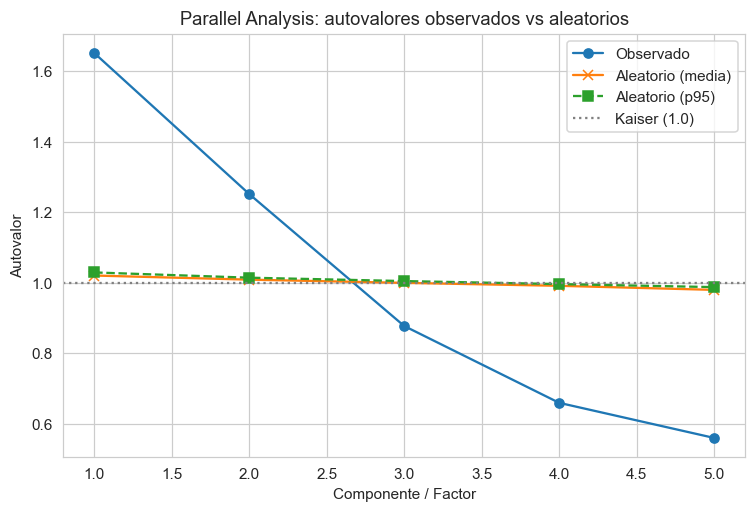

In [15]:
# Reusar Xs (escalado)
n_obs, n_vars = Xs.shape
print("Observaciones:", n_obs, "Variables:", n_vars)

# 1) Autovalores observados (ya en Bloque 2)
pca = PCA()
pca.fit(Xs)
eigvals_obs = pca.explained_variance_

# 2) Parallel Analysis (Montecarlo) - generar datasets aleatorios normales y calcular eigenvalues medios
n_iter = 100  # puedes aumentar a 500 si tienes tiempo
rng = np.random.default_rng(42)
eig_random = np.zeros((n_iter, n_vars))

for i in range(n_iter):
    R = rng.normal(size=(n_obs, n_vars))
    R = (R - R.mean(axis=0)) / R.std(axis=0)  # estandarizar columnas
    pca_r = PCA()
    pca_r.fit(R)
    eig_random[i, :] = pca_r.explained_variance_

# Calcular eigenvalues promedio de los datos aleatorios y percentil 95
eig_rand_mean = eig_random.mean(axis=0)
eig_rand_p95 = np.percentile(eig_random, 95, axis=0)

# Plot: Observado vs Random mean (y 95%)
plt.figure(figsize=(8,5))
components = np.arange(1, n_vars+1)
plt.plot(components, eigvals_obs, marker='o', linestyle='-', label='Observado')
plt.plot(components, eig_rand_mean, marker='x', linestyle='-', label='Aleatorio (media)', markerfacecolor='none')
plt.plot(components, eig_rand_p95, marker='s', linestyle='--', label='Aleatorio (p95)')  # <- CORRECCIÓN: usar linestyle para '--'
plt.axhline(1, color='gray', linestyle=':', label='Kaiser (1.0)')
plt.xlabel('Componente / Factor')
plt.ylabel('Autovalor')
plt.title('Parallel Analysis: autovalores observados vs aleatorios')
plt.legend()
plt.grid(True)
plt.show()

# Reglas de decisión rápida:
# - Kaiser: retener autovalores > 1.
# - Scree: buscar "codo".
# - Parallel analysis: retener factores cuyo autovalor observado > autovalor aleatorio (p95 o media).


**Rotación de factores: Varimax (ortogonal) y Promax (oblicua)**

In [24]:
#- La advertencia persistirá porque factor_analyzer aún usa el parámetro antiguo internamente.
#- No hay una versión más nueva de factor_analyzer que lo corrija (al menos hasta hoy).
#- Mantener hasta actualizar factor_analyzer

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


# Define número de factores a retener según Bloque 3 (ajusta 'n_factors' tras inspección)
n_factors = 2  # <-- AJUSTA esto según los resultados previos (Kaiser / Parallel)

# FactorAnalyzer (método 'principal' o 'ml'): aquí usamos 'ml' para máxima verosimilitud
fa_ml = FactorAnalyzer(n_factors=n_factors, method='ml', rotation=None)
fa_ml.fit(df_efa.values)

# Cargas sin rotación
loadings_unrot = pd.DataFrame(fa_ml.loadings_, index=df_efa.columns, columns=[f"F{i+1}" for i in range(n_factors)])
print("Cargas (sin rotación):")
display(loadings_unrot.round(3))

# Varimax (ortogonal)
fa_varimax = FactorAnalyzer(n_factors=n_factors, method='ml', rotation='varimax')
fa_varimax.fit(df_efa.values)
loadings_varimax = pd.DataFrame(fa_varimax.loadings_, index=df_efa.columns, columns=[f"F{i+1}" for i in range(n_factors)])
print("\nCargas (Varimax):")
display(loadings_varimax.round(3))

# Promax (oblicua)
fa_promax = FactorAnalyzer(n_factors=n_factors, method='ml', rotation='promax')
fa_promax.fit(df_efa.values)
loadings_promax = pd.DataFrame(fa_promax.loadings_, index=df_efa.columns, columns=[f"F{i+1}" for i in range(n_factors)])
print("\nCargas (Promax):")
display(loadings_promax.round(3))

# Comunidades (communalities) y varianza explicada
communalities = pd.Series(fa_varimax.get_communalities(), index=df_efa.columns)
variance = pd.Series(fa_varimax.get_factor_variance()[1], index=[f"F{i+1}" for i in range(n_factors)])  # varianza por factor
explained_percent = pd.Series(fa_varimax.get_factor_variance()[2], index=[f"F{i+1}" for i in range(n_factors)])  # %
print("\nComunalidades:")
display(communalities.round(3))
print("\nVarianza por factor (%, cada factor):")
display(explained_percent.round(3))


TypeError: check_array() got an unexpected keyword argument 'force_all_finite'. Did you mean 'ensure_all_finite'?

**Interpretación: máscaras de cargas (>0.3), tablas resumen y guardado de resultados**

In [ ]:
# Escoge la rotación final que prefieras (varimax o promax)
loadings_final = loadings_varimax.copy()  # o loadings_promax

threshold = 0.30
print(f"Cargas factoriales (umbral > {threshold}):\n")
loadings_masked = loadings_final.where(loadings_final.abs() >= threshold, other=np.nan)
display(loadings_masked.round(3))

# Construir un resumen por factor: variables que cargan fuertemente en cada factor
for factor in loadings_final.columns:
    strong = loadings_final[loadings_final[factor].abs() >= threshold].sort_values(by=factor, ascending=False)
    print(f"\nVariables con carga >= {threshold} en {factor}:")
    if strong.empty:
        print("  - Ninguna")
    else:
        for var, val in strong[factor].items():
            print(f"  - {var}: {val:.3f}")

# Por último, mostrar % de varianza total explicada por los factores retenidos
total_explained = fa_varimax.get_factor_variance()[2].sum()  # porcentaje total
print(f"\n% Varianza total explicada por los {n_factors} factores retenidos: {total_explained:.2f}%")

# (Opcional) Guardar loadings y communalities en objetos/CSV si quieres revisarlos después:
# loadings_final.to_csv("efa_loadings_varimax.csv")
# communalities.to_csv("efa_communalities.csv")


Cargas factoriales (umbral > 0.3):



,F1,F2
ESCOLARIDAD,NaN,0.53
ASISTENCIA_MEDICA,0.36,-0.32
DERECHOHABIENCIA,NaN,NaN
SITIO_DEFUNCION,0.96,NaN
TAMANIO_LOCALIDAD,NaN,0.62



Variables con carga >= 0.3 en F1:
  - SITIO_DEFUNCION: 0.963
  - ASISTENCIA_MEDICA: 0.360

Variables con carga >= 0.3 en F2:
  - TAMANIO_LOCALIDAD: 0.624
  - ESCOLARIDAD: 0.529
  - ASISTENCIA_MEDICA: -0.324

% Varianza total explicada por los 2 factores retenidos: 0.61%


**Calcular proporciones relativas (%) o tasas por 100,000 habitantes para las variables ENTIDAD_OCURRENCIAD, ESTADO_CONYUGALD, RAZON_MORTALIDAD_MATERNAD**

Proporción por ENTIDAD_OCURRENCIAD (ajustada por población total)**

Proporción por ESTADO_CONYUGALD (porcentaje sobre población total nacional)**
Este gráfico no busca tasas por 100,000 hab. (pues no hay una base poblacional específica por estado civil en el censo general),
sino proporciones relativas dentro del total de muertes registradas, ajustadas al peso poblacional global

Proporción por RAZON_MORTALIDAD_MATERNAD

Columnas del censo: ['ENTIDAD_FEDERATIVA', 'POBLACION', 'SUPERFICIE_KM2', 'GRADO_MARGINACION', 'INDICE_MARGINACION_NORMALIZADO', 'PO2SM', 'ANALF', 'SBASC', 'MATRIMONIOS', 'DIVORCIOS', 'PDSS', 'PPDSP', 'PPD_PEMEX_SDN_SM', 'PPSMP', 'PPD_ISSSTE', 'PPD_IMSS']
Proporción de defunciones maternas por 100,000 habitantes:


,ENTIDAD_FEDERATIVA,DEFUNCIONES,POBLACION,TASA_X_100K
6,GUERRERO,1169,"3,540,685.00",33.02
2,CHIAPAS,1569,"5,543,828.00",28.30
7,OAXACA,1090,"4,132,148.00",26.38
1,CIUDAD DE MÉXICO,2393,"9,209,944.00",25.98
9,CHIHUAHUA,896,"3,741,869.00",23.95
13,TABASCO,544,"2,402,598.00",22.64
4,PUEBLA,1352,"6,583,278.00",20.54
21,DURANGO,366,"1,832,650.00",19.97
26,NAYARIT,243,"1,235,456.00",19.67
3,VERACRUZ,1555,"8,062,579.00",19.29


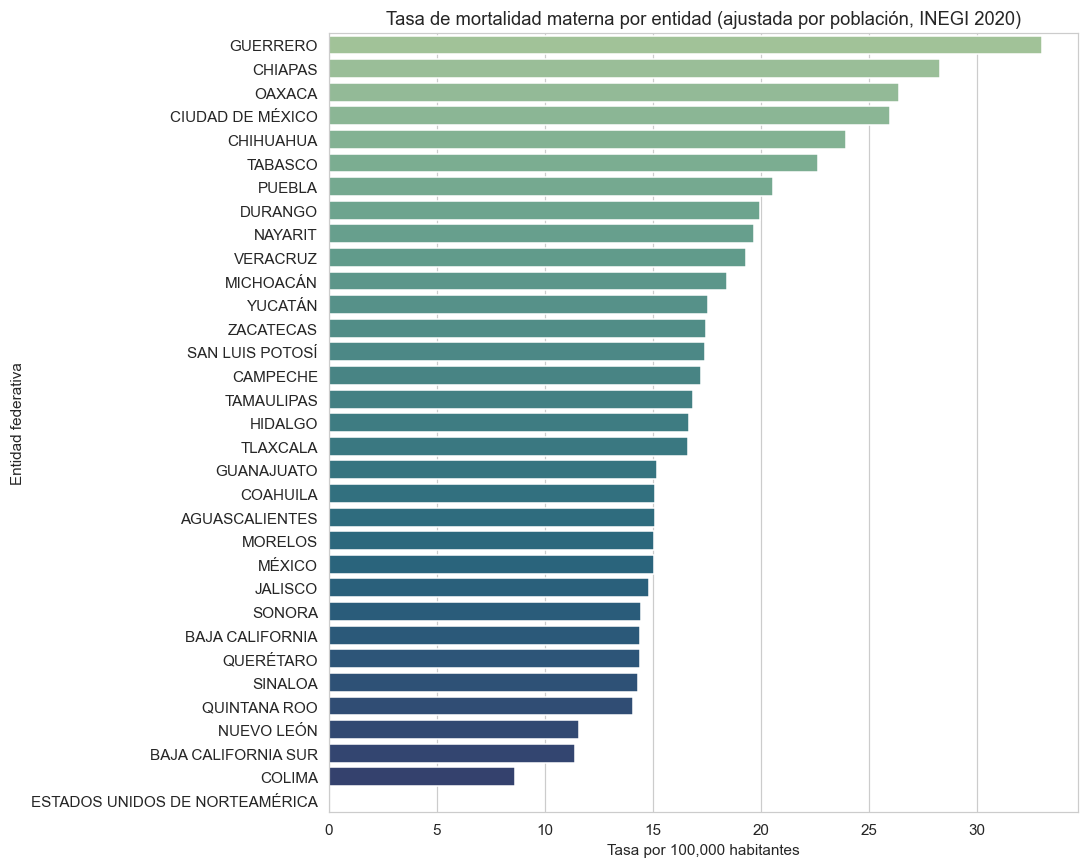

Distribución proporcional de mortalidad materna por estado conyugal:


,ESTADO_CONYUGALD,DEFUNCIONES,PORCENTAJE
0,CASADO,9582,41.16
6,UNION LIBRE,8986,38.60
5,SOLTERO,3581,15.38
3,SE IGNORA,651,2.80
7,VIUDO,175,0.75
1,DIVORCIADO,152,0.65
4,SEPARADO,150,0.64
2,NO APLICA A MENORES DE 12 AÑOS,1,0.00


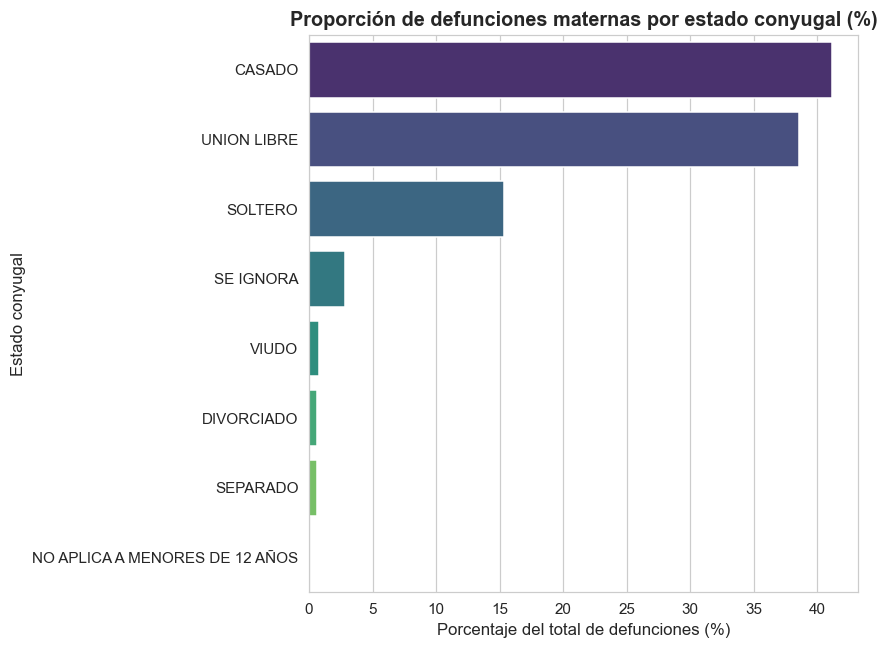

Distribución proporcional de defunciones por razón de mortalidad materna:


,RAZON_MORTALIDAD_MATERNAD,DEFUNCIONES,PORCENTAJE
0,MUERTES MATERNAS PARA LA RAZÓN DE MORTALIDAD MATERNA,20902,89.79
1,MUERTES MATERNAS EXCLUIDAS PARA LA RAZÓN DE MORTALIDAD MATERNA,2376,10.21


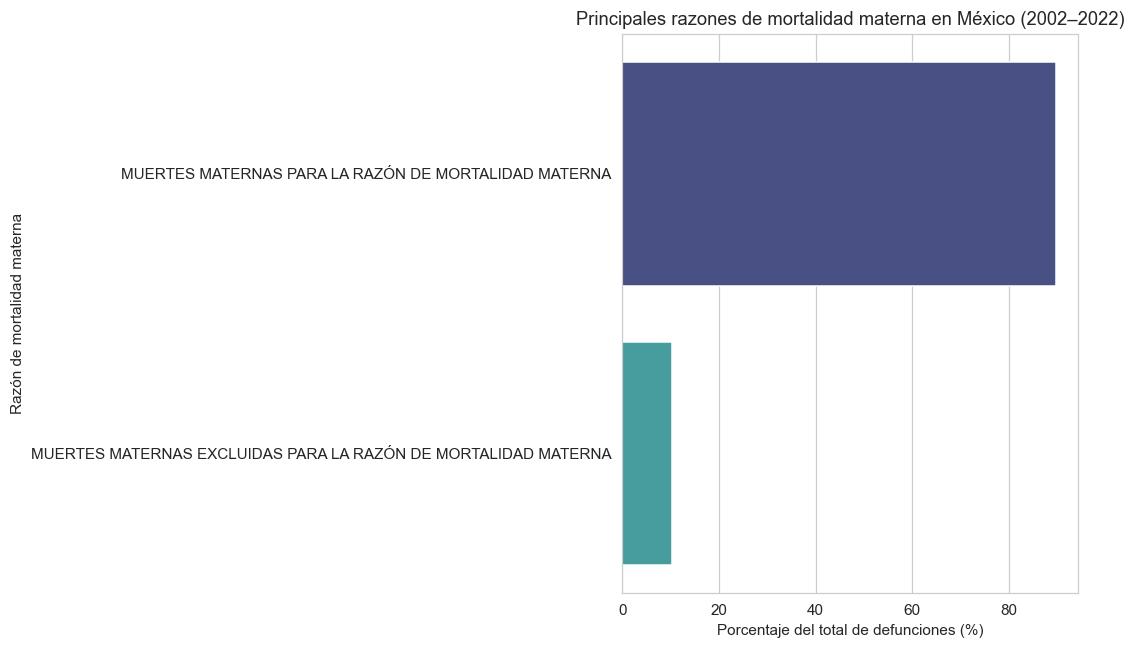

In [ ]:
# ENTIDAD_OCURRENCIAD (Proporcional al tamaño poblacional)
# Agrupar y contar defunciones por entidad
ocurrencias = df['ENTIDAD_OCURRENCIAD'].value_counts().reset_index()
ocurrencias.columns = ['ENTIDAD_FEDERATIVA', 'DEFUNCIONES'] 

# Verificar las columnas del censo
print("Columnas del censo:", censo.columns.tolist())

# Unir con el censo
proporcional = pd.merge(ocurrencias, censo, on='ENTIDAD_FEDERATIVA', how='left')

# Calcular proporción por 100,000 habitantes
proporcional['TASA_X_100K'] = (proporcional['DEFUNCIONES'] / proporcional['POBLACION']) * 100000

# Ordenar de mayor a menor
proporcional = proporcional.sort_values(by='TASA_X_100K', ascending=False)

# Mostrar tabla resumida
print("Proporción de defunciones maternas por 100,000 habitantes:")
display(proporcional[['ENTIDAD_FEDERATIVA', 'DEFUNCIONES', 'POBLACION', 'TASA_X_100K']].round(2))

# ---- Visualización ----
plt.figure(figsize=(10, 8))
sns.barplot(
    data=proporcional,
    y='ENTIDAD_FEDERATIVA',
    x='TASA_X_100K',
    palette='crest'
)
plt.title('Tasa de mortalidad materna por entidad (ajustada por población, INEGI 2020)')
plt.xlabel('Tasa por 100,000 habitantes')
plt.ylabel('Entidad federativa')
plt.tight_layout()
plt.show()


#ESTADO_CONYUGALD (Proporción dentro del total nacional)
# Agrupar defunciones por estado conyugal usando el DataFrame ya cargado
conyugal = (
    df.groupby('ESTADO_CONYUGALD')
      .size()
      .reset_index(name='DEFUNCIONES')
      .sort_values(by='DEFUNCIONES', ascending=False)
)

# Calcular proporción (%) respecto al total
total_def = conyugal['DEFUNCIONES'].sum()
conyugal['PORCENTAJE'] = (conyugal['DEFUNCIONES'] / total_def) * 100

# Mostrar tabla
print("Distribución proporcional de mortalidad materna por estado conyugal:")
display(conyugal.round(2))

# ---- Visualización ----
plt.figure(figsize=(8, 6))
sns.barplot(
    data=conyugal,
    x='PORCENTAJE',
    y='ESTADO_CONYUGALD',
    palette='viridis'
)
plt.title('Proporción de defunciones maternas por estado conyugal (%)', fontsize=13, weight='bold')
plt.xlabel('Porcentaje del total de defunciones (%)', fontsize=11)
plt.ylabel('Estado conyugal', fontsize=11)
plt.tight_layout()
plt.show()


# RAZON_MORTALIDAD_MATERNAD Proporción de causas de mortalidad materna
# Agrupar y contar defunciones por causa
causas = df['RAZON_MORTALIDAD_MATERNAD'].value_counts().reset_index()
causas.columns = ['RAZON_MORTALIDAD_MATERNAD', 'DEFUNCIONES']

# Calcular proporción (%) sobre el total
total_def = causas['DEFUNCIONES'].sum()
causas['PORCENTAJE'] = (causas['DEFUNCIONES'] / total_def) * 100

# Ordenar de mayor a menor
causas = causas.sort_values(by='PORCENTAJE', ascending=False)

# Mostrar tabla resumen
print("Distribución proporcional de defunciones por razón de mortalidad materna:")
display(causas.round(2))

# ---- Visualización ----
plt.figure(figsize=(10, 6))
sns.barplot(
    data=causas.head(10),  # Top 10 razones más frecuentes
    x='PORCENTAJE',
    y='RAZON_MORTALIDAD_MATERNAD',
    palette='mako'
)
plt.title('Principales razones de mortalidad materna en México (2002–2022)')
plt.xlabel('Porcentaje del total de defunciones (%)')
plt.ylabel('Razón de mortalidad materna')
plt.tight_layout()
plt.show()


**Ajuste por densidad poblacional**

Vista general del ajuste por densidad poblacional:



,ENTIDAD_OCURRENCIAD,POBLACION,SUPERFICIE_KM2,DENSIDAD_POBLACIONAL,MUERTES_MATERNAS,MUERTES_POR_DENSIDAD
0,AGUASCALIENTES,"1,425,607.00","5,615.70",253.86,215,0.85
1,BAJA CALIFORNIA,"3,769,020.00","71,450.00",52.75,543,10.29
2,BAJA CALIFORNIA SUR,"798,447.00","73,909.40",10.80,91,8.42
3,CAMPECHE,"928,363.00","57,484.90",16.15,160,9.91
4,CHIAPAS,"5,543,828.00","73,311.00",75.62,1569,20.75
5,CHIHUAHUA,"3,741,869.00","247,412.60",15.12,896,59.24
6,CIUDAD DE MÉXICO,"9,209,944.00","1,494.30","6,163.38",2393,0.39
7,COAHUILA,"3,146,771.00","151,594.80",20.76,475,22.88
8,COLIMA,"731,391.00","5,626.90",129.98,63,0.48
9,DURANGO,"1,832,650.00","123,364.00",14.86,366,24.64


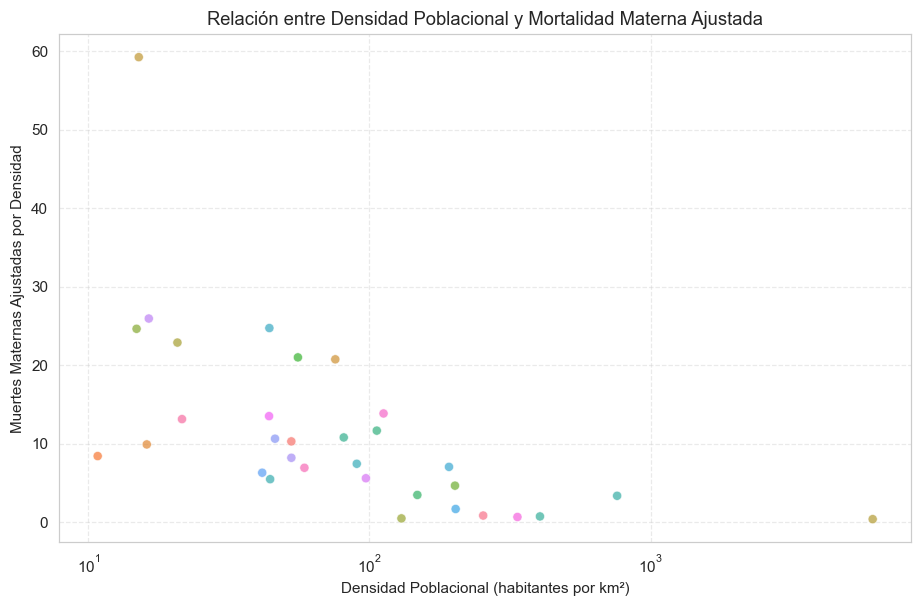

Promedio de mortalidad materna ajustada por densidad (2002-2022):


,ENTIDAD_OCURRENCIAD,POBLACION,SUPERFICIE_KM2,DENSIDAD_POBLACIONAL,MUERTES_MATERNAS,MUERTES_POR_DENSIDAD
5,CHIHUAHUA,"3,741,869.00","247,412.60",15.12,896,59.24
25,SONORA,"2,944,840.00","179,354.70",16.42,426,25.95
19,OAXACA,"4,132,148.00","93,757.60",44.07,1090,24.73
9,DURANGO,"1,832,650.00","123,364.00",14.86,366,24.64
7,COAHUILA,"3,146,771.00","151,594.80",20.76,475,22.88
11,GUERRERO,"3,540,685.00","63,595.90",55.67,1169,21.00
4,CHIAPAS,"5,543,828.00","73,311.00",75.62,1569,20.75
29,VERACRUZ,"8,062,579.00","71,823.50",112.26,1555,13.85
27,TAMAULIPAS,"3,527,735.00","80,249.30",43.96,594,13.51
31,ZACATECAS,"1,622,138.00","75,275.30",21.55,283,13.13



 Correlación entre densidad poblacional y muertes ajustadas: -0.230
 Las entidades con mayor densidad poblacional tienden a tener menor mortalidad ajustada, posiblemente por mejor infraestructura hospitalaria.


In [ ]:
# Agrupar los registros de mortalidad por ENTIDAD
muertes_por_entidad = (
    df.groupby(['ENTIDAD_OCURRENCIAD'], as_index=False)
    .size()
    .rename(columns={'size': 'MUERTES_MATERNAS'})
)

# Unificar con la base del censo (población y superficie)
df_ajustada = muertes_por_entidad.merge(
    censo[['ENTIDAD_FEDERATIVA', 'POBLACION', 'SUPERFICIE_KM2']],
    left_on='ENTIDAD_OCURRENCIAD',
    right_on='ENTIDAD_FEDERATIVA',
    how='left'
)

# Calcular densidad poblacional (hab/km²)
df_ajustada['DENSIDAD_POBLACIONAL'] = df_ajustada['POBLACION'] / df_ajustada['SUPERFICIE_KM2']

# Calcular muertes ajustadas por densidad poblacional
df_ajustada['MUERTES_POR_DENSIDAD'] = df_ajustada['MUERTES_MATERNAS'] / df_ajustada['DENSIDAD_POBLACIONAL']

# Limpieza de valores
df_ajustada.replace([np.inf, -np.inf], np.nan, inplace=True)
df_ajustada.dropna(subset=['DENSIDAD_POBLACIONAL', 'MUERTES_POR_DENSIDAD'], inplace=True)

# Vista general del nuevo dataset
print("Vista general del ajuste por densidad poblacional:\n")
display(df_ajustada[['ENTIDAD_OCURRENCIAD', 'POBLACION', 'SUPERFICIE_KM2','DENSIDAD_POBLACIONAL', 'MUERTES_MATERNAS', 'MUERTES_POR_DENSIDAD']].round(2))

# Visualización: Densidad poblacional vs muertes ajustadas
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_ajustada,
    x='DENSIDAD_POBLACIONAL',
    y='MUERTES_POR_DENSIDAD',
    hue='ENTIDAD_OCURRENCIAD',
    alpha=0.7,
    legend=False
)
plt.title('Relación entre Densidad Poblacional y Mortalidad Materna Ajustada')
plt.xlabel('Densidad Poblacional (habitantes por km²)')
plt.ylabel('Muertes Maternas Ajustadas por Densidad')
plt.xscale('log')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

# Resumen por entidad
resumen_densidad = (
    df_ajustada
    .groupby('ENTIDAD_OCURRENCIAD', as_index=False)
    .agg({
        'POBLACION': 'mean',
        'SUPERFICIE_KM2': 'mean',
        'DENSIDAD_POBLACIONAL': 'mean',
        'MUERTES_MATERNAS': 'sum',
        'MUERTES_POR_DENSIDAD': 'mean'
    })
    .sort_values(by='MUERTES_POR_DENSIDAD', ascending=False)
)

print("Promedio de mortalidad materna ajustada por densidad (2002-2022):")
display(resumen_densidad.round(2))

# Interpretación automática
densidad_corr = resumen_densidad['DENSIDAD_POBLACIONAL'].corr(resumen_densidad['MUERTES_POR_DENSIDAD'])
print(f"\n Correlación entre densidad poblacional y muertes ajustadas: {densidad_corr:.3f}")

if densidad_corr < 0:
    print(" Las entidades con mayor densidad poblacional tienden a tener menor mortalidad ajustada, posiblemente por mejor infraestructura hospitalaria.")
elif densidad_corr > 0:
    print(" Las entidades más densamente pobladas tienden a concentrar más mortalidad ajustada, lo que podría reflejar desigualdad urbana o saturación médica.")
else:
    print(" No se observa una correlación clara entre densidad y mortalidad ajustada.")


**Análisis de relación entre mortalidad materna, marginación y pobreza (CONAPO + INEGI)**

⚙️ No se encontraron variables de CONAPO en df_ajustada. Realizando merge extendido...

📊 Resumen del DataFrame con variables socioeconómicas y mortalidad:



,ENTIDAD_OCURRENCIAD,GRADO_MARGINACION,INDICE_MARGINACION_NORMALIZADO,PO2SM,POBLACION,SUPERFICIE_KM2,DENSIDAD_POBLACIONAL,MUERTES_MATERNAS,MUERTES_AJUSTADAS,MUERTES_POR_100K
12,GUERRERO,MUY ALTO,0.40,80.28,"3,540,685.00","63,595.90",55.67,1169,21.00,33.02
4,CHIAPAS,MUY ALTO,0.44,85.57,"5,543,828.00","73,311.00",75.62,1569,20.75,28.30
20,OAXACA,MUY ALTO,0.49,78.85,"4,132,148.00","93,757.60",44.07,1090,24.73,26.38
30,VERACRUZ,ALTO,0.60,78.12,"8,062,579.00","71,823.50",112.26,1555,13.85,19.29
31,YUCATÁN,ALTO,0.64,69.68,"2,320,898.00","39,524.40",58.72,407,6.93,17.54
18,NAYARIT,ALTO,0.64,64.82,"1,235,456.00","27,856.50",44.35,243,5.48,19.67
21,PUEBLA,ALTO,0.65,77.30,"6,583,278.00","34,309.60",191.88,1352,7.05,20.54
3,CAMPECHE,ALTO,0.66,70.01,"928,363.00","57,484.90",16.15,160,9.91,17.23
13,HIDALGO,ALTO,0.66,73.95,"3,082,841.00","20,821.40",148.06,514,3.47,16.67
15,MICHOACÁN,ALTO,0.67,70.62,"4,748,846.00","58,598.70",81.04,875,10.80,18.43



📊 Resumen del DataFrame con variables socioeconómicas y mortalidad:



,ENTIDAD_OCURRENCIAD,GRADO_MARGINACION,INDICE_MARGINACION_NORMALIZADO,PO2SM,POBLACION
12,GUERRERO,MUY ALTO,0.40,80.28,"3,540,685.00"
4,CHIAPAS,MUY ALTO,0.44,85.57,"5,543,828.00"
20,OAXACA,MUY ALTO,0.49,78.85,"4,132,148.00"
30,VERACRUZ,ALTO,0.60,78.12,"8,062,579.00"
31,YUCATÁN,ALTO,0.64,69.68,"2,320,898.00"
18,NAYARIT,ALTO,0.64,64.82,"1,235,456.00"
21,PUEBLA,ALTO,0.65,77.30,"6,583,278.00"
3,CAMPECHE,ALTO,0.66,70.01,"928,363.00"
13,HIDALGO,ALTO,0.66,73.95,"3,082,841.00"
15,MICHOACÁN,ALTO,0.67,70.62,"4,748,846.00"


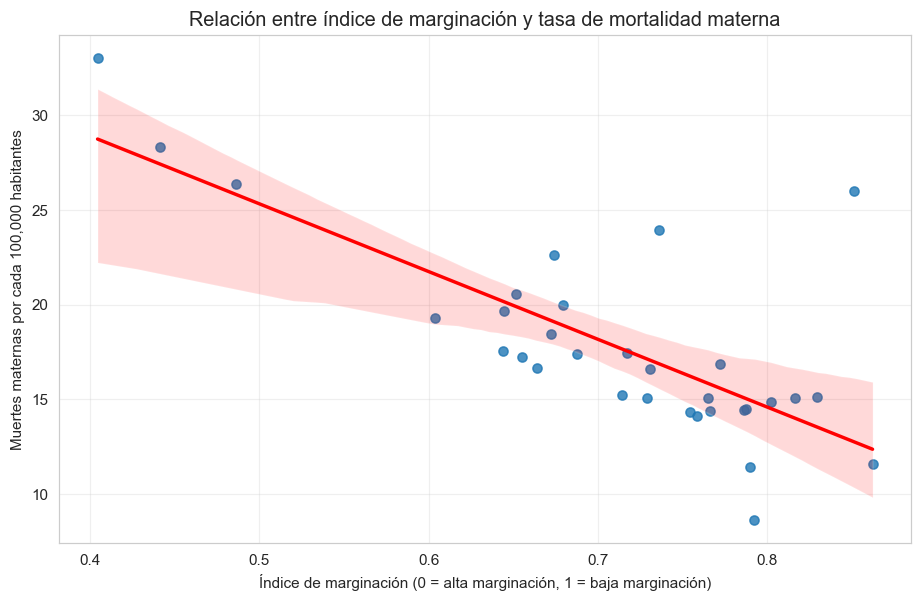

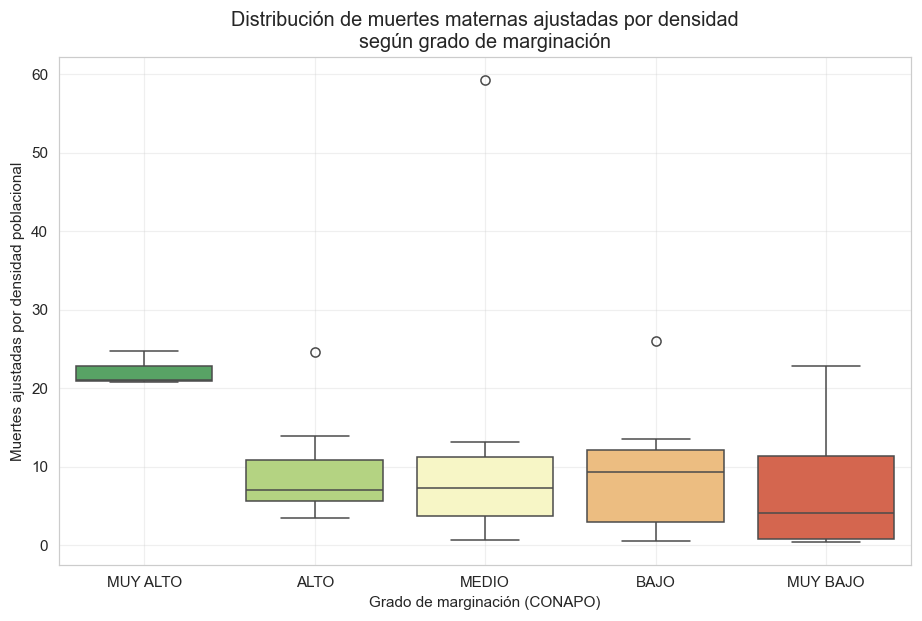

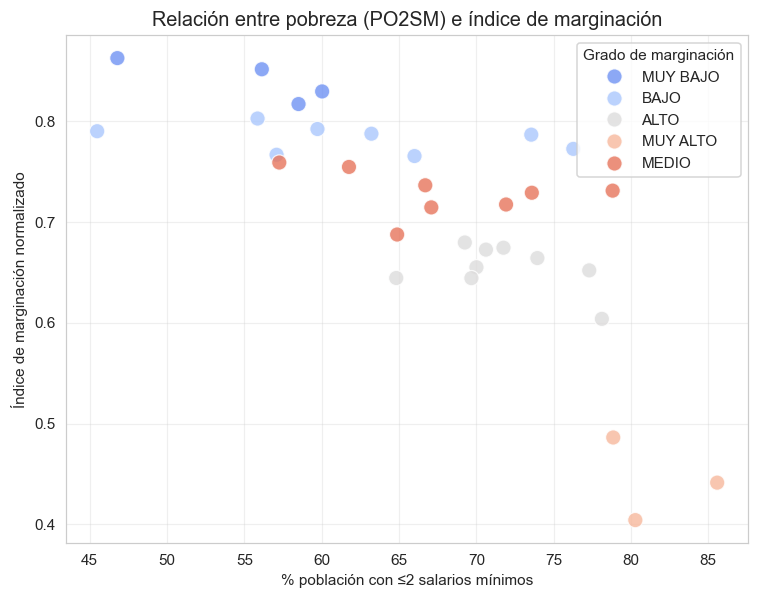

In [ ]:
# Verificar si el DataFrame df_ajustada ya contiene variables de marginación y pobreza
expected_vars = {"GRADO_MARGINACION", "INDICE_MARGINACION_NORMALIZADO", "PO2SM"}

if 'df_ajustada' in locals() and expected_vars.issubset(set(df_ajustada.columns)):
    print("✅ Reutilizando el DataFrame df_ajustada existente con variables de CONAPO.")
    df_marginacion = df_ajustada.copy()
else:
    print("⚙️ No se encontraron variables de CONAPO en df_ajustada. Realizando merge extendido...")
    # Agrupar registros de mortalidad por entidad
    muertes_por_entidad = (
        df.groupby(['ENTIDAD_OCURRENCIAD'], as_index=False)
        .size()
        .rename(columns={'size': 'MUERTES_MATERNAS'})
    )

    # Unificar con la base del censo incluyendo variables socioeconómicas
    df_marginacion = muertes_por_entidad.merge(
        censo[['ENTIDAD_FEDERATIVA', 'POBLACION', 'SUPERFICIE_KM2',
                'GRADO_MARGINACION', 'INDICE_MARGINACION_NORMALIZADO', 'PO2SM']],
        left_on='ENTIDAD_OCURRENCIAD',
        right_on='ENTIDAD_FEDERATIVA',
        how='left'
    )

# Calcular densidad poblacional y muertes ajustadas
df_marginacion['DENSIDAD_POBLACIONAL'] = df_marginacion['POBLACION'] / df_marginacion['SUPERFICIE_KM2']
df_marginacion['MUERTES_AJUSTADAS'] = df_marginacion['MUERTES_MATERNAS'] / df_marginacion['DENSIDAD_POBLACIONAL']

# Calcular proporciones y relaciones clave
df_marginacion['MUERTES_POR_100K'] = (df_marginacion['MUERTES_MATERNAS'] / df_marginacion['POBLACION']) * 100000

# Ordenar por índice de marginación (de menor a mayor desarrollo)
df_marginacion_sorted = df_marginacion.sort_values('INDICE_MARGINACION_NORMALIZADO', ascending=True)

# Mostrar resumen tabular de los primeros resultados
print("\n📊 Resumen del DataFrame con variables socioeconómicas y mortalidad:\n")
display(df_marginacion_sorted[['ENTIDAD_OCURRENCIAD', 'GRADO_MARGINACION',
                                'INDICE_MARGINACION_NORMALIZADO', 'PO2SM',
                                'POBLACION', 'SUPERFICIE_KM2',
                                'DENSIDAD_POBLACIONAL', 'MUERTES_MATERNAS',
                                'MUERTES_AJUSTADAS', 'MUERTES_POR_100K']].round(2))

print("\n📊 Resumen del DataFrame con variables socioeconómicas y mortalidad:\n")
display(df_marginacion_sorted[['ENTIDAD_OCURRENCIAD', 'GRADO_MARGINACION',
                                'INDICE_MARGINACION_NORMALIZADO', 'PO2SM',
                                'POBLACION']].round(2))

# Gráficos exploratorios iniciales

# --- a) Relación entre índice de marginación y muertes maternas
plt.figure(figsize=(10,6))
sns.regplot(
    data=df_marginacion, 
    x='INDICE_MARGINACION_NORMALIZADO', 
    y='MUERTES_POR_100K',
    scatter_kws={'alpha':0.8}, line_kws={'color':'red'}
)
plt.title("Relación entre índice de marginación y tasa de mortalidad materna", fontsize=13)
plt.xlabel("Índice de marginación (0 = alta marginación, 1 = baja marginación)")
plt.ylabel("Muertes maternas por cada 100,000 habitantes")
plt.grid(True, alpha=0.3)
plt.show()

# --- b) Comparación entre grado de marginación y muertes ajustadas
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df_marginacion,
    x='GRADO_MARGINACION', 
    y='MUERTES_AJUSTADAS',
    order=['MUY ALTO', 'ALTO', 'MEDIO', 'BAJO', 'MUY BAJO'],
    palette='RdYlGn_r'
)
plt.title("Distribución de muertes maternas ajustadas por densidad\nsegún grado de marginación", fontsize=13)
plt.xlabel("Grado de marginación (CONAPO)")
plt.ylabel("Muertes ajustadas por densidad poblacional")
plt.grid(True, alpha=0.3)
plt.show()

# --- c) Correlación entre pobreza (PO2SM) e índice de marginación
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_marginacion,
    x='PO2SM', 
    y='INDICE_MARGINACION_NORMALIZADO',
    hue='GRADO_MARGINACION',
    palette='coolwarm', s=100, alpha=0.8
)
plt.title("Relación entre pobreza (PO2SM) e índice de marginación", fontsize=13)
plt.xlabel("% población con ≤2 salarios mínimos")
plt.ylabel("Índice de marginación normalizado")
plt.legend(title="Grado de marginación")
plt.grid(True, alpha=0.3)
plt.show()

**Análisis: Cruce ESCOLARIDADD (fallecidas) vs ANALF / SBASC (censo)**

*Proporción de fallecidas por nivel educativo por entidad*

*Indicadores socioeducativos del censo*

*Medidas comparativas*

Aporta evidencia robusta. Relaciona mortalidad materna con determinantes estructurales (educación). Confirma desigualdades territoriales. No sólo dice “hubo muertes”, sino por qué y en qué contexto social. Permite recomendaciones de política pública

ANALF que es "Porcentaje de población analfabeta de 15 años o más" 

SBASC que es "Porcentaje de población de 15 años o más sin educación básica"

Tabla 1 — Entidades por desproporción en analfabetismo (fallecidas % - ANALF):


,ENTIDAD_OCURRENCIAD,TOTAL_FALLECIDAS,POBLACION,ANALF,pct_fallecidas_sin_escolaridad,desprop_analf,muertes_por_100k
5,CHIHUAHUA,896,"3,741,869.00",2.63,19.75,17.12,23.95
18,NAYARIT,243,"1,235,456.00",4.49,15.23,10.74,19.67
4,CHIAPAS,1569,"5,543,828.00",13.70,21.99,8.29,28.30
12,GUERRERO,1169,"3,540,685.00",12.47,18.14,5.66,33.02
9,DURANGO,366,"1,832,650.00",2.73,6.56,3.83,19.97
23,QUINTANA ROO,262,"1,857,985.00",3.07,6.49,3.42,14.10
30,VERACRUZ,1555,"8,062,579.00",8.50,11.06,2.56,19.29
16,MORELOS,297,"1,971,520.00",4.45,6.73,2.29,15.06
31,YUCATÁN,407,"2,320,898.00",6.00,8.11,2.11,17.54
22,QUERÉTARO,341,"2,368,467.00",3.48,5.28,1.80,14.40


Tabla 2 — Entidades por desproporción en SBASC (fallecidas % - SBASC):


,ENTIDAD_OCURRENCIAD,TOTAL_FALLECIDAS,POBLACION,SBASC,pct_fallecidas_sin_educ_basica,desprop_sbasc,muertes_por_100k
5,CHIHUAHUA,896,"3,741,869.00",27.30,33.26,5.95,23.95
18,NAYARIT,243,"1,235,456.00",29.05,33.33,4.28,19.67
23,QUINTANA ROO,262,"1,857,985.00",22.53,24.05,1.52,14.10
4,CHIAPAS,1569,"5,543,828.00",48.12,49.08,0.96,28.30
31,YUCATÁN,407,"2,320,898.00",31.55,29.98,-1.57,17.54
12,GUERRERO,1169,"3,540,685.00",42.55,40.98,-1.58,33.02
6,CIUDAD DE MÉXICO,2393,"9,209,944.00",17.64,15.04,-2.60,25.98
16,MORELOS,297,"1,971,520.00",27.53,23.57,-3.96,15.06
26,SONORA,426,"2,944,840.00",22.41,17.37,-5.03,14.47
17,MÉXICO,2557,"16,992,418.00",24.96,19.91,-5.05,15.05


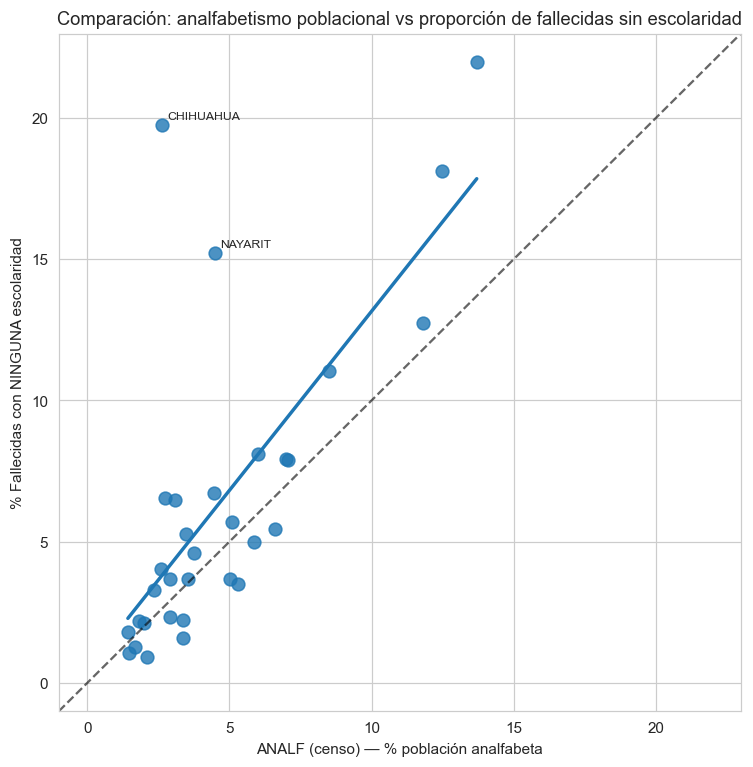

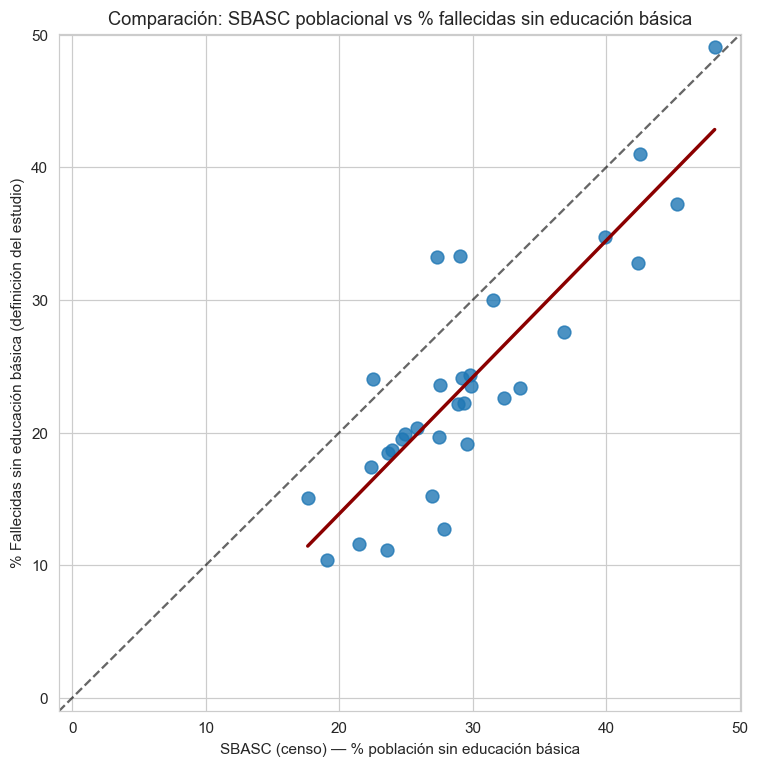

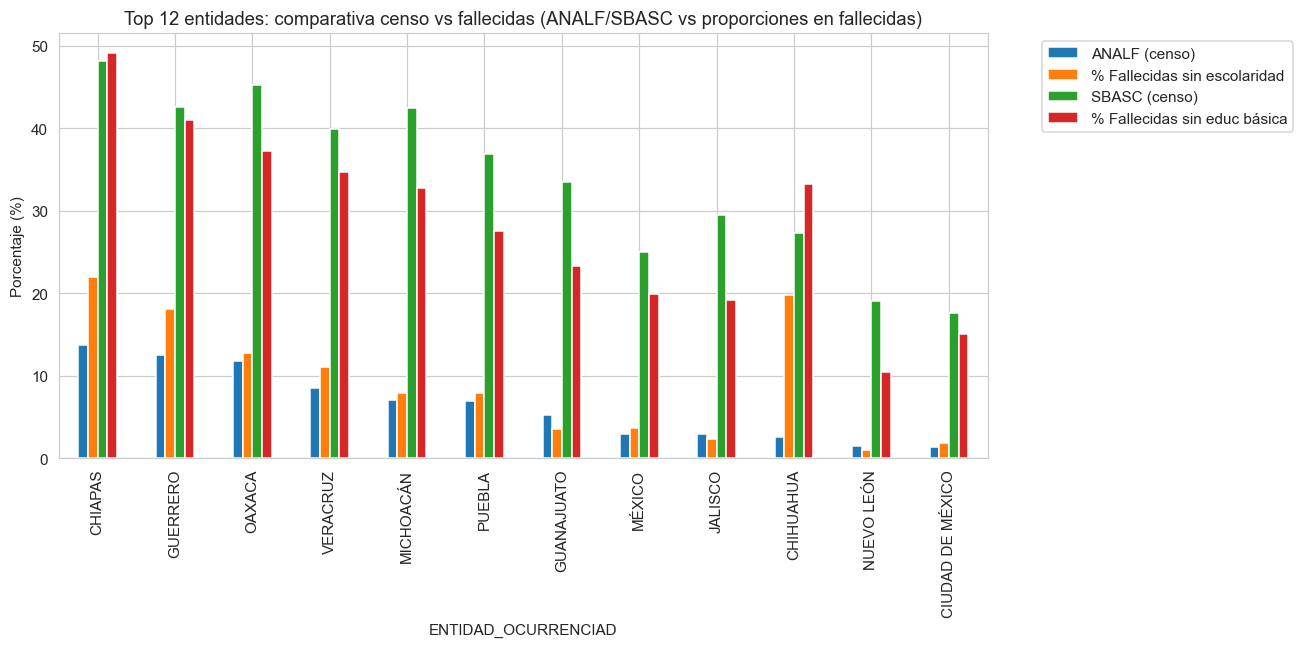

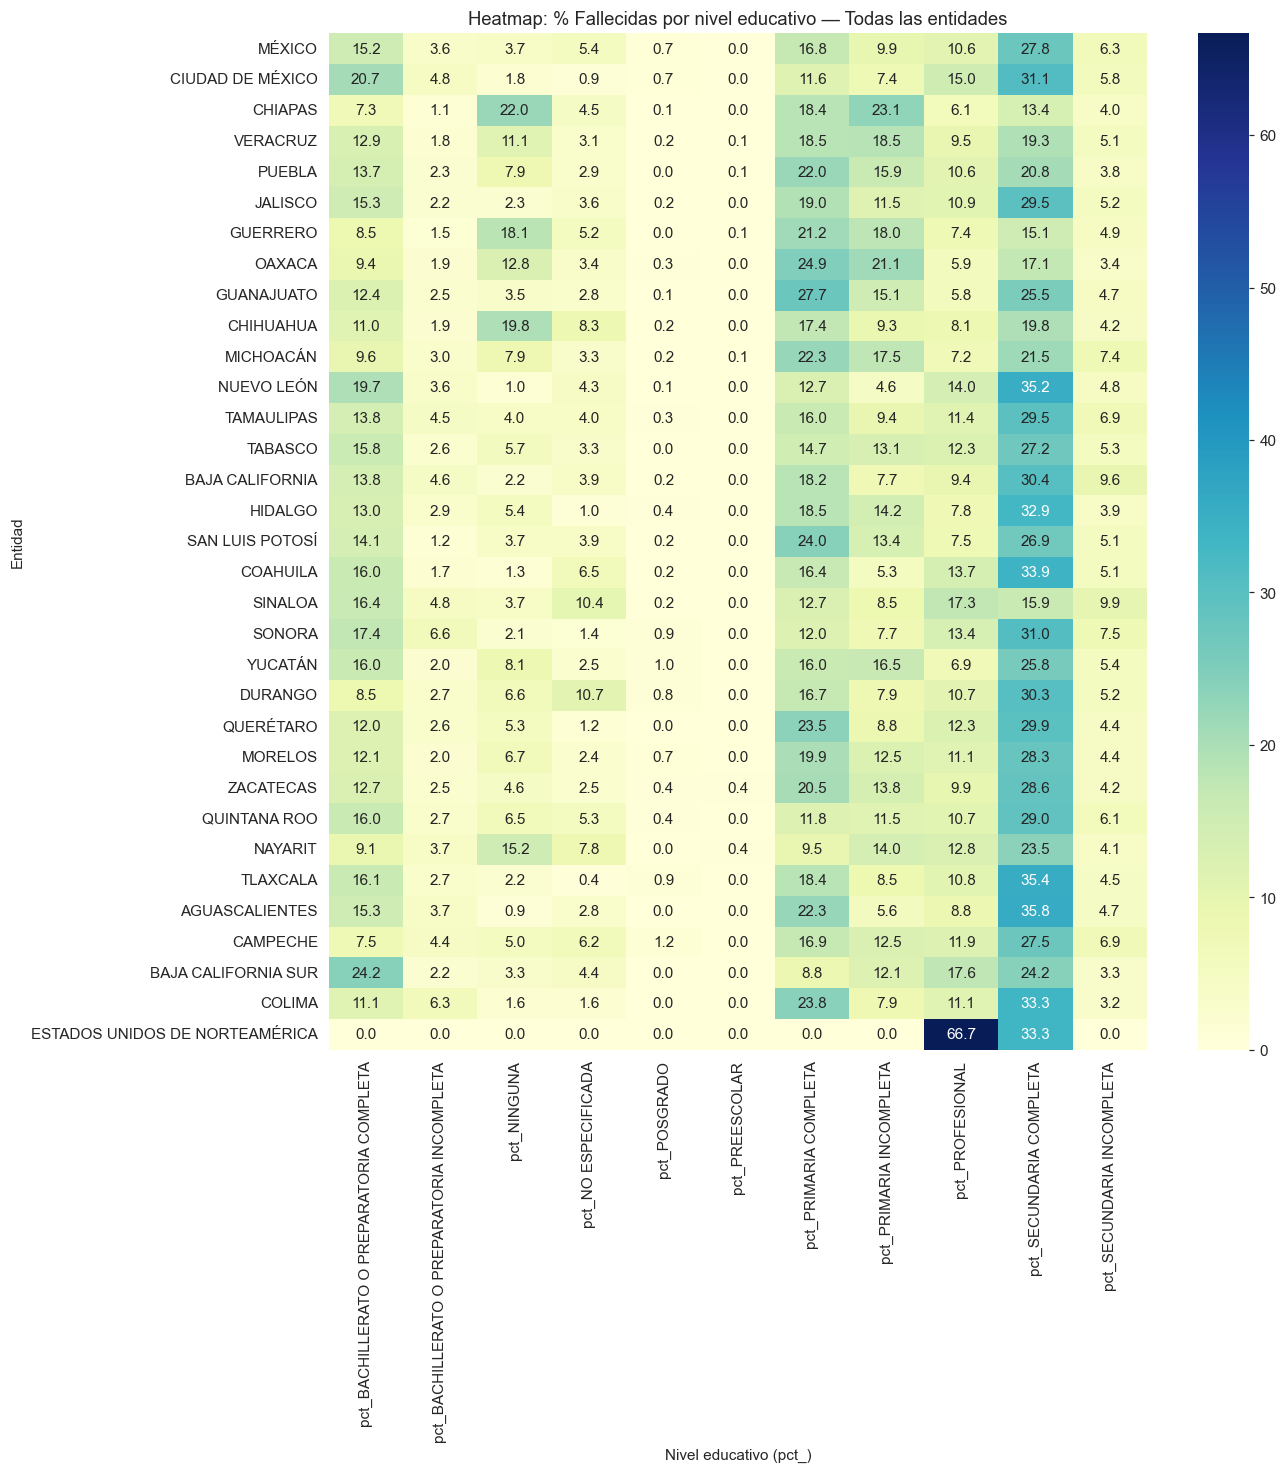

Correlación Pearson ANALF vs % fallecidas sin escolaridad: 0.723
Correlación Pearson SBASC vs % fallecidas sin educ básica: 0.854

Chi2 (Entidad x sin_educ_basica_flag): chi2=1250.0, p=0.0000, dof=32

✅ Análisis completado. Objetos disponibles para inspeccionar: tabla_summary, tabla_desproporcion, pivot_school


In [ ]:
# ============================================================
# Análisis: Cruce ESCOLARIDADD (fallecidas) vs ANALF / SBASC (censo)
# - 1) Distribuciones por entidad (tablas)
# - 2) Cálculo de desproporciones (fallecidas % - censo %)
# - 3) Gráficos: scatter (con línea identidad), barras comparadas y heatmap
# ============================================================

# ---- Ajustes / mapeos (ajusta si quieres otro criterio) ----
# Categorías en ESCOLARIDADD que consideramos "sin educación básica"
no_basic_cats = ["NINGUNA", "PRIMARIA INCOMPLETA", "SECUNDARIA INCOMPLETA"]  
no_school_cat = "NINGUNA"  # categoría que usaremos para comparar con ANALF (analfabetismo)

# ---- 1) Agregar conteos de fallecidas por entidad y escolaridad ----
# Conteo total de fallecidas por entidad
total_by_state = df.groupby("ENTIDAD_OCURRENCIAD", as_index=False).size().rename(columns={"size":"TOTAL_FALLECIDAS"})

# Conteo de fallecidas por entidad y nivel educativo
by_state_school = (
    df.groupby(["ENTIDAD_OCURRENCIAD", "ESCOLARIDADD"], as_index=False)
    .size()
    .rename(columns={"size":"COUNT"})
)

# Pivot: filas = entidad, columnas = nivel educativo, valores = counts
pivot_school = by_state_school.pivot(index="ENTIDAD_OCURRENCIAD", columns="ESCOLARIDADD", values="COUNT").fillna(0)

# Unir totales
pivot_school = pivot_school.merge(total_by_state, left_index=True, right_on="ENTIDAD_OCURRENCIAD", how="left").set_index("ENTIDAD_OCURRENCIAD")

# Calcular porcentajes de fallecidas por nivel educativo (por entidad)
pct_cols = []
for col in pivot_school.columns:
    if col != "TOTAL_FALLECIDAS":
        pct_col = f"pct_{col}"
        pivot_school[pct_col] = (pivot_school[col] / pivot_school["TOTAL_FALLECIDAS"]) * 100
        pct_cols.append(pct_col)

# ---- 2) Construir tabla resumen por entidad con variables del censo (ANALF, SBASC, PO2SM ya en censo) ----
# Tomar del censo solo las columnas necesarias (asegúrate que nombres coinciden)
censo_sel = censo.rename(columns={"ENTIDAD_FEDERATIVA":"ENTIDAD_FEDERATIVA"}).copy()

# Queremos un DF por entidad: ENTIDAD, TOTAL_FALLECIDAS, pct_no_school, pct_no_basic, ANALF, SBASC
summary = pivot_school.reset_index()[["ENTIDAD_OCURRENCIAD", "TOTAL_FALLECIDAS"]].copy()
summary = summary.merge(
    censo_sel[["ENTIDAD_FEDERATIVA", "POBLACION", "ANALF", "SBASC", "PO2SM"]],
    left_on="ENTIDAD_OCURRENCIAD",
    right_on="ENTIDAD_FEDERATIVA",
    how="left"
)

# Añadir % de fallecidas sin escolaridad (NINGUNA) y % de fallecidas sin educación básica (según mapeo)
summary["pct_fallecidas_sin_escolaridad"] = pivot_school.get(f"pct_{no_school_cat}", 0).values
# sumar columnas de pct para no_basic_cats (manejar si categoria no existe)
pct_no_basic_vals = np.zeros(len(summary))
for cat in no_basic_cats:
    colname = f"pct_{cat}"
    if colname in pivot_school.columns:
        pct_no_basic_vals += pivot_school[colname].values
summary["pct_fallecidas_sin_educ_basica"] = pct_no_basic_vals

# Normalizar población si deseas tasa por 100k (opcional)
summary["muertes_por_100k"] = (summary["TOTAL_FALLECIDAS"] / summary["POBLACION"]) * 100000

# ---- 3) Calcular medidas de desproporción (fallecidas % - censo %) ----
# ANALF y SBASC en censo ya están en % (según tu descripción); si fueran proporciones multiplica por 100
# Asegurarse que ANALF y SBASC están numéricos
summary["ANALF"] = pd.to_numeric(summary["ANALF"], errors="coerce")
summary["SBASC"] = pd.to_numeric(summary["SBASC"], errors="coerce")

summary["desprop_analf"] = summary["pct_fallecidas_sin_escolaridad"] - summary["ANALF"]
summary["desprop_sbasc"] = summary["pct_fallecidas_sin_educ_basica"] - summary["SBASC"]

# ---- 4) Tablas para inspección (mostrar en Jupyter) ----
# Tabla 1: resumen ordenado por mayor desproporción analfabetismo
tab1 = summary.sort_values("desprop_analf", ascending=False)[
    ["ENTIDAD_OCURRENCIAD", "TOTAL_FALLECIDAS", "POBLACION", "ANALF", "pct_fallecidas_sin_escolaridad", "desprop_analf", "muertes_por_100k"]
]
print("Tabla 1 — Entidades por desproporción en analfabetismo (fallecidas % - ANALF):")
display(tab1.sort_values("desprop_analf", ascending=False).round(2))

# Tabla 2: resumen ordenado por mayor desproporción SBASC (sin educación básica)
tab2 = summary.sort_values("desprop_sbasc", ascending=False)[
    ["ENTIDAD_OCURRENCIAD", "TOTAL_FALLECIDAS", "POBLACION", "SBASC", "pct_fallecidas_sin_educ_basica", "desprop_sbasc", "muertes_por_100k"]
]
print("Tabla 2 — Entidades por desproporción en SBASC (fallecidas % - SBASC):")
display(tab2.sort_values("desprop_sbasc", ascending=False).round(2))

# ---- 5) Gráficos ----
sns.set_style("whitegrid")

# 5a) Scatter: % fallecidas sin escolaridad vs ANALF (con línea identidad)
plt.figure(figsize=(8,8))
x = summary["ANALF"]
y = summary["pct_fallecidas_sin_escolaridad"]
sns.regplot(x=x, y=y, ci=None, scatter_kws={"s":70, "alpha":0.8})
# línea identidad
lims = [
    np.nanmin([x.min(), y.min()]) - 1,
    np.nanmax([x.max(), y.max()]) + 1,
]
plt.plot(lims, lims, 'k--', alpha=0.6)
plt.xlim(lims)
plt.ylim(lims)
plt.xlabel("ANALF (censo) — % población analfabeta")
plt.ylabel("% Fallecidas con NINGUNA escolaridad")
plt.title("Comparación: analfabetismo poblacional vs proporción de fallecidas sin escolaridad")
for i, row in summary.iterrows():
    if row["desprop_analf"] > 10:  # destacar puntos con gran desproporción
        plt.text(row["ANALF"]+0.2, row["pct_fallecidas_sin_escolaridad"]+0.2, row["ENTIDAD_OCURRENCIAD"], fontsize=8)
plt.show()

# 5b) Scatter: % fallecidas sin educación básica vs SBASC
plt.figure(figsize=(8,8))
x2 = summary["SBASC"]
y2 = summary["pct_fallecidas_sin_educ_basica"]
sns.regplot(x=x2, y=y2, ci=None, scatter_kws={"s":70, "alpha":0.8}, line_kws={"color":"darkred"})
lims2 = [min(x2.min(), y2.min()) - 1, max(x2.max(), y2.max()) + 1]
plt.plot(lims2, lims2, 'k--', alpha=0.6)
plt.xlim(lims2); plt.ylim(lims2)
plt.xlabel("SBASC (censo) — % población sin educación básica")
plt.ylabel("% Fallecidas sin educación básica (definición del estudio)")
plt.title("Comparación: SBASC poblacional vs % fallecidas sin educación básica")
for i, row in summary.iterrows():
    if row["desprop_sbasc"] > 10:
        plt.text(row["SBASC"]+0.2, row["pct_fallecidas_sin_educ_basica"]+0.2, row["ENTIDAD_OCURRENCIAD"], fontsize=8)
plt.show()

# 5c) Barras agrupadas: para las top N entidades por TOTAL_FALLECIDAS (compara censo vs fallecidas)
TOPN = 12
top_states = summary.sort_values("TOTAL_FALLECIDAS", ascending=False).head(TOPN)["ENTIDAD_OCURRENCIAD"].tolist()
df_plot = summary[summary["ENTIDAD_OCURRENCIAD"].isin(top_states)].copy()
df_plot = df_plot.set_index("ENTIDAD_OCURRENCIAD")

# construir DF para barras agrupadas: columnas ANALF, pct_fallecidas_sin_escolaridad, SBASC, pct_fallecidas_sin_educ_basica
bar_df = df_plot[["ANALF", "pct_fallecidas_sin_escolaridad", "SBASC", "pct_fallecidas_sin_educ_basica"]].sort_values("ANALF", ascending=False)

bar_df.plot(kind="bar", figsize=(12,6))
plt.ylabel("Porcentaje (%)")
plt.title(f"Top {TOPN} entidades: comparativa censo vs fallecidas (ANALF/SBASC vs proporciones en fallecidas)")
plt.legend(["ANALF (censo)", "% Fallecidas sin escolaridad", "SBASC (censo)", "% Fallecidas sin educ básica"], bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

# 5d) Heatmap: distribución de escolaridad en fallecidas por entidad (todas las entidades)
heat_df = pivot_school.copy()

# ordenar por total fallecidas ANTES de filtrar columnas
heat_df = heat_df.sort_values("TOTAL_FALLECIDAS", ascending=False)

# seleccionar solo columnas pct_
pct_columns = [c for c in heat_df.columns if c.startswith("pct_")]

plt.figure(figsize=(12,12))
sns.heatmap(heat_df[pct_columns], annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Heatmap: % Fallecidas por nivel educativo — Todas las entidades")
plt.ylabel("Entidad")
plt.xlabel("Nivel educativo (pct_)")
plt.show()


# ---- 6) Estadística: correlaciones y tests rápidos ----
# Correlación Pearson (ANALF vs pct_fallecidas_sin_escolaridad)
pear_analf = summary[["ANALF", "pct_fallecidas_sin_escolaridad"]].dropna().corr().iloc[0,1]
pear_sbasc = summary[["SBASC", "pct_fallecidas_sin_educ_basica"]].dropna().corr().iloc[0,1]

print(f"Correlación Pearson ANALF vs % fallecidas sin escolaridad: {pear_analf:.3f}")
print(f"Correlación Pearson SBASC vs % fallecidas sin educ básica: {pear_sbasc:.3f}")

# Opcional: prueba de independencia Chi2 entre entidad y categoría 'SIN_EDUCACION_BASICA' (tablas grandes)
# Construir tabla de contingencia simple: entidad x indicador binario (sin_educ_basica)
df_bin = df.copy()
df_bin["sin_educ_basica_flag"] = df_bin["ESCOLARIDADD"].isin(no_basic_cats).astype(int)
ct = pd.crosstab(df_bin["ENTIDAD_OCURRENCIAD"], df_bin["sin_educ_basica_flag"])
chi2, pval, dof, expected = chi2_contingency(ct)
print(f"\nChi2 (Entidad x sin_educ_basica_flag): chi2={chi2:.1f}, p={pval:.4f}, dof={dof}")

# ---- 7) Guardar tablas de resumen en variables para uso posterior ----
tabla_summary = summary.copy()
tabla_desproporcion = summary[["ENTIDAD_OCURRENCIAD","TOTAL_FALLECIDAS","POBLACION","ANALF","pct_fallecidas_sin_escolaridad","desprop_analf","SBASC","pct_fallecidas_sin_educ_basica","desprop_sbasc","muertes_por_100k"]]

print("\n✅ Análisis completado. Objetos disponibles para inspeccionar: tabla_summary, tabla_desproporcion, pivot_school")


**Cruce entre RAZON_MORTALIDAD_MATERNAD y CAUSA_CIE_4D**

In [ ]:
# ============================================================
# CRUCE ENTRE RAZON_MORTALIDAD_MATERNAD Y CAUSA_CIE_4D
# ============================================================

# 1. Tabla cruzada (frecuencias absolutas)
tabla_cruce = pd.crosstab(
    df['CAUSA_CIE_4D'],
    df['RAZON_MORTALIDAD_MATERNAD']
).sort_values(by='MUERTES MATERNAS PARA LA RAZÓN DE MORTALIDAD MATERNA', ascending=False)

print("=== TABLA CRUZADA: CAUSA CIE-10 × RAZÓN DE MORTALIDAD MATERNA ===")
display(tabla_cruce)


# 2. Calcular totales y proporciones
tabla_cruce_prop = tabla_cruce.div(tabla_cruce.sum(axis=1), axis=0) * 100
tabla_cruce_prop = tabla_cruce_prop.round(2)

print("\n=== PROPORCIONES POR CAUSA CIE-10 (%) ===")
display(tabla_cruce_prop)


# 3. Gráfico: distribución de causas según tipo de muerte materna
#plt.figure(figsize=(12, 10))
#tabla_cruce.plot(kind='bar', stacked=True, figsize=(14, 8))
#plt.title("Distribución de CAUSA_CIE_4D por categoría de RAZON_MORTALIDAD_MATERNA")
#plt.xlabel("Causa CIE-10")
#plt.ylabel("Número de casos")
#plt.xticks(rotation=90)
#plt.legend(title="Categoría")
#plt.tight_layout()
#plt.show()


# 4. Gráfico de proporciones (%)
#plt.figure(figsize=(12, 10))
#tabla_cruce_prop.plot(kind='bar', stacked=True, figsize=(14, 8))
#plt.title("Proporción (%) de cada CAUSA_CIE_4D según RMM Incluida vs Excluida")
#plt.xlabel("Causa CIE-10")
#plt.ylabel("Porcentaje (%)")
#plt.xticks(rotation=90)
#plt.legend(title="Categoría")
#plt.tight_layout()
#plt.show()


# 5. Resumen automático
incluidas_total = tabla_cruce["MUERTES MATERNAS PARA LA RAZÓN DE MORTALIDAD MATERNA"].sum()
excluidas_total = tabla_cruce["MUERTES MATERNAS EXCLUIDAS PARA LA RAZÓN DE MORTALIDAD MATERNA"].sum()

print("\n=== RESUMEN AUTOMÁTICO ===")
print(f"Total muertes incluidas para RMM: {incluidas_total}")
print(f"Total muertes excluidas: {excluidas_total}")

porc_excluidas = round(excluidas_total / (incluidas_total + excluidas_total) * 100, 2)
print(f"\nPorcentaje de causas que corresponden a muertes excluidas: {porc_excluidas}%")

if porc_excluidas < 5:
    print("\nInterpretación: Las causas CIE-10 corresponden casi totalmente a muertes maternas incluidas en la RMM. "
          "Las excluidas son mínimas y no afectan la interpretación.")
else:
    print("\nInterpretación: Hay una proporción considerable de causas que pertenecen a muertes excluidas. "
          "Es necesario depurar las causas si se desea comparar con cifras oficiales de la RMM.")


=== TABLA CRUZADA: CAUSA CIE-10 × RAZÓN DE MORTALIDAD MATERNA ===


RAZON_MORTALIDAD_MATERNAD,MUERTES MATERNAS EXCLUIDAS PARA LA RAZÓN DE MORTALIDAD MATERNA,MUERTES MATERNAS PARA LA RAZÓN DE MORTALIDAD MATERNA
CAUSA_CIE_4D,,
O150 ECLAMPSIA EN EL EMBARAZO,6,1810
O141 PREECLAMPSIA SEVERA,3,1497
O721 OTRAS HEMORRAGIAS POSTPARTO INMEDIATAS,7,1461
"O998 OTRAS ENFERMEDADES ESPECIFICADAS Y AFECCIONES QUE COMPLICAN EL EMBARAZO, EL PARTO Y EL PUERPERIO",4,1307
O720 HEMORRAGIA DEL TERCER PERÍODO DEL PARTO,2,1245
...,...,...
O960 MUERTE POR CAUSA OBSTÉTRICA DIRECTA QUE OCURRE DESPUÉS DE 42 DÍAS PERO ANTES DE UN AÑO DEL PARTO,346,0
O970 MUERTE POR SECUELAS DE CAUSA OBSTÉTRICA DIRECTA,315,0
O96X MUERTE MATERNA DEBIDA A CUALQUIER CAUSA OBSTÉTRICA QUE OCURRE DESPUÉS DE 42 DÍAS PERO ANTES DE UN AÑO DEL PARTO,415,0



=== PROPORCIONES POR CAUSA CIE-10 (%) ===


RAZON_MORTALIDAD_MATERNAD,MUERTES MATERNAS EXCLUIDAS PARA LA RAZÓN DE MORTALIDAD MATERNA,MUERTES MATERNAS PARA LA RAZÓN DE MORTALIDAD MATERNA
CAUSA_CIE_4D,,
O150 ECLAMPSIA EN EL EMBARAZO,0.33,99.67
O141 PREECLAMPSIA SEVERA,0.20,99.80
O721 OTRAS HEMORRAGIAS POSTPARTO INMEDIATAS,0.48,99.52
"O998 OTRAS ENFERMEDADES ESPECIFICADAS Y AFECCIONES QUE COMPLICAN EL EMBARAZO, EL PARTO Y EL PUERPERIO",0.31,99.69
O720 HEMORRAGIA DEL TERCER PERÍODO DEL PARTO,0.16,99.84
...,...,...
O960 MUERTE POR CAUSA OBSTÉTRICA DIRECTA QUE OCURRE DESPUÉS DE 42 DÍAS PERO ANTES DE UN AÑO DEL PARTO,100.00,0.00
O970 MUERTE POR SECUELAS DE CAUSA OBSTÉTRICA DIRECTA,100.00,0.00
O96X MUERTE MATERNA DEBIDA A CUALQUIER CAUSA OBSTÉTRICA QUE OCURRE DESPUÉS DE 42 DÍAS PERO ANTES DE UN AÑO DEL PARTO,100.00,0.00



=== RESUMEN AUTOMÁTICO ===
Total muertes incluidas para RMM: 20902
Total muertes excluidas: 2376

Porcentaje de causas que corresponden a muertes excluidas: 10.21%

Interpretación: Hay una proporción considerable de causas que pertenecen a muertes excluidas. Es necesario depurar las causas si se desea comparar con cifras oficiales de la RMM.


**ANÁLISIS CRUZADO: ESTADO CONYUGAL**


===== TABLA NACIONAL DE ESTADO CONYUGAL =====



,Estado Conyugal,Muertes
0,CASADO,9582
1,UNION LIBRE,8986
2,SOLTERO,3581
3,SE IGNORA,651
4,VIUDO,175
5,DIVORCIADO,152
6,SEPARADO,150
7,NO APLICA A MENORES DE 12 AÑOS,1



===== TABLA POR ESTADO CON VARIABLES PROPORCIONALES =====



,CASADO,DIVORCIADO,NO APLICA A MENORES DE 12 AÑOS,SE IGNORA,SEPARADO,SOLTERO,UNION LIBRE,VIUDO,MATRIMONIOS,DIVORCIOS,CASADO_POR_MATRIMONIOS,CASADO_POR_DIVORCIOS,DIVORCIADO_POR_MATRIMONIOS,DIVORCIADO_POR_DIVORCIOS,NO APLICA A MENORES DE 12 AÑOS_POR_MATRIMONIOS,NO APLICA A MENORES DE 12 AÑOS_POR_DIVORCIOS,SE IGNORA_POR_MATRIMONIOS,SE IGNORA_POR_DIVORCIOS,SEPARADO_POR_MATRIMONIOS,SEPARADO_POR_DIVORCIOS,SOLTERO_POR_MATRIMONIOS,SOLTERO_POR_DIVORCIOS,UNION LIBRE_POR_MATRIMONIOS,UNION LIBRE_POR_DIVORCIOS,VIUDO_POR_MATRIMONIOS,VIUDO_POR_DIVORCIOS
ENTIDAD_FEDERATIVA,,,,,,,,,,,,,,,,,,,,,,,,,,
AGUASCALIENTES,112.00,1.00,0.00,1.00,2.00,41.00,55.00,3.00,"4,789.00","2,953.00",0.02,0.04,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.01,0.01,0.02,0.00,0.00
BAJA CALIFORNIA,174.00,4.00,0.00,8.00,1.00,187.00,167.00,2.00,"11,249.00","1,587.00",0.02,0.11,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.02,0.12,0.01,0.11,0.00,0.00
BAJA CALIFORNIA SUR,43.00,0.00,0.00,0.00,0.00,7.00,41.00,0.00,"1,614.00",770.00,0.03,0.06,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.03,0.05,0.00,0.00
CAMPECHE,75.00,1.00,0.00,7.00,2.00,18.00,56.00,1.00,"2,983.00","1,529.00",0.03,0.05,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.01,0.02,0.04,0.00,0.00
CHIAPAS,447.00,9.00,1.00,50.00,6.00,192.00,854.00,10.00,"16,536.00","1,186.00",0.03,0.38,0.00,0.01,0.00,0.00,0.00,0.04,0.00,0.01,0.01,0.16,0.05,0.72,0.00,0.01
CHIHUAHUA,269.00,14.00,0.00,62.00,4.00,148.00,388.00,11.00,"10,828.00","5,027.00",0.02,0.05,0.00,0.00,0.00,0.00,0.01,0.01,0.00,0.00,0.01,0.03,0.04,0.08,0.00,0.00
CIUDAD DE MÉXICO,883.00,11.00,0.00,23.00,24.00,465.00,975.00,12.00,"11,938.00","5,134.00",0.07,0.17,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.04,0.09,0.08,0.19,0.00,0.00
COAHUILA,239.00,3.00,0.00,26.00,3.00,54.00,144.00,6.00,"11,817.00","6,230.00",0.02,0.04,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.01,0.02,0.00,0.00
COLIMA,21.00,0.00,0.00,1.00,0.00,16.00,25.00,0.00,"2,508.00",739.00,0.01,0.03,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.02,0.01,0.03,0.00,0.00


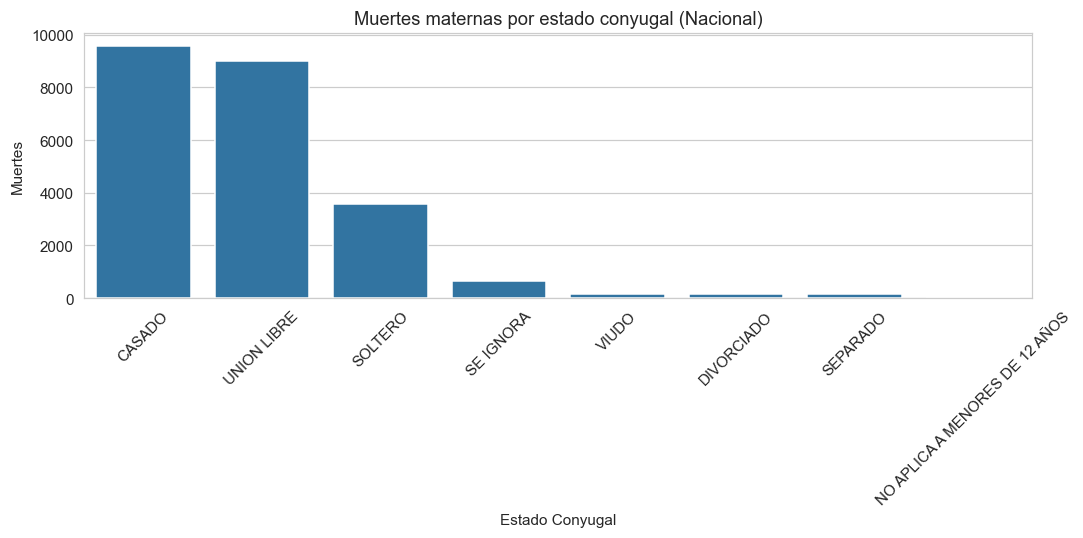

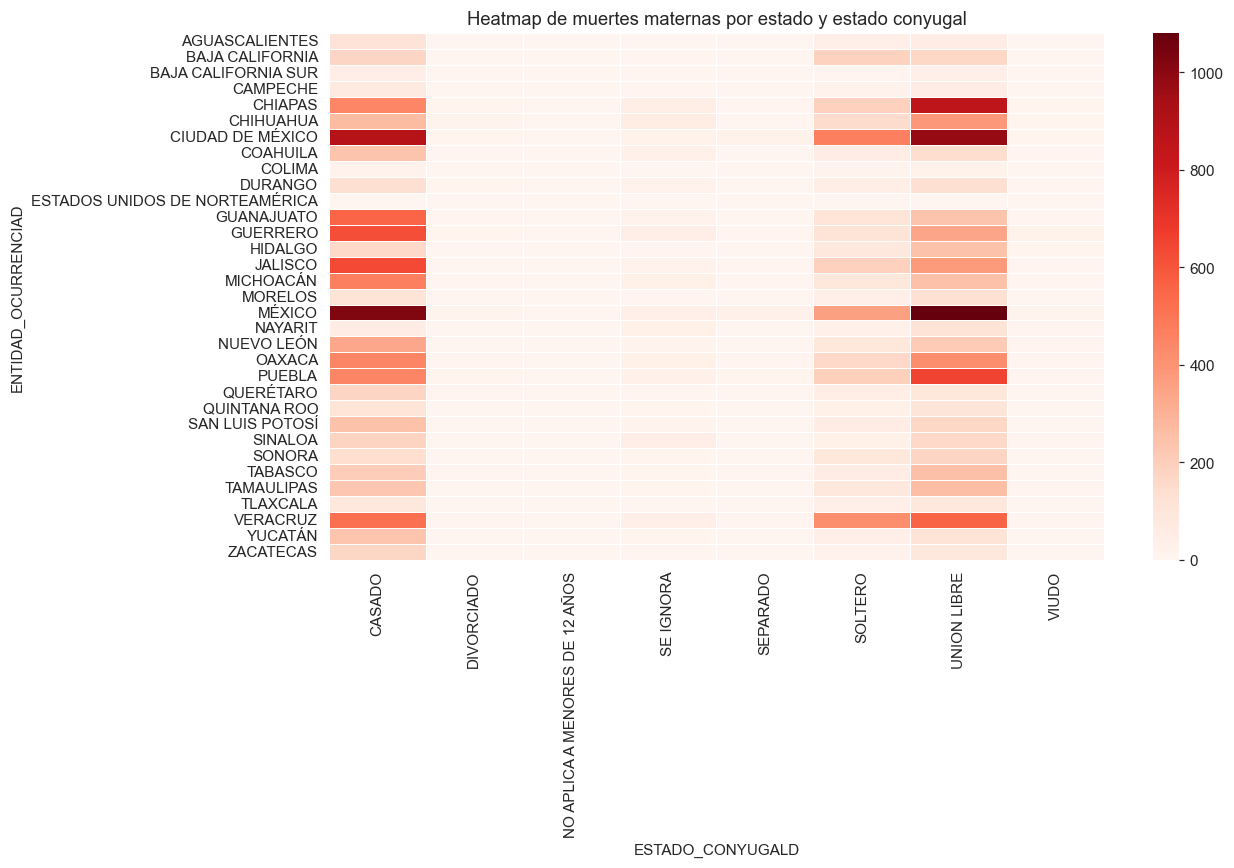

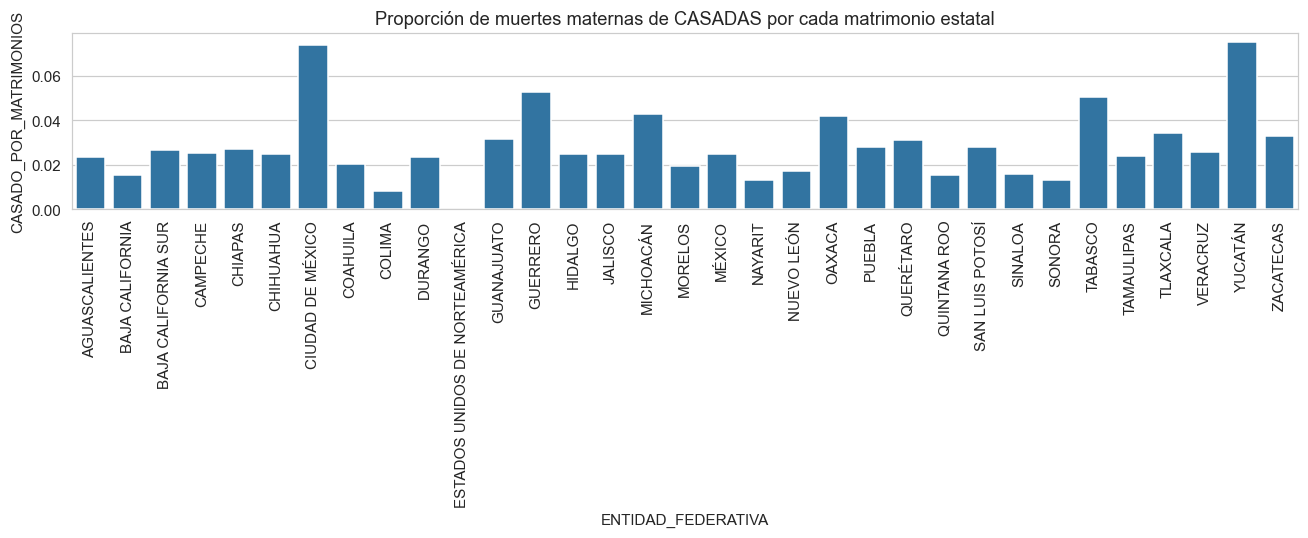

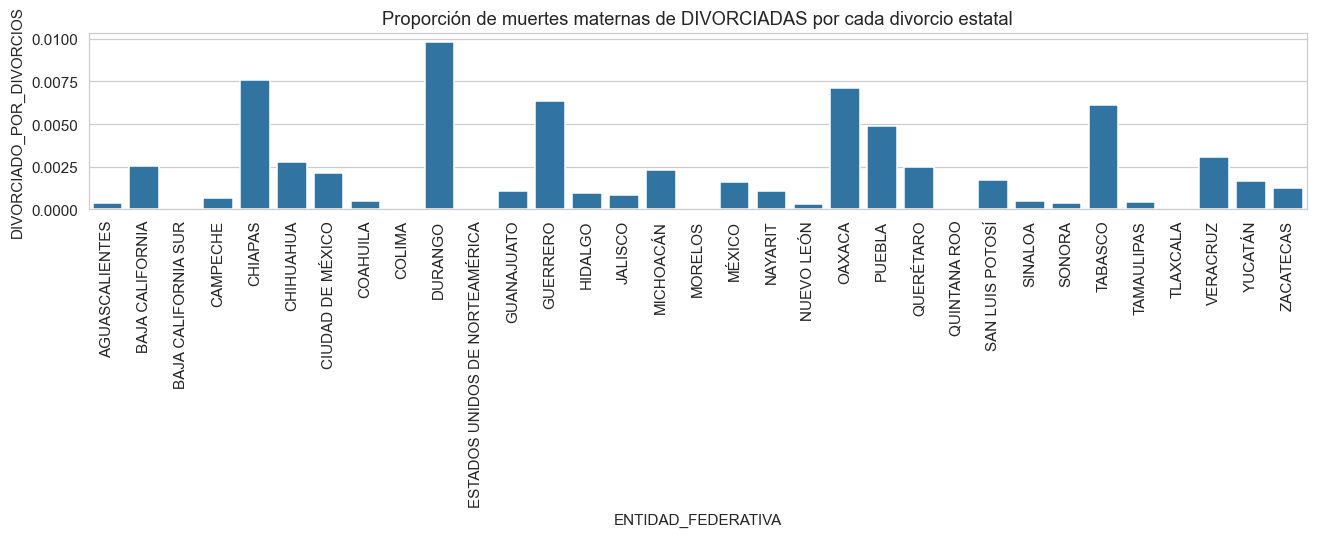

In [ ]:
# 1. Preprocesamiento: normalizar nombres de estados
df['ENTIDAD_OCURRENCIAD'] = df['ENTIDAD_OCURRENCIAD'].str.upper().str.strip()
censo['ENTIDAD_FEDERATIVA'] = censo['ENTIDAD_FEDERATIVA'].str.upper().str.strip()

# 2. Agrupar muertes maternas por estado y estado conyugal
tabla_ec = (
    df.groupby(['ENTIDAD_OCURRENCIAD','ESTADO_CONYUGALD'])
      .size()
      .reset_index(name='MUERTES')
)

# 3. Pivotear para obtener tabla por estado
tabla_ec_pivot = tabla_ec.pivot_table(
    index='ENTIDAD_OCURRENCIAD',
    columns='ESTADO_CONYUGALD',
    values='MUERTES',
    fill_value=0
)

# 4. Seleccionar variables INEGI relevantes
censo_sub = censo[['ENTIDAD_FEDERATIVA','MATRIMONIOS','DIVORCIOS']].copy()

# 5. Unir bases por entidad
merge_ec = tabla_ec_pivot.merge(
    censo_sub,
    left_index=True,
    right_on='ENTIDAD_FEDERATIVA',
    how='left'
).set_index('ENTIDAD_FEDERATIVA')

# 6. Normalización proporcional
#    Muertes / Matrimonios y Muertes / Divorcios
for col in tabla_ec_pivot.columns:
    merge_ec[f'{col}_POR_MATRIMONIOS'] = merge_ec[col] / merge_ec['MATRIMONIOS']
    merge_ec[f'{col}_POR_DIVORCIOS'] = merge_ec[col] / merge_ec['DIVORCIOS']

# ============================================================
#  TABLAS RESUMEN A NIVEL NACIONAL
# ============================================================

# Tabla nacional: muertes por estado conyugal
tabla_nacional = df['ESTADO_CONYUGALD'].value_counts().rename_axis("Estado Conyugal").reset_index(name="Muertes")

print("\n===== TABLA NACIONAL DE ESTADO CONYUGAL =====\n")
display(tabla_nacional)

# Tabla estatal con proporciones
print("\n===== TABLA POR ESTADO CON VARIABLES PROPORCIONALES =====\n")
display(merge_ec)

# ============================================================
#  GRÁFICOS
# ============================================================

# ---------- 1. Gráfico nacional ----------
plt.figure(figsize=(10,5))
sns.barplot(data=tabla_nacional, x="Estado Conyugal", y="Muertes")
plt.xticks(rotation=45)
plt.title("Muertes maternas por estado conyugal (Nacional)")
plt.tight_layout()
plt.show()

# ---------- 2. Heatmap de muertes por estado ----------
plt.figure(figsize=(12,8))
sns.heatmap(tabla_ec_pivot, cmap="Reds", linewidths=.5)
plt.title("Heatmap de muertes maternas por estado y estado conyugal")
plt.tight_layout()
plt.show()

# ---------- 3. Proporción CASADO vs MATRIMONIOS ----------
plt.figure(figsize=(12,5))
sns.barplot(
    x=merge_ec.index,
    y=merge_ec['CASADO_POR_MATRIMONIOS']
)
plt.xticks(rotation=90)
plt.title("Proporción de muertes maternas de CASADAS por cada matrimonio estatal")
plt.tight_layout()
plt.show()

# ---------- 4. Proporción DIVORCIADO vs DIVORCIOS ----------
if 'DIVORCIADO_POR_DIVORCIOS' in merge_ec:
    plt.figure(figsize=(12,5))
    sns.barplot(
        x=merge_ec.index,
        y=merge_ec['DIVORCIADO_POR_DIVORCIOS']
    )
    plt.xticks(rotation=90)
    plt.title("Proporción de muertes maternas de DIVORCIADAS por cada divorcio estatal")
    plt.tight_layout()
    plt.show()


**Cruce de derechohabiencia INEGI vs. mortalidad materna**


=== FRECUENCIAS NACIONALES DE DERECHOHABIENCIA (MM) ===



,DERECHOHABIENCIAD,Frecuencia absoluta,Frecuencia relativa (%)
0,NINGUNA,8258,35.48
1,SEGURO POPULAR,6535,28.07
2,IMSS,4718,20.27
3,NO ESPECIFICADA,2256,9.69
4,ISSSTE,678,2.91
5,OTRA,431,1.85
6,IMSS OPORTUNIDADES,109,0.47
7,SECRETARIA DE LA DEFENSA NACIONAL,105,0.45
8,SECRETARIA DE MARINA,92,0.40
9,IMSS PROSPERA,48,0.21



=== DERECHOHABIENCIA SEGÚN INEGI 2020 ===



,ENTIDAD_FEDERATIVA,PDSS,PPDSP,PPD_PEMEX_SDN_SM,PPSMP,PPD_ISSSTE,PPD_IMSS
0,AGUASCALIENTES,1161139,23.40,0.30,2.70,8.30,67.20
1,BAJA CALIFORNIA,2905265,17.80,0.50,4.50,8.10,68.70
2,BAJA CALIFORNIA SUR,664122,21.00,1.60,1.90,15.70,61.60
3,CAMPECHE,719677,45.50,4.50,1.00,9.00,40.00
4,CHIAPAS,3698663,68.60,1.00,0.90,7.00,18.20
5,CHIHUAHUA,3156294,21.80,0.30,4.00,6.30,64.70
6,CIUDAD DE MÉXICO,6689012,18.00,1.60,6.60,17.00,58.00
7,COAHUILA,2540708,7.20,0.30,3.30,7.90,82.10
8,COLIMA,605947,29.70,1.80,1.50,8.30,59.80
9,DURANGO,1366665,29.60,0.60,1.20,14.10,54.50



=== TABLA DE MUERTES MATERNAS POR DERECHOHABIENCIA Y ESTADO ===



DERECHOHABIENCIAD,IMSS,IMSS OPORTUNIDADES,IMSS PROSPERA,ISSFAM,ISSSTE,NINGUNA,NO ESPECIFICADA,OTRA,PEMEX,SECRETARIA DE LA DEFENSA NACIONAL,SECRETARIA DE MARINA,SEGURO POPULAR
ENTIDAD_OCURRENCIAD,,,,,,,,,,,,
AGUASCALIENTES,88,0,0,0,9,39,16,0,0,0,0,63
BAJA CALIFORNIA,190,1,1,0,12,140,36,7,1,1,2,152
BAJA CALIFORNIA SUR,41,0,0,0,7,17,1,0,0,0,0,25
CAMPECHE,23,1,1,0,3,50,11,2,0,1,0,68
CHIAPAS,76,22,10,0,18,645,269,25,0,6,8,490
CHIHUAHUA,204,0,2,0,17,243,161,30,1,2,2,234
CIUDAD DE MÉXICO,604,1,1,1,172,1039,108,58,14,47,19,329
COAHUILA,240,3,4,0,7,75,54,9,1,1,1,80
COLIMA,19,0,0,0,1,21,2,2,0,0,3,15



=== CRUCE PROPORCIONAL (MUERTES / PORCENTAJE INEGI) ===



,SEGURO POPULAR_ratio,IMSS_ratio,ISSSTE_ratio,SECRETARIA DE LA DEFENSA NACIONAL_ratio,SECRETARIA DE MARINA_ratio,OTRA_ratio,NINGUNA_ratio
AGUASCALIENTES,269.23,130.95,108.43,0.00,0.00,0.00,0.00
BAJA CALIFORNIA,853.93,276.56,148.15,200.00,400.00,155.56,0.00
BAJA CALIFORNIA SUR,119.05,66.56,44.59,0.00,0.00,0.00,0.00
CAMPECHE,149.45,57.50,33.33,22.22,0.00,200.00,0.00
CHIAPAS,714.29,417.58,257.14,600.00,800.00,"2,777.78",0.00
CHIHUAHUA,"1,073.39",315.30,269.84,666.67,666.67,750.00,0.00
CIUDAD DE MÉXICO,"1,827.78","1,041.38","1,011.76","2,937.50","1,187.50",878.79,0.00
COAHUILA,"1,111.11",292.33,88.61,333.33,333.33,272.73,0.00
COLIMA,50.51,31.77,12.05,0.00,166.67,133.33,0.00
DURANGO,358.11,119.27,156.03,333.33,0.00,333.33,0.00


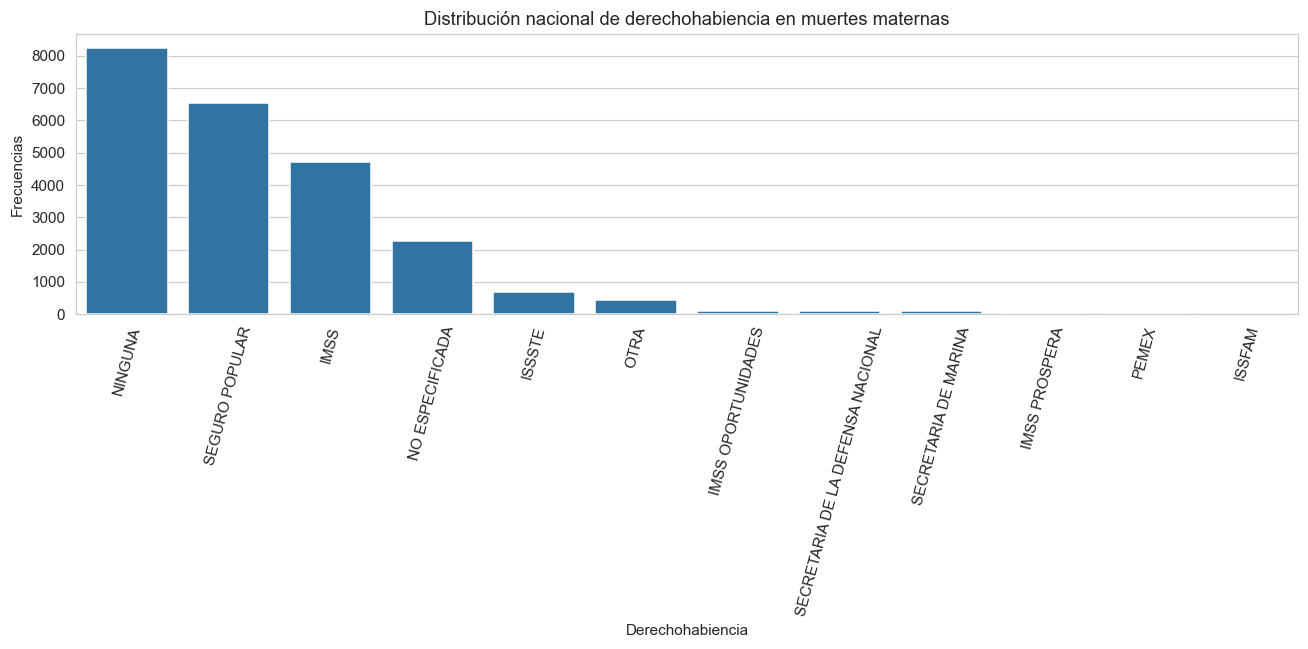

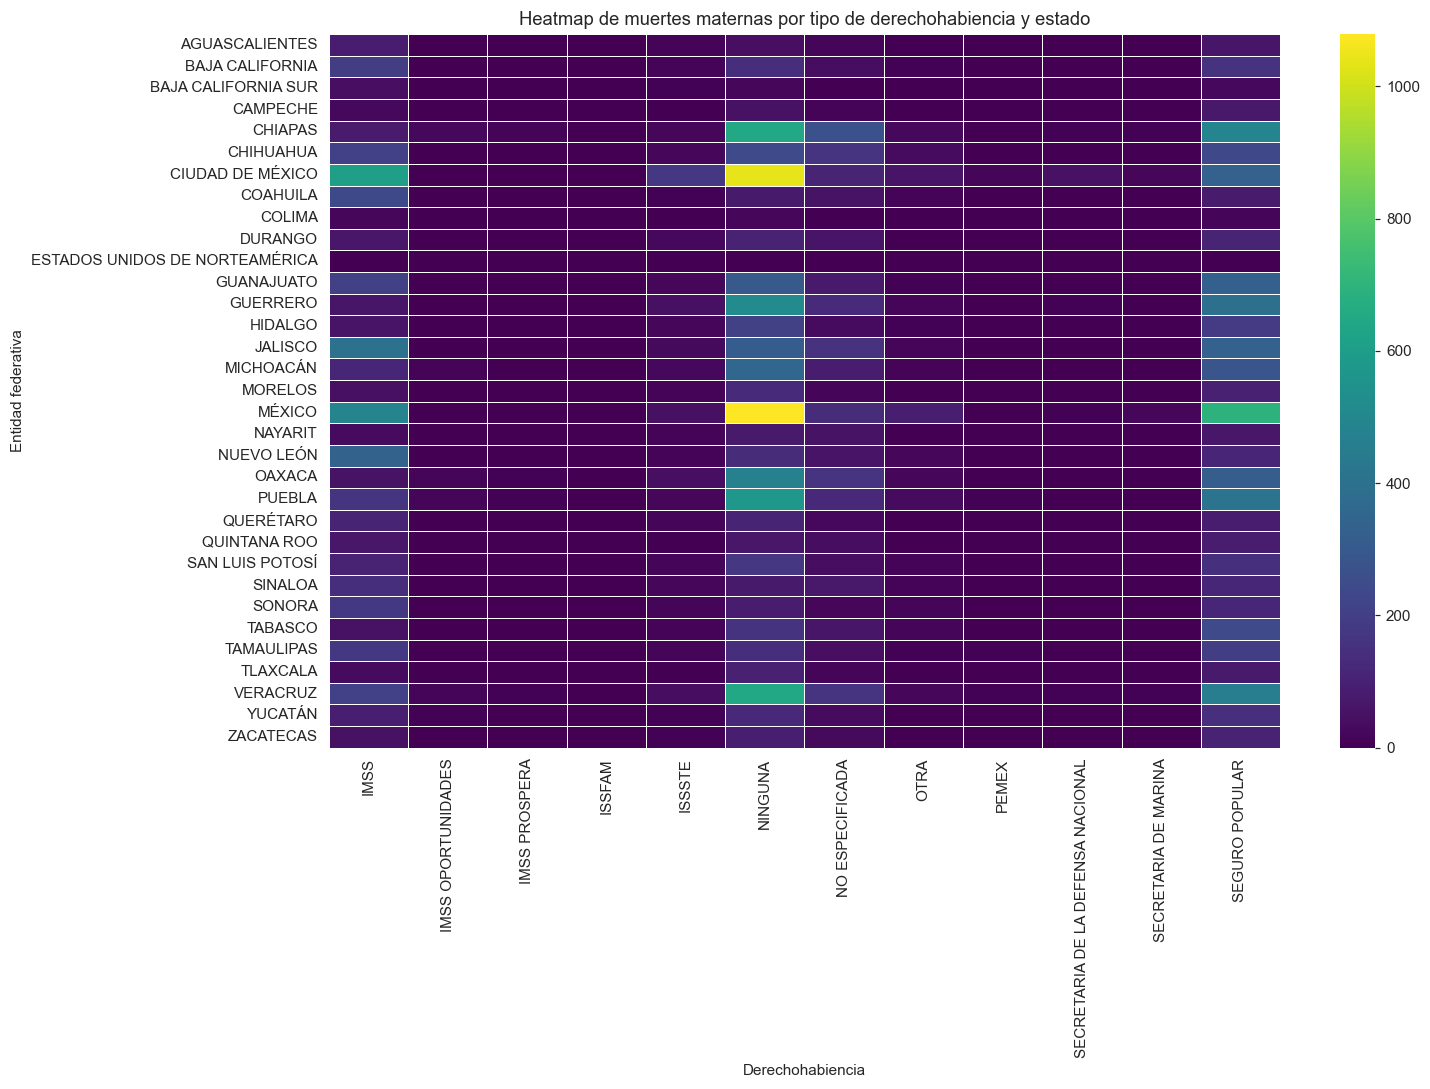

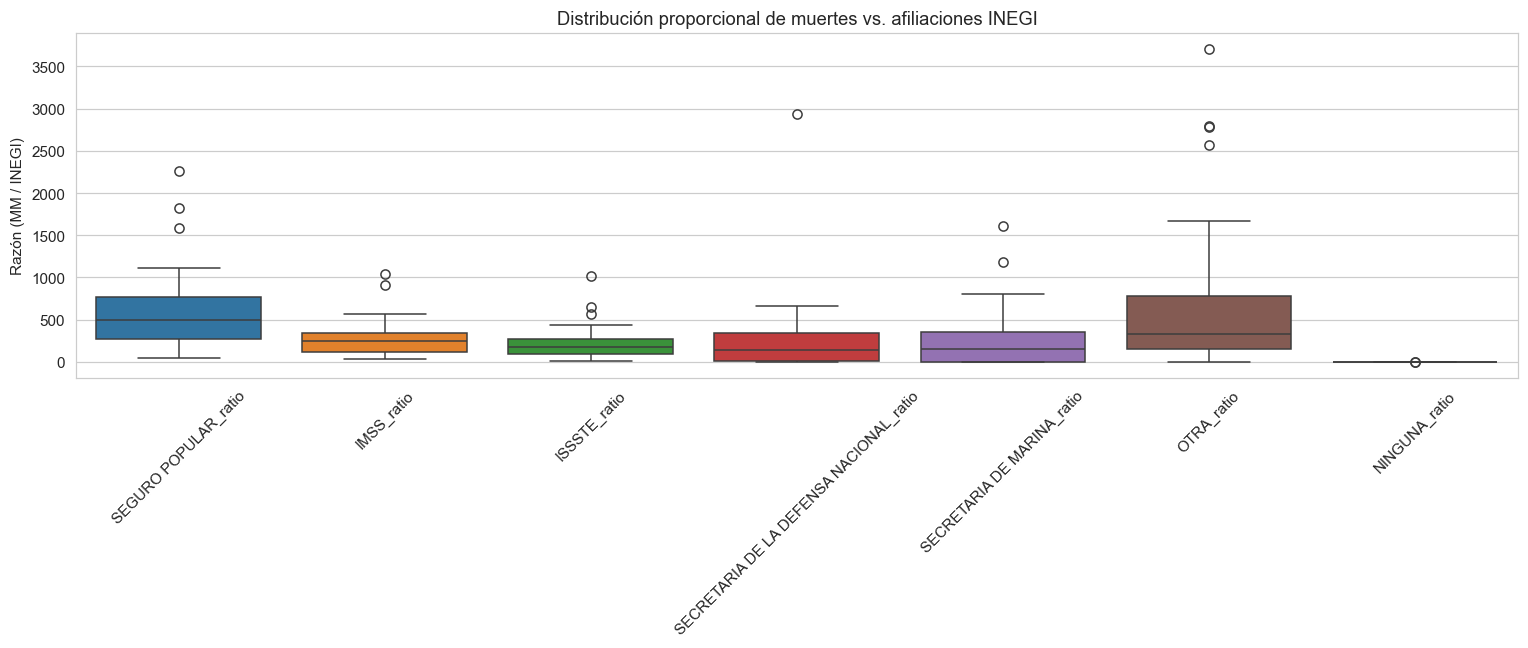


=== TABLA FINAL RESUMIDA POR TIPO DE DERECHOHABIENCIA ===



,Total muertes,Promedio proporciones INEGI
IMSS,"4,718.00",NaN
IMSS OPORTUNIDADES,109.00,NaN
IMSS PROSPERA,48.00,NaN
ISSFAM,2.00,NaN
ISSSTE,678.00,NaN
NINGUNA,"8,257.00",NaN
NO ESPECIFICADA,"2,254.00",NaN
OTRA,431.00,NaN
PEMEX,46.00,NaN
SECRETARIA DE LA DEFENSA NACIONAL,105.00,NaN


In [ ]:
# ------------------------------------------------------------
# 1. TABLA DE FRECUENCIAS NACIONAL DE DERECHOHABIENCIA (MM)
# ------------------------------------------------------------
freq_mm = (
    df['DERECHOHABIENCIAD']
    .value_counts(dropna=False)
    .reset_index()
)

freq_mm.columns = ['DERECHOHABIENCIAD', 'Frecuencia absoluta']
freq_mm['Frecuencia relativa (%)'] = round(
    100 * freq_mm['Frecuencia absoluta'] / freq_mm['Frecuencia absoluta'].sum(),
    2
)

print("\n=== FRECUENCIAS NACIONALES DE DERECHOHABIENCIA (MM) ===\n")
display(freq_mm)


# ------------------------------------------------------------
# 2. RESUMEN DE DERECHOHABIENCIA EN INEGI (CENSO)
# ------------------------------------------------------------
cols_dh_inegi = [
    'ENTIDAD_FEDERATIVA', 'PDSS', 'PPDSP', 'PPD_PEMEX_SDN_SM',
    'PPSMP', 'PPD_ISSSTE', 'PPD_IMSS'
]

inegi_dh = censo[cols_dh_inegi].copy()

print("\n=== DERECHOHABIENCIA SEGÚN INEGI 2020 ===\n")
display(inegi_dh)


# ------------------------------------------------------------
# 3. AGRUPAR MUERTES MATERNAS POR TIPO DE DERECHOHABIENCIA Y ESTADO
# ------------------------------------------------------------
df_group_state = (
    df.groupby(['ENTIDAD_OCURRENCIAD', 'DERECHOHABIENCIAD'])
    .size()
    .unstack(fill_value=0)
)

print("\n=== TABLA DE MUERTES MATERNAS POR DERECHOHABIENCIA Y ESTADO ===\n")
display(df_group_state)


# ------------------------------------------------------------
# 4. CRUCE PROPORCIONAL: MUERTES vs PORCENTAJES INEGI
# ------------------------------------------------------------
# Normalizamos los porcentajes al rango [0,1]
inegi_prop = inegi_dh.set_index('ENTIDAD_FEDERATIVA').copy()
inegi_prop['PPDSP'] /= 100
inegi_prop['PPD_PEMEX_SDN_SM'] /= 100
inegi_prop['PPSMP'] /= 100
inegi_prop['PPD_ISSSTE'] /= 100
inegi_prop['PPD_IMSS'] /= 100

# Estandarizamos nombres para mapear
mm_state = df_group_state.copy()
mm_state.index = mm_state.index.str.upper()
inegi_prop.index = inegi_prop.index.str.upper()

# Intersección de estados
common_states = mm_state.index.intersection(inegi_prop.index)

mm_state = mm_state.loc[common_states]
inegi_prop = inegi_prop.loc[common_states]

# Crear tabla proporcional
proportional_df = pd.DataFrame(index=common_states)

mapping = {
    'SEGURO POPULAR': 'PPDSP',
    'IMSS': 'PPD_IMSS',
    'ISSSTE': 'PPD_ISSSTE',
    'SECRETARIA DE LA DEFENSA NACIONAL': 'PPD_PEMEX_SDN_SM',
    'SECRETARIA DE MARINA': 'PPD_PEMEX_SDN_SM',
    'OTRA': 'PPSMP',
    'NINGUNA': 'PDSS',   # Ninguna se compara con población total derechohabiente
}

for mm_cat, inegi_var in mapping.items():
    if mm_cat in mm_state.columns and inegi_var in inegi_prop.columns:
        proportional_df[f'{mm_cat}_ratio'] = (
            mm_state[mm_cat] / (inegi_prop[inegi_var].replace(0, np.nan))
        )

print("\n=== CRUCE PROPORCIONAL (MUERTES / PORCENTAJE INEGI) ===\n")
display(proportional_df)


# ------------------------------------------------------------
# 5. GRAFICO: FRECUENCIAS NACIONALES (MM)
# ------------------------------------------------------------
plt.figure(figsize=(12,6))
sns.barplot(data=freq_mm, x='DERECHOHABIENCIAD', y='Frecuencia absoluta')
plt.xticks(rotation=75)
plt.title('Distribución nacional de derechohabiencia en muertes maternas')
plt.xlabel('Derechohabiencia')
plt.ylabel('Frecuencias')
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. HEATMAP POR ESTADO (MUERTES)
# ------------------------------------------------------------
plt.figure(figsize=(14,10))
sns.heatmap(df_group_state, cmap='viridis', linewidths=.5)
plt.title('Heatmap de muertes maternas por tipo de derechohabiencia y estado')
plt.xlabel('Derechohabiencia')
plt.ylabel('Entidad federativa')
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. GRAFICO PROPORCIONAL
# ------------------------------------------------------------
plt.figure(figsize=(14,6))
sns.boxplot(data=proportional_df)
plt.xticks(rotation=45)
plt.title('Distribución proporcional de muertes vs. afiliaciones INEGI')
plt.ylabel('Razón (MM / INEGI)')
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. TABLA FINAL RESUMIDA
# ------------------------------------------------------------
summary = pd.concat([
    mm_state.sum().rename('Total muertes'),
    inegi_prop.mean().rename('Promedio proporciones INEGI')
], axis=1)

print("\n=== TABLA FINAL RESUMIDA POR TIPO DE DERECHOHABIENCIA ===\n")
display(summary)
